# Кейс №6, Команда 6

## Прогнозирование исходов заболевания циррозом печени с помощью ML

## Участники:

- Алёна Лозинская
- Валентина Кулакова
- Дмитрий Волобуев
- Артур Григорян
- Ильсия Коткова
- Матвей Радаев

# Структура ноутбука

- Исследование предметной области

- Exploratory Data Analysis (EDA)
  - 1. Визуализации числовых и категориальных переменных
  - 2. Анализ целевой переменной

- ML-моделирование
  - 1. Подготовка данных
  - 2. Применение и оценка бейслайна
  - 3. Применение и оценка логистической регрессии (LR)
    - 1) Демо предобработки
    - 2) LR на исходном наборе данных
    - 3) LR + Feature Engineering
    - 4) Лучшая LR модель на тесте

  - 4. Применение и оценка дерева решений (DT)
    - 1) DT на исходном наборе данных
    - 2) DT + Feature Engineering
    - 3) Лучшая DT модель на тесте

  - 5. Применение и оценка случайного леса (RF)
    - 1) RF на исходном наборе данных
    - 2) RF + Feature Engineering
    - 3) Лучшая RF модель на тесте

  - 6. Применение и оценка CatBoost (CB)
    - 1) CB на исходном наборе данных
    - 2) CB + Feature Engineering
    - 3) Лучшая CB модель на тесте
  - 7. Результаты ML-моделирования

# Исследование предметной области

Источники: 
[Клинические рекомендации](https://rsls.ru/files/KRCP.pdf)


## Что такое цирроз?
---
**Цирроз** — это финальная стадия хронического прогрессирующего поражения печени, при которой нормальная печёночная паренхима (функциональная ткань печени) замещается соединительной тканью (фиброз) и формируются узлы регенерации. Это приводит к потере функций печени и портальной гипертензии (повышенное давление в портальной вене).


### Основные причины
---
Хронический вирусный гепатит (B, C), злоупотребление алкоголем, неалкогольная жировая болезнь печени (NAFLD/NASH), аутоиммунные заболевания, наследственные болезни (гемохроматоз, болезнь Вильсона), токсические и лекарственные поражения.


### Основные клинические проявления и осложнения
---
- Асцит, варикозное расширение вен пищевода с кровотечением, печёночная энцефалопатия, желтуха, спленомегалия (увеличение селезёнки), инфицирование асцита (инфицирование жидкости в брюшной полости), почечные нарушения (HRS — hepatorenal syndrome).

- Повышенная склонность к кровотечению (снижение факторов свертывания), гипоальбуминемия, гипербилирубинемия.

**Печеночная энцефалопатия** — это разновидность токсического поражения центральной нервной системы, которая развивается на фоне нарушения работы печени.

**Гипоальбуминемия** — патологическое состояние, характеризующееся низким уровнем альбумина в крови.

**Гипербилирубинемия** — патологическое повышение уровня желчного пигмента билирубина в крови, которое проявляется желтухой, пожелтением кожи и глаз.

### Ключевые лабораторные показатели, единицы измерения и присутствие в датасете
--- 

| № | Показатель | Единицы измерения | Что показывает | Норма | В датасете |
|---|-------------|-------------------|----------------|--------|-------------|
| 1 | **Аланинаминотрансфераза (ALT, SGPT)** | U/L | Клеточное повреждение печёночных гепатоцитов (острое/подострое) | ~7–56 | - |
| 2 | **Аспартатаминотрансфераза (AST, SGOT)** | U/L | Повреждение печени и/или мышц; у алкозависимых AST может быть выше ALT | ~10–40 | + (`SGOT`) |
| 3 | **Щелочная фосфатаза (ALP)** | U/L | Холестатическое повреждение, обструкция желчных путей | ~44–147 | + (`Alk_Phos`) |
| 4 | **Гамма-глутамилтрансфераза (GGT)** | U/L | Холестаз, алкогольно-индуцированное повреждение | — | - |
| 5 | **Билирубин (общий, прямой/непрямой)** | mg/dL или µmol/L<br>(1 mg/dL ≈ 17.1 µmol/L) | Функция печени по выведению билирубина; ↑ при холестазе, печёночной дисфункции, гемолизе | < 1.2 mg/dL | + (`Bilirubin`) |
| 6 | **Альбумин сывороточный** | g/dL | Синтетическая функция печени; низкий уровень — при хронической недостаточности или малнутриции | 3.5–5.0 | + (`Albumin`) |
| 7 | **Протромбиновое время / INR** | INR *(безразмерная)* | Синтетическая функция печени (коагуляционные факторы); ↑ INR — плохой прогностический признак | 0.9–1.2 | + (`Prothrombin`) |
| 8 | **Тромбоциты (Platelets)** | 10⁹/L *(или ×10³/µL)* | Снижаются при спленомегалии и портальной гипертензии; индикатор продвинутого заболевания | 150–400 | + (`Platelets`) |
| 9 | **Креатинин и азот мочевины (BUN)** | mg/dL | Показатель почечной функции; ↑ при гепаторенальном синдроме (HRS) | — | - |
| 10 | **Натрий (Na⁺)** | mmol/L | Асцит, водно-солевой баланс; гипонатриемия ухудшает прогноз | 135–145 | - |



### Клинические скоринговые системы для оценки прогноза заболевания
--- 

1. Child–Pugh (оценка тяжести печёночной недостаточности)

- Включает: уровень билирубина, альбумина, INR/протромбиновое время, наличие асцита, степень печёночной энцефалопатии.
- Классы: A (легкая), B (умеренная), C (тяжёлая). Применялся для оценки выживаемости и принятия решений по оперативному вмешательству/трансплантации.

2. MELD (Model for End-Stage Liver Disease)

- Использует: билирубин, INR, креатинин (оригинальная формула), иногда добавляют Na → MELD-Na.
- MELD широко используется при приоритизации пациентов на трансплантацию.
- Формула (упрощённо): Значение MELD растёт → прогноз хуже.

3. MELD-Na

- MELD + натрий; гипонатриемия ухудшает прогноз.



### Что обычно является сильными предикторами плохого исхода
---

- Высокий билирубин, низкий альбумин, высокий INR (или длительное протромбиновое время)
- Повышенный креатинин (почечная дисфункция)
- Гипонатриемия
- Низкие тромбоциты
- Клинические события: рецидивирующее кровотечение, бактериальная инфекция, печёночная энцефалопатия, рефрактерный асцит

### Предикторы смертности при циррозе печени
--- 

#### 1. Клинические показатели

- Асцит (особенно рецидивирующий или резистентный)
- Печёночная энцефалопатия
- Желтуха
- Варикозные кровотечения
- Гепаторенальный синдром
- Спонтанный бактериальный перитонит
- Потеря массы тела, кахексия
- Частые инфекции
- Гипотензия, тахикардия

#### 2. Лабораторные показатели

- Повышенный **билирубин**
- Повышенный **МНО / ПВ (протромбиновое время)**
- Снижение **альбумина**
- Повышенный **креатинин**
- Гипонатриемия (низкий натрий крови)
- Лейкоцитоз, повышение С-реактивного белка (инфекция, воспаление)


## Расшифровка колонок датасета 
---
### Все показатели

| Колонка | Медицинское значение | Тип данных | Примечание |
|----------|----------------------|-------------|-------------|
| **id** | Уникальный идентификатор пациента | Numeric (индекс) | Для отслеживания записей |
| **N_Days** | Количество дней наблюдения / Follow-up period | Numeric (дни) | Временной интервал от включения до события или цензурирования |
| **Drug** | Тип препарата / лечения | Binary (Yes/No) | Разные группы терапии (плацебо vs активный препарат) |
| **Age** | Возраст пациента | Numeric (лет в днях) | Сильный предиктор исхода при циррозе |
| **Sex** | Пол пациента | Binary (M/F) | Может влиять на прогноз |
| **Ascites** | Наличие асцита | Binary (Yes/No) | Свободная жидкость в брюшной полости; признак продвинутого цирроза |
| **Hepatomegaly** | Увеличение печени | Binary (Yes/No) | Прямой клинический признак печёночной дисфункции |
| **Spiders** | Телеангиэктазии (сосудистые звёздочки) | Binary (Yes/No) | Признак портальной гипертензии и цирроза |
| **Edema** | Отёки / отёчность | Categorical (Yes/No/S) | Может быть периферический (ноги) или асцит-ассоциированный |
| **Bilirubin** | Общий билирубин | Numeric (mg/dL) | Ключевой показатель: высокие уровни → плохой прогноз; часть MELD и Child-Pugh |
| **Cholesterol** | Общий холестерин | Numeric (mg/dL) | При циррозе часто снижен (↓ синтез печени) |
| **Albumin** | Сывороточный альбумин | Numeric (g/dL) | Ключевой показатель: синтетическая функция печени; низкий уровень → плохой прогноз |
| **Copper** | Медь в крови | Numeric (µg/dL или мкмоль/л) | Повышение при холестазе; маркер холестатического компонента |
| **Alk_Phos** | Щелочная фосфатаза (ALP) | Numeric (U/L) | Маркер холестаза / обструкции желчных путей |
| **SGOT** | Аспартатаминотрансфераза (AST) | Numeric (U/L) | Маркер повреждения печени; часть MELD |
| **Tryglicerides** | Триглицериды | Numeric (mg/dL) | Часто снижены; отражают функцию печени |
| **Platelets** | Количество тромбоцитов | Numeric (10⁹/L или ×10³/µL) | Низкие тромбоциты → портальная гипертензия |
| **Prothrombin** | Протромбиновое время (PT) или INR | Numeric (сек или безразмерная) | Ключевой показатель: синтетическая функция печени; часть MELD и Child-Pugh |
| **Stage** | Стадия цирроза | Categorical (1–4) | Может быть стадия по Child-Pugh или морфологическая |
| **Status** | Исход / целевая переменная | Categorical | C (жив / censored), CL (жив в результате трансплантации), D (умер) |


### Нормы признаков клинических показателей
---

| Показатель | Что показывает | Ориентировочная норма | Что может означать отклонение |
|-------------|----------------|------------------------|--------------------------------|
| **Bilirubin** (Билирубин) | Продукт распада гемоглобина, показывает, как печень выводит «отработанный» гем. | Общий: ~0,3-1,2 мг/дл (≈5,1-20 µмоль/л) | Повышен — гемолиз, поражение печени, застой желчи; понижен — редко клинически значимо. |
| **Cholesterol** (Холестерин общий) | Жироподобное вещество, важное для клеток и гормонов; повышенные уровни — риск для сосудов. | <200 мг/дл (~<5,1 ммоль/л) | Повышен — атеросклероз, ожирение, ИБС; понижен — редко опасен. |
| **Albumin** (Альбумин) | Главный белок крови, вырабатывается печенью; поддерживает давление и транспорт веществ. | 3,5-5,5 г/дл (35-55 г/л) | Понижен — болезни печени/почек, недоедание; повышен — обезвоживание. |
| **Copper** (Медь) | Микроэлемент, участвующий в ферментных реакциях; отражает обмен и питание. | 62-140 µг/дл (11-22 µмоль/л) | Понижен — дефицит меди, болезнь Вильсона; повышен — интоксикация, воспаление. |
| **Alk_Phos (Alkaline phosphatase/ALP)** (Щелочная фосфатаза) | Фермент печени, желчных путей и костей. | 35-120 U/л (взрослые) | Повышена — холестаз, болезни костей; понижена — гипофосфатазия, дефицит цинка. |
| **SGOT (AST)** (Аспартат-аминотрансфераза) | Фермент печени, сердца, мышц; рост указывает на повреждение клеток. | 5-40 U/л | Повышен — гепатит, инфаркт, травмы мышц. |
| **Triglycerides** (Триглицериды) | Жиры крови; показатель обмена липидов. | <150 мг/дл (<1,7 ммоль/л) | Повышены — ожирение, диабет, алкоголизм; понижены — гипертиреоз, недоедание. |
| **Platelets** (Тромбоциты) | Клетки, обеспечивающие свертывание крови. | 150 000-400 000/мкл (150-400 ×10⁹/л) | Низкие — риск кровотечения; высокие — воспаление, тромбоз. |
| **Prothrombin time (PT)** (Протромбиновое время) | Время свертывания крови; отражает функцию печени и свертывающую систему. | 10-13 сек | Удлинено — дефицит витамина K, болезни печени, антикоагулянты; укорочено — редко важно. |





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik import resources, report
from time import perf_counter

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, FunctionTransformer, PolynomialFeatures, OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
import shap

Установим random state для воспроизводимости результатов.

In [2]:
RANDOM_STATE = 42

# Exploratory Data Analysis (EDA) 

In [3]:
df = pd.read_csv('data/train.csv')
df = df.drop(columns=['id'])

df.head()

,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,999,D-penicillamine,21532,M,N,N,N,N,2.3,316.0,3.35,172.0,1601.0,179.80,63.0,394.0,9.7,3.0,D
1,2574,Placebo,19237,F,N,N,N,N,0.9,364.0,3.54,63.0,1440.0,134.85,88.0,361.0,11.0,3.0,C
2,3428,Placebo,13727,F,N,Y,Y,Y,3.3,299.0,3.55,131.0,1029.0,119.35,50.0,199.0,11.7,4.0,D
3,2576,Placebo,18460,F,N,N,N,N,0.6,256.0,3.50,58.0,1653.0,71.30,96.0,269.0,10.7,3.0,C
4,788,Placebo,16658,F,N,Y,N,N,1.1,346.0,3.65,63.0,1181.0,125.55,96.0,298.0,10.6,4.0,C


In [4]:
# определяем типы признаков
df.dtypes

N_Days             int64
Drug              object
Age                int64
Sex               object
Ascites           object
Hepatomegaly      object
Spiders           object
Edema             object
Bilirubin        float64
Cholesterol      float64
Albumin          float64
Copper           float64
Alk_Phos         float64
SGOT             float64
Tryglicerides    float64
Platelets        float64
Prothrombin      float64
Stage            float64
Status            object
dtype: object

In [5]:
# выделяем целевую переменную 
target = df['Status']

На первый взгляд видно, что признак Stage имеет тип float, но по смыслу это категориальный признак, так как Stage обозначает стадию цирроза. Чтобы не учитывать его как другие показатели с типом float64, которые относятся к биохимическим анализам, для удобства EDA присвоим его значениям строковый тип.

In [6]:
# расчет доли уникальных показателей Stage
df['Stage'].value_counts(normalize=True)

Stage
3.0    0.398861
4.0    0.341935
2.0    0.208982
1.0    0.050221
Name: proportion, dtype: float64

In [7]:
# заменяет числовые значения в столбце Stage на строковые метки
df['Stage'] = df['Stage'].replace({1: 'A', 2: 'B', 3: 'C', 4: 'D'})

In [8]:
# проверяем на пропущенные и нетипичные значения

print("Пропущенные значения:")
display(df.isnull().sum())

print("Нетипичные значения:")
display(df.eq(0).sum())

Пропущенные значения:


N_Days           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
Status           0
dtype: int64

Нетипичные значения:


N_Days           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
Status           0
dtype: int64

Пропусков и скрытых пропусков в данных не обнаружено.

In [9]:
# проверка на дубликаты
df.duplicated().sum()

0

Данные не содержат повторов. Дополнительная очистка от дубликатов не требуется.

In [10]:
# основные описательные статистики
df.describe()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin
count,7905.000000,7905.000000,7905.000000,7905.000000,7905.000000,7905.000000,7905.000000,7905.000000,7905.000000,7905.000000,7905.000000
mean,2030.173308,18373.146490,2.594485,350.561923,3.548323,83.902846,1816.745250,114.604602,115.340164,265.228969,10.629462
std,1094.233744,3679.958739,3.812960,195.379344,0.346171,75.899266,1903.750657,48.790945,52.530402,87.465579,0.781735
min,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000
25%,1230.000000,15574.000000,0.700000,248.000000,3.350000,39.000000,834.000000,75.950000,84.000000,211.000000,10.000000
50%,1831.000000,18713.000000,1.100000,298.000000,3.580000,63.000000,1181.000000,108.500000,104.000000,265.000000,10.600000
75%,2689.000000,20684.000000,3.000000,390.000000,3.770000,102.000000,1857.000000,137.950000,139.000000,316.000000,11.000000
max,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,563.000000,18.000000


 - Все признаки имеют одинаковое кол-во наблюдений, что подтверждает отсутствие пропусков в данных;
 - Высокий коэффициент вариации (Alk_Phos, Cholesterol, Copper) указывает на значительный разброс данных и возможные выбросы;
 - Максимумы по многим признакам сильно выше медианы: Bilirubin, Copper, Alk_Phos, Tryglicerides, что может говорить о наличии хвостов

In [11]:
# находим числовые признаки
numeric = df.select_dtypes(include=['number']).columns.tolist()
print(f"Найдено числовых признаков: {len(numeric)} -> {numeric}\n")

Найдено числовых признаков: 11 -> ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']



In [12]:
# находим категориальные признаки
categorical = [col for col in df.select_dtypes(include=['object']).columns if col != 'Status']
print(f"Найдено категориальных признаков: {len(categorical)} -> {categorical}\n")

Найдено категориальных признаков: 7 -> ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Stage']



## 1. Визуализации числовых и категориальных переменных

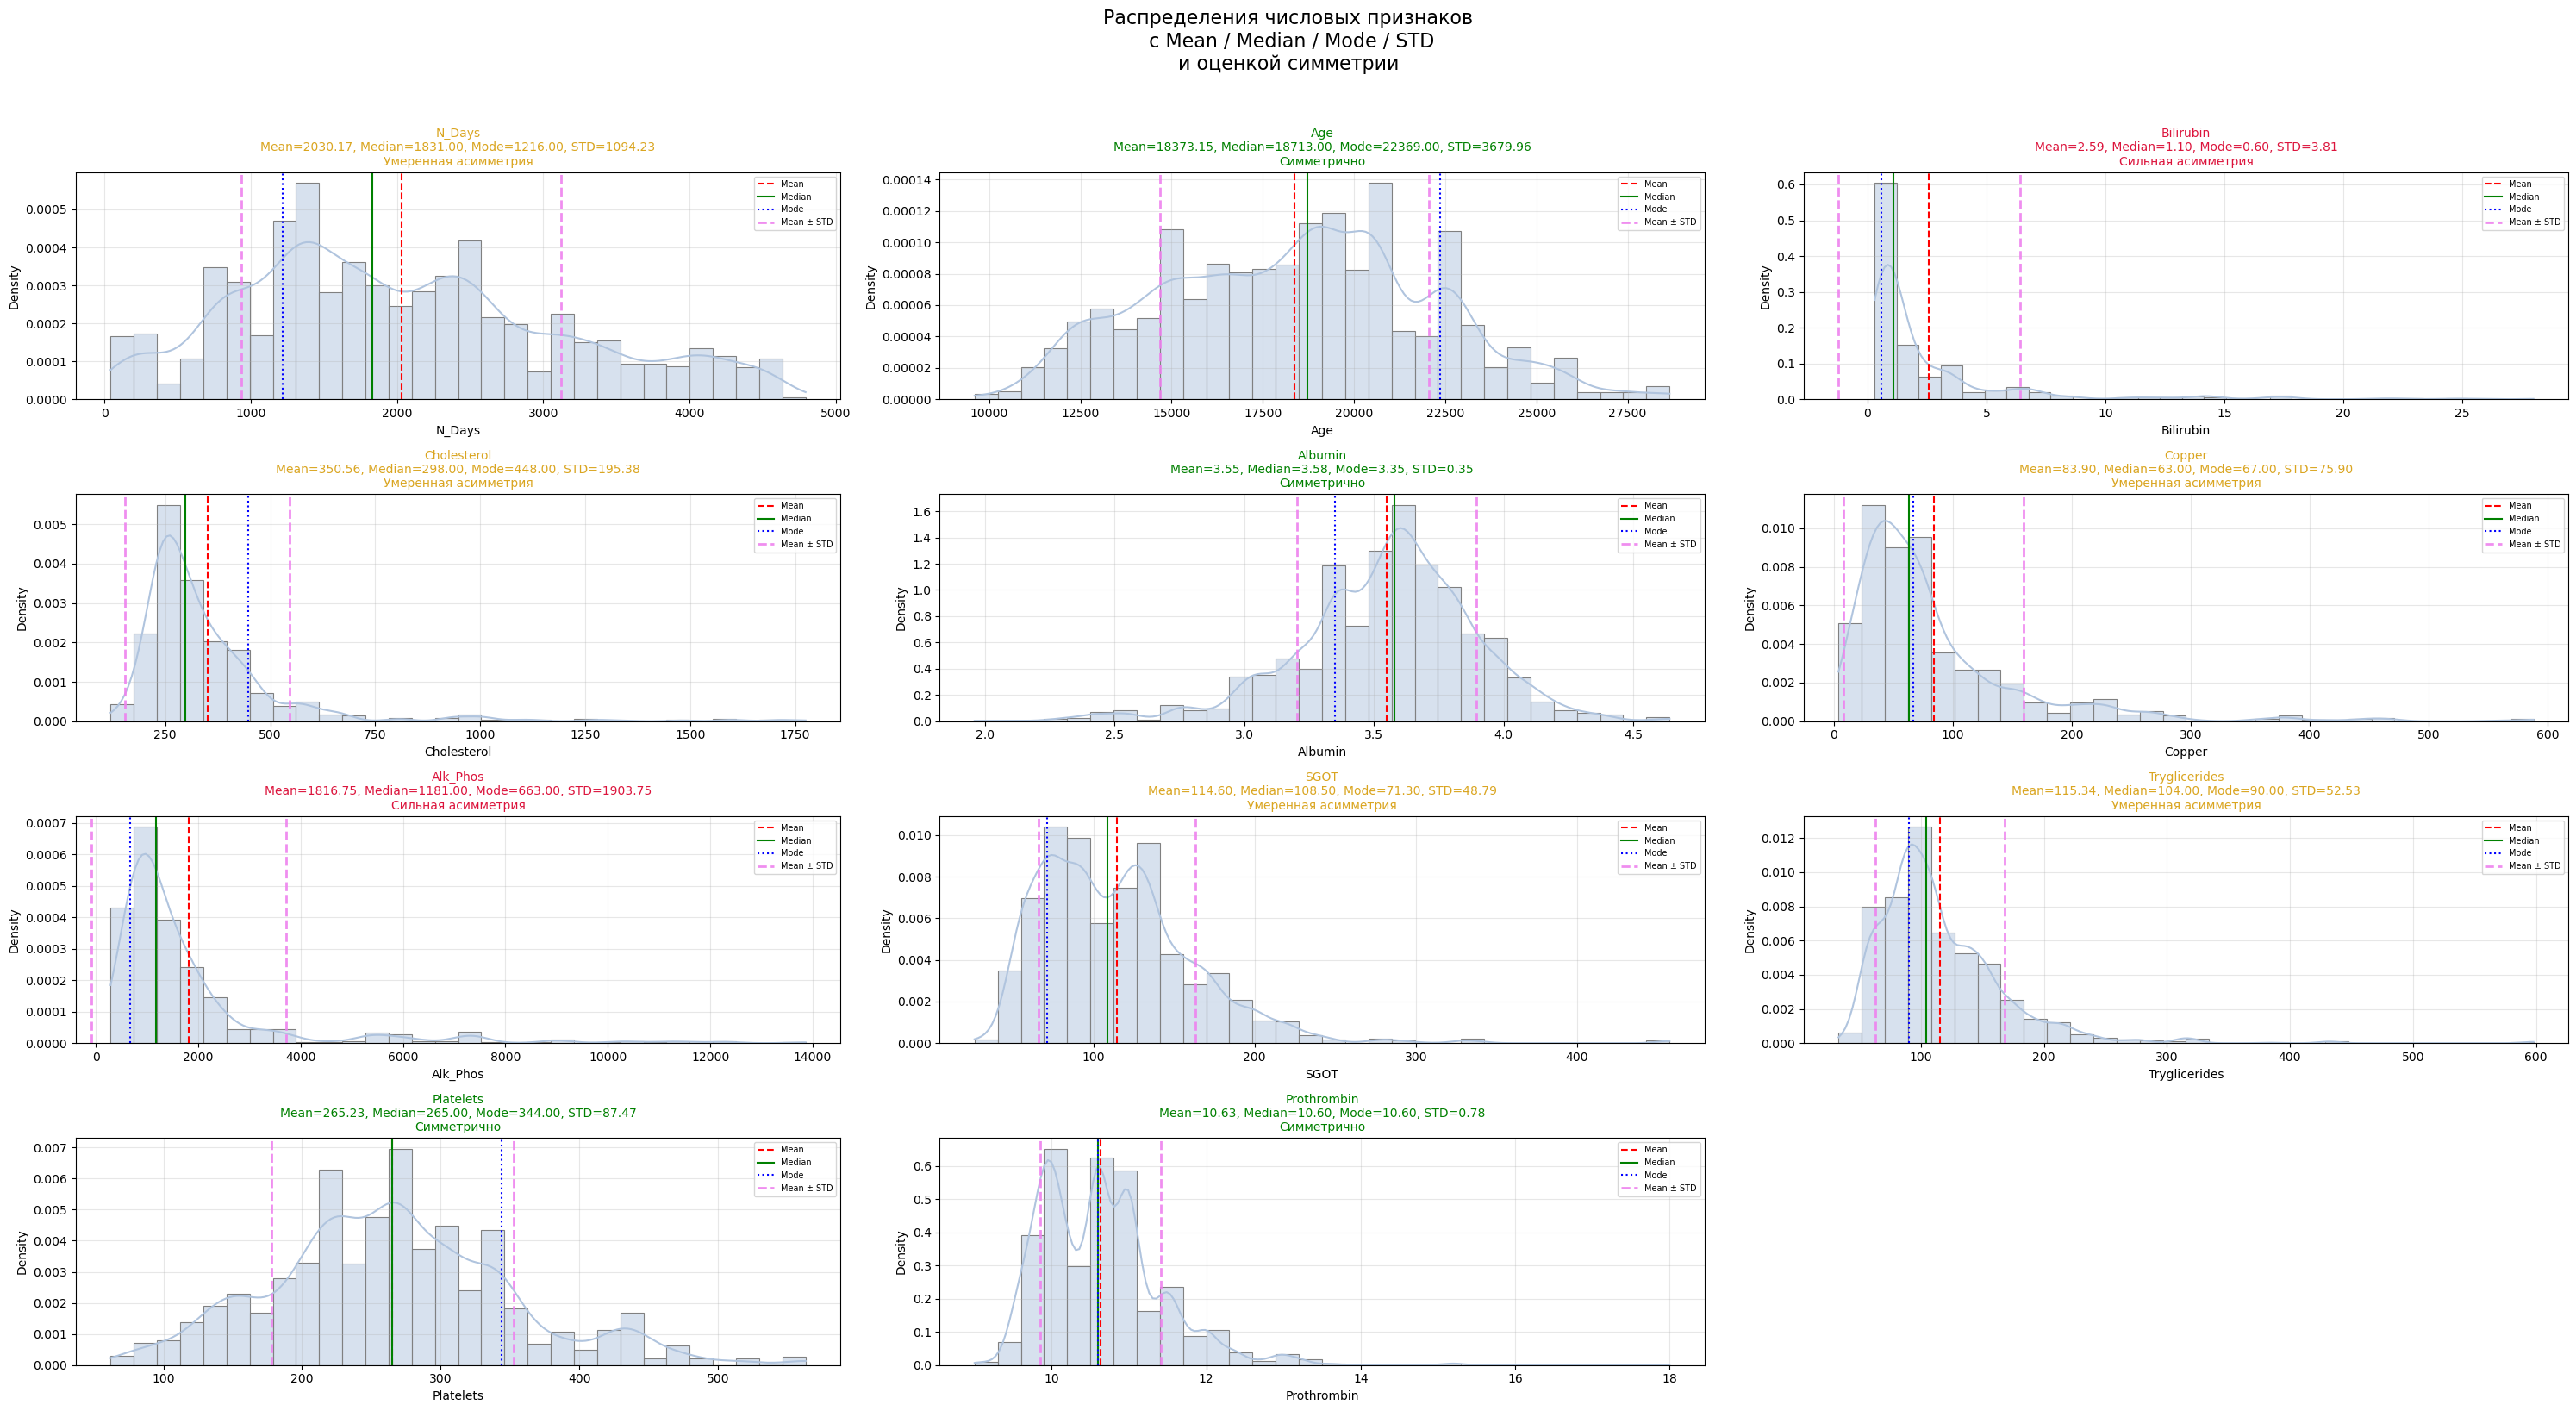

In [13]:
# распределения числовых признаков
n_cols = 3
n_rows = (len(numeric) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric):

    data = df[col].dropna()
   
    mean_val = data.mean()
    median_val = data.median()
    mode_val = data.mode()[0] if not data.mode().empty else np.nan
    std_val = data.std()

    diff = abs(mean_val - median_val)
    skew_ratio = diff / std_val if std_val != 0 else 0

    if skew_ratio < 0.1:
        color = 'green'
        label = 'Симметрично'
    elif skew_ratio < 0.3:
        color = 'goldenrod'
        label = 'Умеренная асимметрия'
    else:
        color = 'crimson'
        label = 'Сильная асимметрия'

    sns.histplot(
        data, bins=30, kde=True,
        color='lightsteelblue', edgecolor='gray', linewidth=0.8,
        ax=axes[i], stat='density'
    )

    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label='Median')
    axes[i].axvline(mode_val, color='blue', linestyle=':', linewidth=1.5, label='Mode')
    axes[i].axvline(mean_val + std_val, color='violet', linestyle='--', linewidth=2, alpha=0.9, label='Mean ± STD')
    axes[i].axvline(mean_val - std_val, color='violet', linestyle='--', linewidth=2, alpha=0.9)

    axes[i].set_title(
        f"{col}\nMean={mean_val:.2f}, Median={median_val:.2f}, Mode={mode_val:.2f}, STD={std_val:.2f}\n{label}",
        fontsize=10, color=color
    )

    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=7)

for j in range(len(numeric), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Распределения числовых признаков\n с Mean / Median / Mode / STD\nи оценкой симметрии", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

- Часть признаков (Age, Albumin, Platelets, Prothrombin) распределены почти симметрично, тогда как другие (Bilirubin, Copper, Alk_Phos, SGOT, Triglycerides, Cholesterol) имеют выраженную правостороннюю асимметрию и длинный хвост.

- У асимметричных признаков среднее заметно выше медианы, что указывает на влияние потенциальных выбросов, с которыми стоит аккуратно работать при ML-моделировании.

- Разный разброс значений также заметен: некоторые признаки лежат в относительно узком диапазоне (Albumin, Prothrombin), а другие сильно варьируются, что отражается в больших значениях стандартного отклонения.

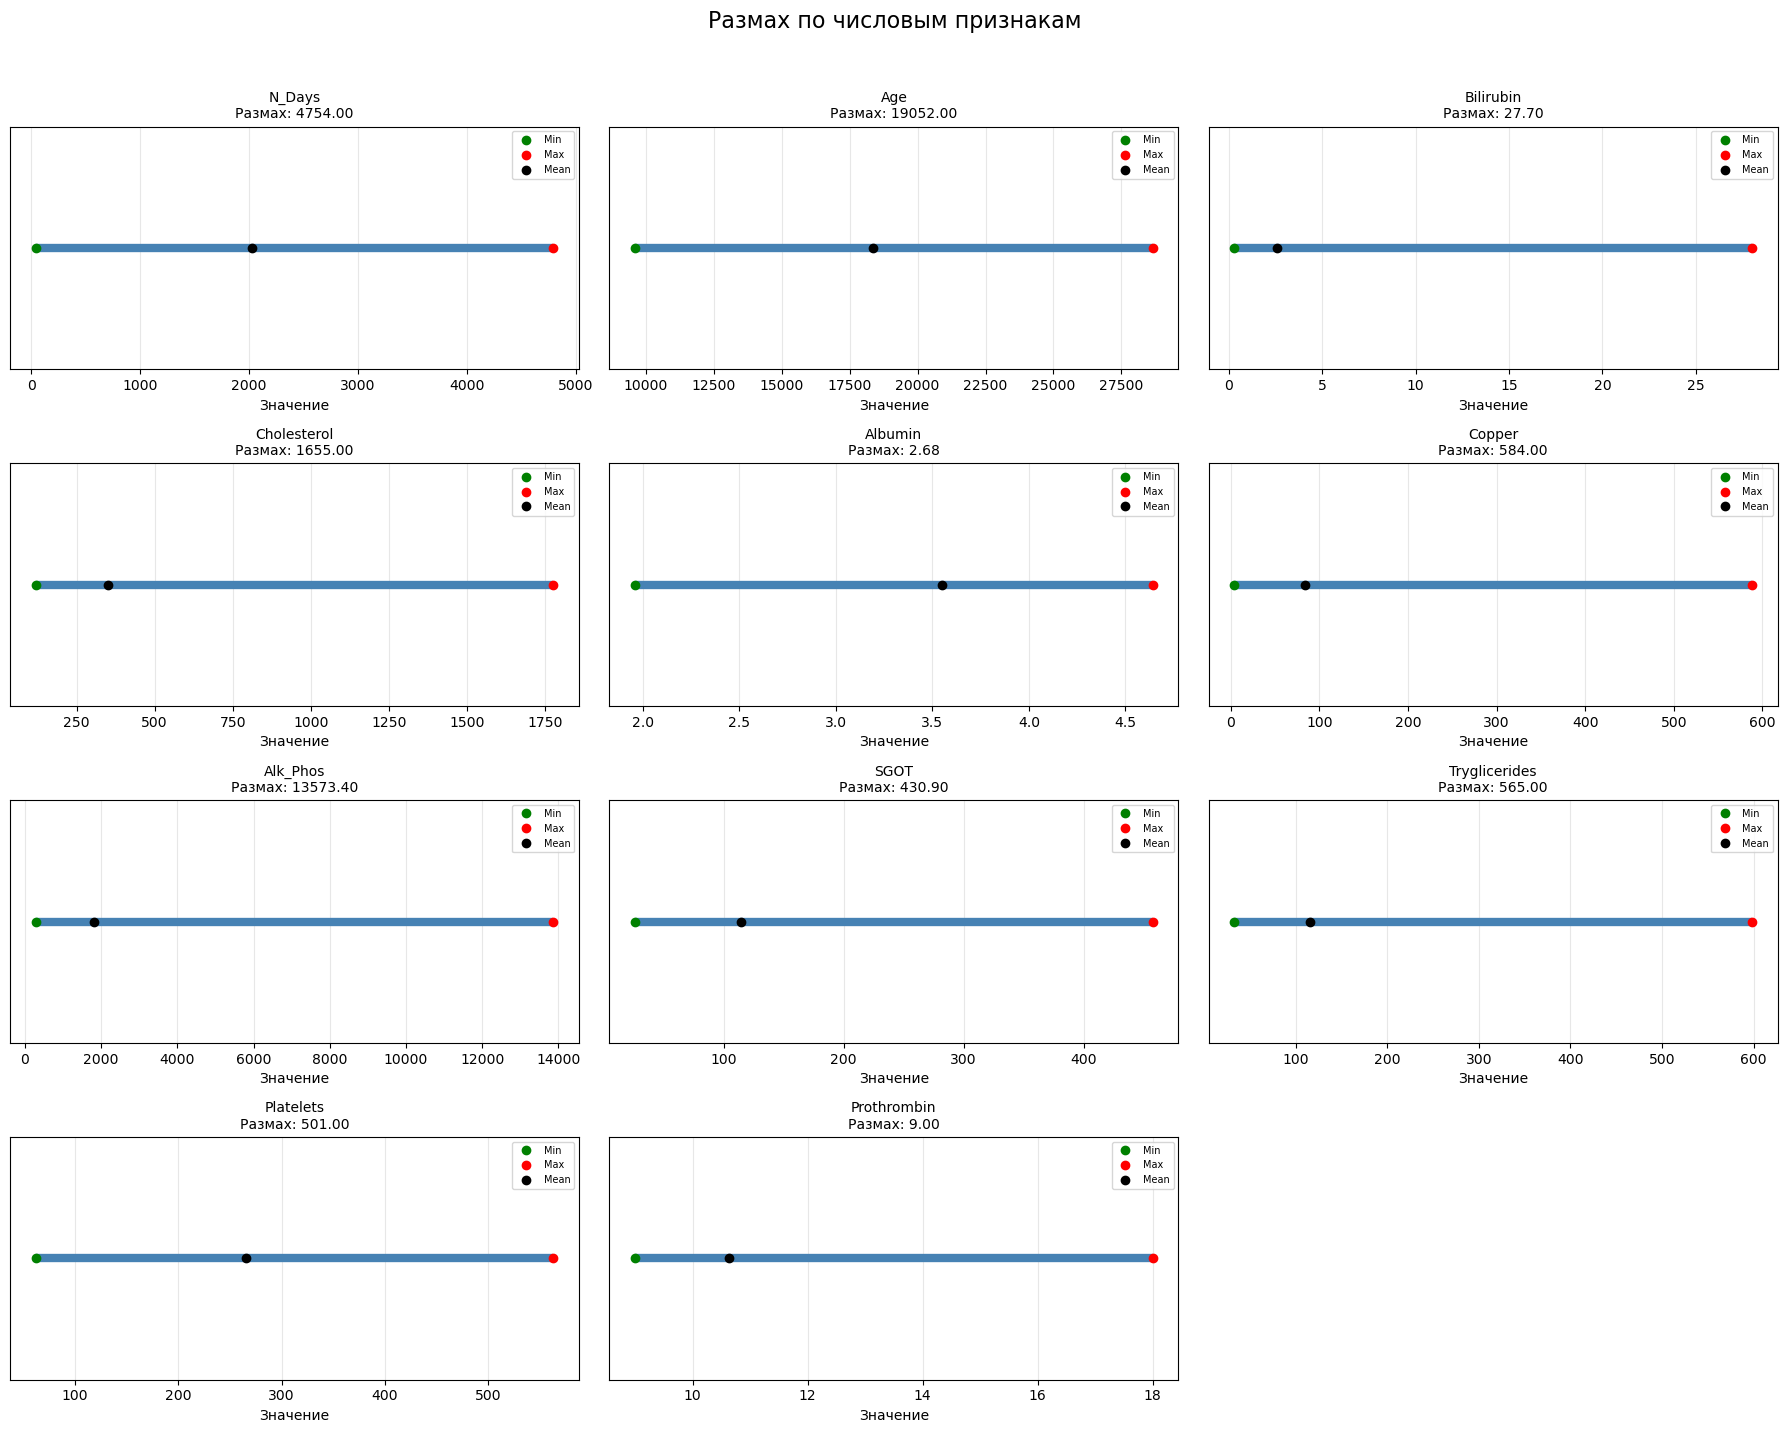

In [14]:
# размахи числовых признаков
n_cols = 3
n_rows = (len(numeric) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 3.5*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric):

    data = df[col].dropna()

    min_val = data.min()
    max_val = data.max()
    mean_val = data.mean()
    rng = max_val - min_val

    axes[i].hlines(1, min_val, max_val, color='steelblue', linewidth=6)
    axes[i].plot(min_val, 1, 'go', label='Min')
    axes[i].plot(max_val, 1, 'ro', label='Max')
    axes[i].plot(mean_val, 1, 'ko', label='Mean')

    axes[i].set_title(f'{col}\nРазмах: {rng:.2f}', fontsize=10)
    axes[i].set_yticks([])
    axes[i].set_xlabel('Значение')
    axes[i].grid(axis='x', alpha=0.3)
    axes[i].legend(fontsize=7, loc='upper right')

for j in range(len(numeric), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Размах по числовым признакам", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

- Разброс по признакам сильно различается: у части переменных диапазон очень широкий (особенно Alk_Phos, Cholesterol, N_Days, Age), у других нет (Albumin, Prothrombin).

- Некоторые признаки выглядят относительно "стабильными": у Age, Platelets, Albumin значения распределены плотнее.

- Выбросы явно прослеживаются во многих биохимических показателях.

In [15]:
# Асимметрия распределений
df[numeric].skew()

N_Days           0.448660
Age              0.084091
Bilirubin        3.339695
Cholesterol      3.679658
Albumin         -0.561150
Copper           2.701736
Alk_Phos         3.195558
SGOT             1.534806
Tryglicerides    2.633921
Platelets        0.420048
Prothrombin      1.292436
dtype: float64

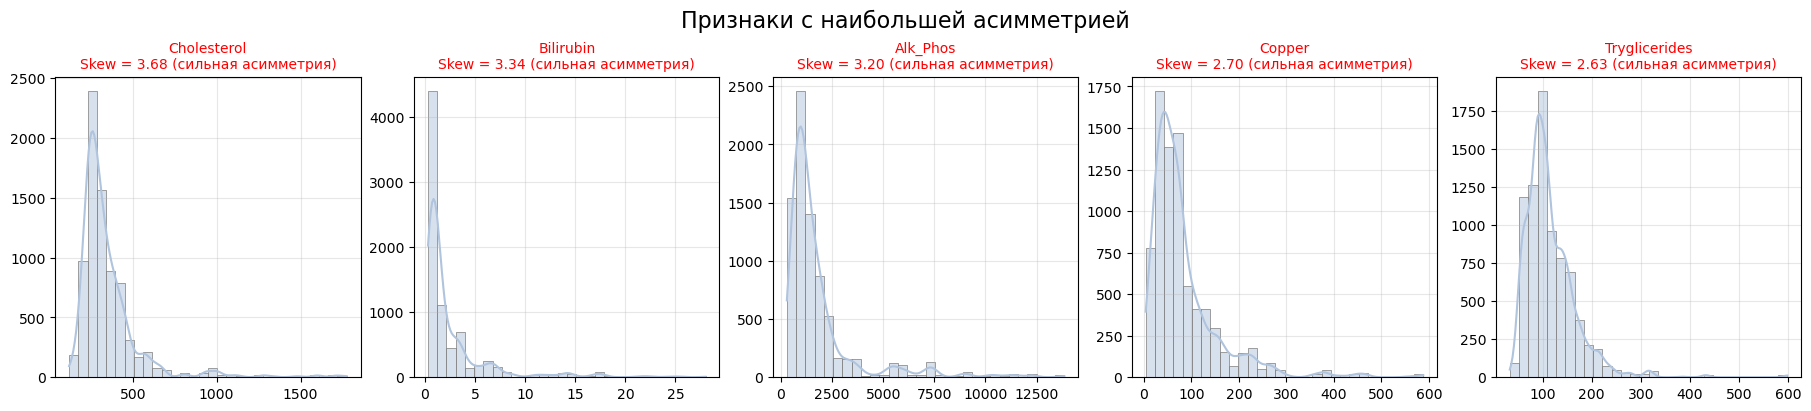

In [16]:
# признаки с наибольшей асимметрией
skew_vals = df[numeric].skew().sort_values(ascending=False)
problematic = skew_vals.head().index.tolist()

fig, axes = plt.subplots(1, len(problematic), figsize=(18, 4), constrained_layout=True)
axes = np.atleast_1d(axes) 

for ax, col in zip(axes, problematic):

    data = df[col].dropna()
    skew_val = data.skew()

    sns.histplot(data, bins=30, kde=True, ax=ax, color="lightsteelblue", edgecolor="gray")

    if abs(skew_val) < 0.3:
        color = "green"
        skew_type = "симметричное"
    elif abs(skew_val) < 1:
        color = "orange"
        skew_type = "умеренная асимметрия"
    else:
        color = "red"
        skew_type = "сильная асимметрия"

    ax.set_title(f"{col}\nSkew = {skew_val:.2f} ({skew_type})", fontsize=10, color=color)
    ax.grid(alpha=0.3)
    ax.set(xlabel="", ylabel="")

fig.suptitle("Признаки с наибольшей асимметрией", fontsize=16)
plt.show()

Признаки Bilirubin, Cholesterol, Copper, Alk_Phos и Tryglicerides имеют выраженную правостороннюю асимметрию, что подтверждает наличие длинных хвостов и выбросов

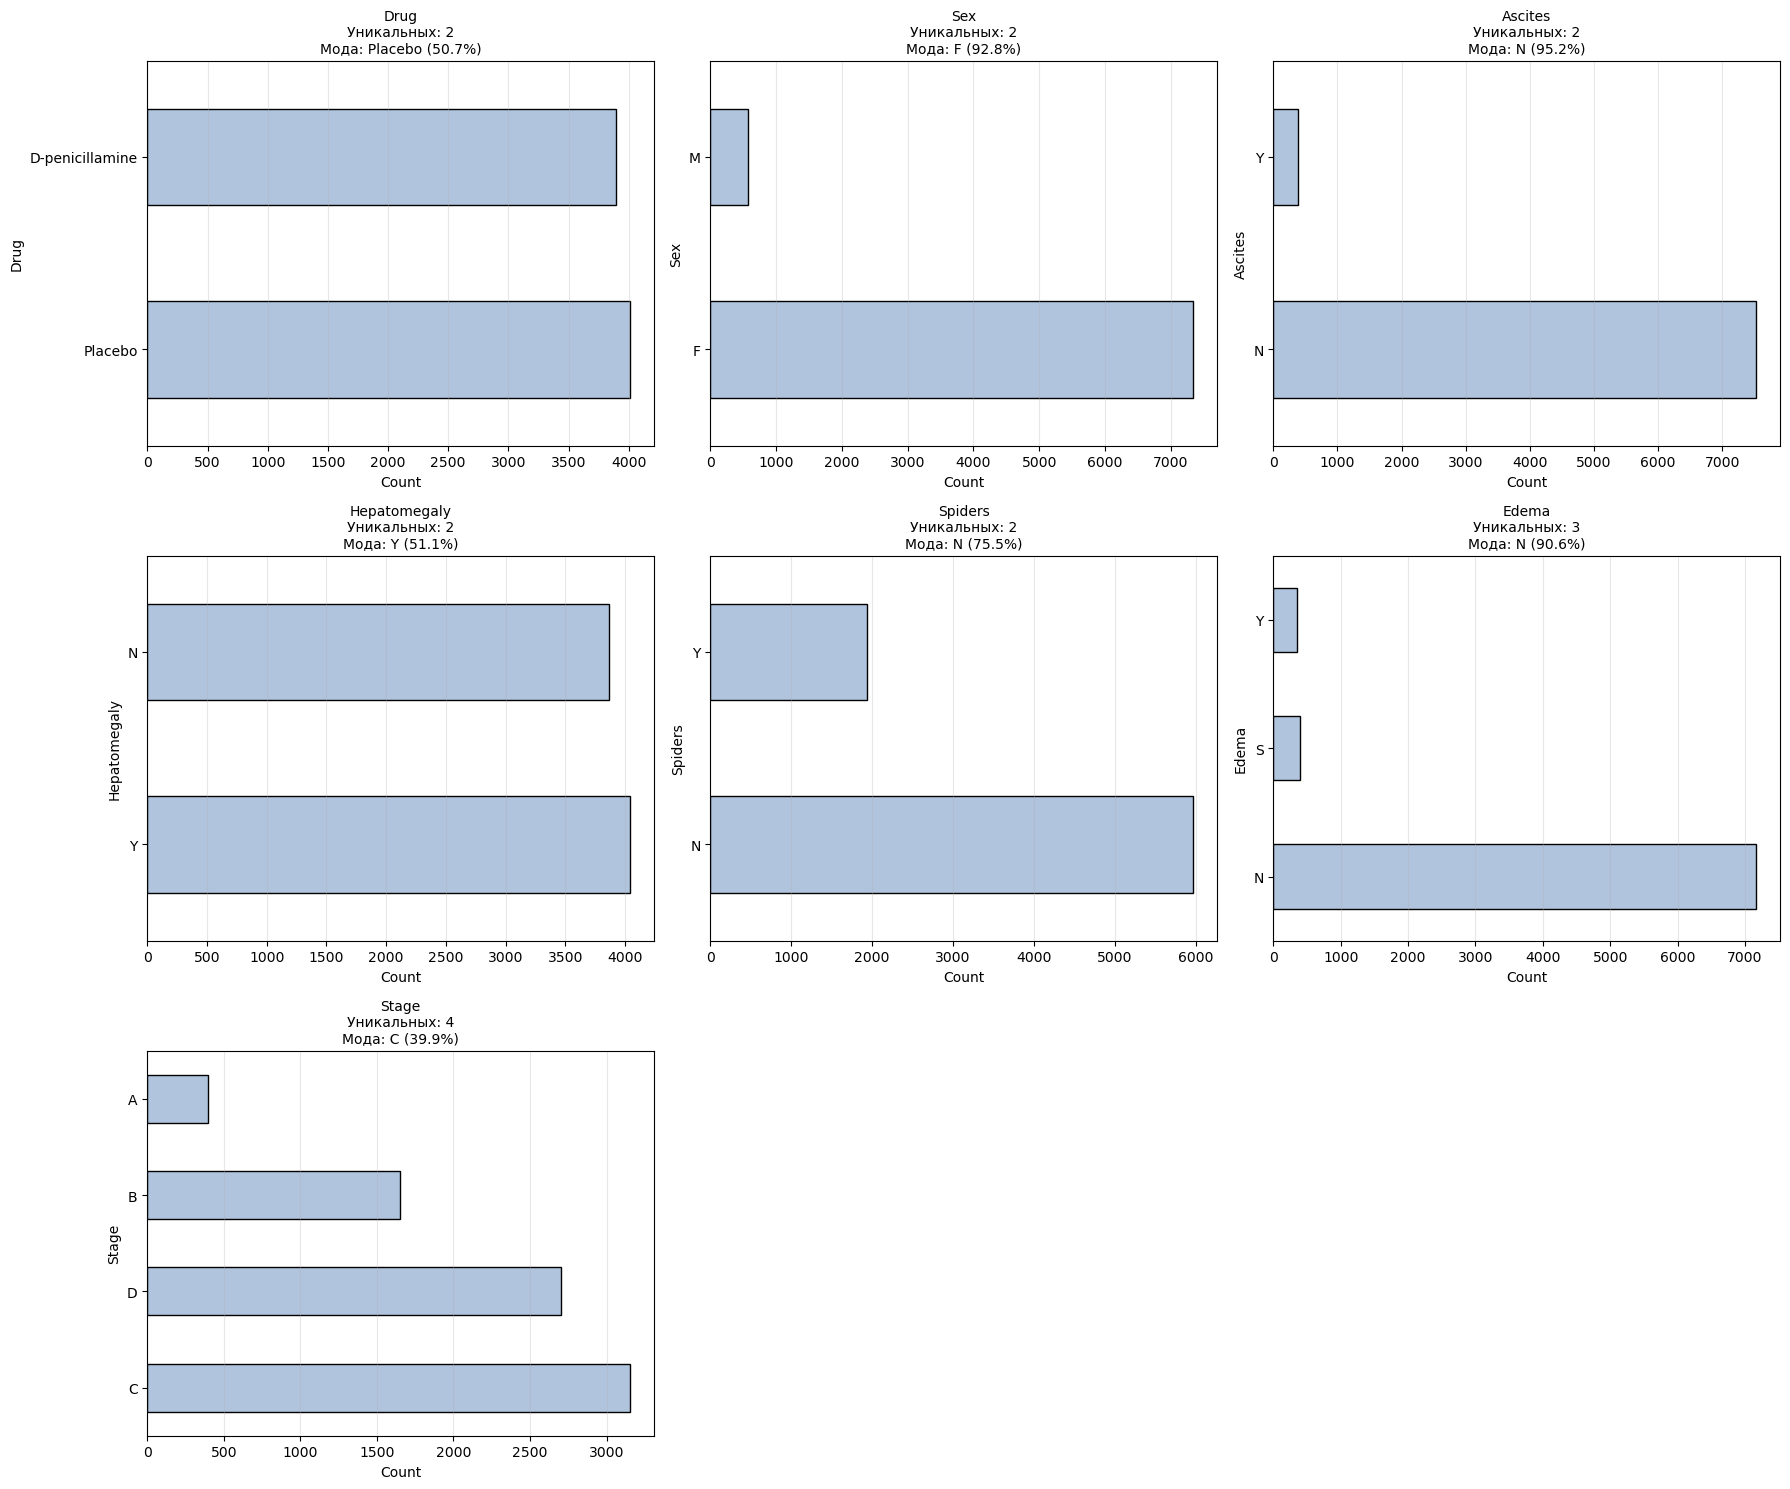

In [17]:
# распределения категориальных признаков
n_cols = 3  
n_rows = (len(categorical) + n_cols - 1) // n_cols  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical):

    counts = df[col].value_counts()
    counts.plot(kind='barh', color='lightsteelblue', edgecolor='black', ax=axes[i])
    
    mode_val = df[col].mode()[0]
    mode_percent = (counts.iloc[0] / len(df)) * 100
    
    axes[i].set_title(f'{col}\nУникальных: {df[col].nunique()}\nМода: {mode_val} ({mode_percent:.1f}%)', fontsize=10)
    axes[i].set_xlabel('Count')
    axes[i].grid(axis='x', alpha=0.3)

for j in range(len(categorical), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

- Большинство категориальных признаков несбалансированы, т.е. в них есть выраженный доминирующий класс.
- Лекарственные группы представлены примерно одинаково.

interval columns not set, guessing: ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']


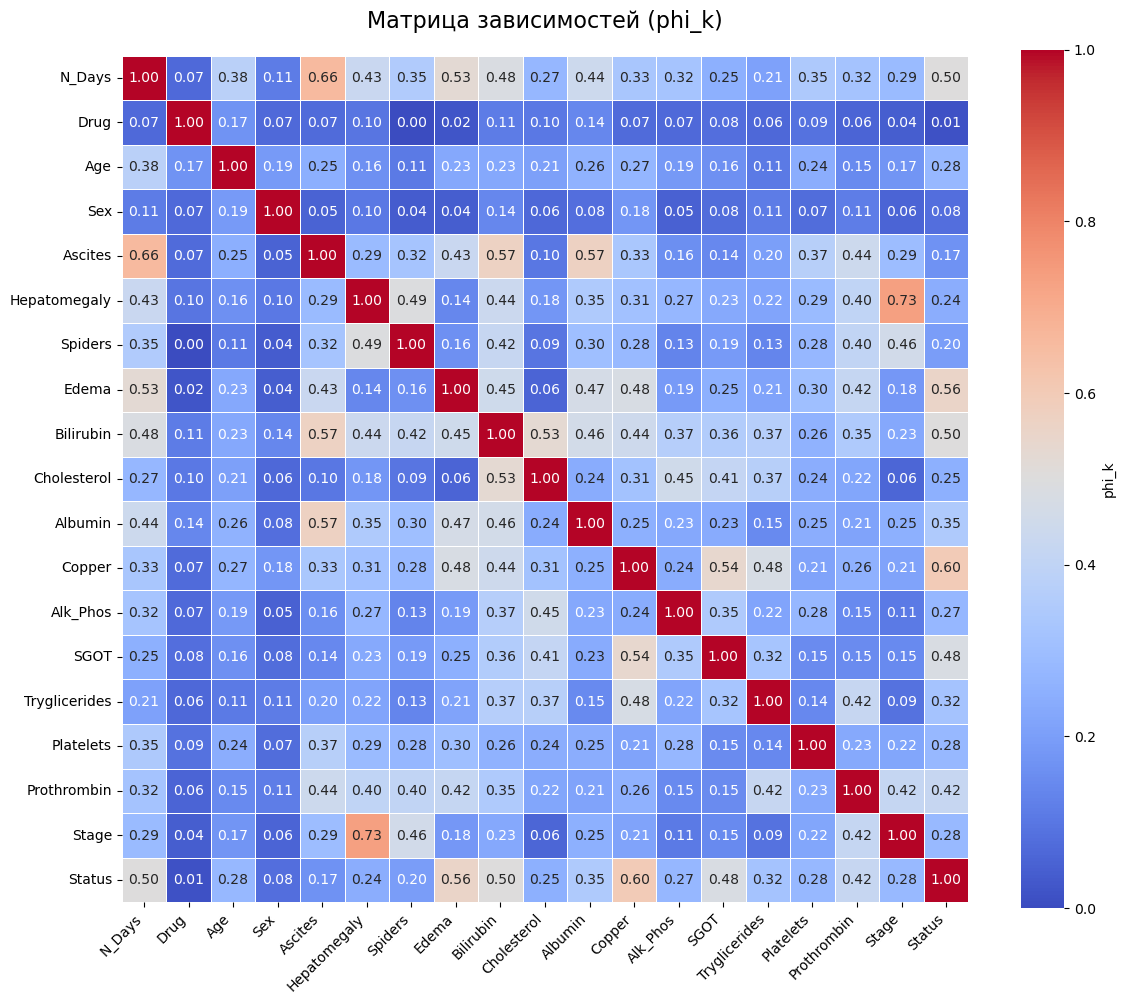

In [18]:
# матрица зависимостей всех признаков и таргета
phik_matrix = df.phik_matrix()

plt.figure(figsize=(12, 10))
sns.heatmap(
    phik_matrix,
    annot=True,         
    fmt=".2f",         
    cmap="coolwarm",    
    vmin=0,
    vmax=1,          
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "phi_k"}
)

plt.title("Матрица зависимостей (phi_k)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- Сильных связей мало: большинство зависимостей находятся на низком или среднем уровне, что говорит о том, что признаки слабо коррелируют друг с другом.
- Наиболее связанные с целевой переменной Status: Copper (≈0.60), Edema (≈0.56), Bilirubin и N_Days (≈0.50), SGOT (≈0.48), Prothrombin (≈0.42).

## 2. Анализ целевой переменной

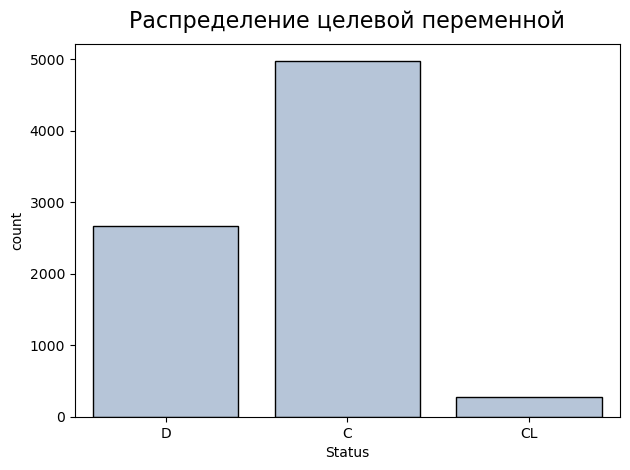

In [19]:
# рассмотрим распределение классов целевой переменной
df['Status'].value_counts(normalize=True) * 100
sns.countplot(x='Status', data=df, color='lightsteelblue', edgecolor='black')
plt.title("Распределение целевой переменной", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

- Классы не сбалансированы: больше всего наблюдений в категории C, а категория CL составляет сильное меньшинство.
- Для корректного использования некоторых ML-моделей может понадобиться корректировка дисбаланса (например, веса классов, oversampling, SMOTE и т.п.).

interval columns not set, guessing: ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']


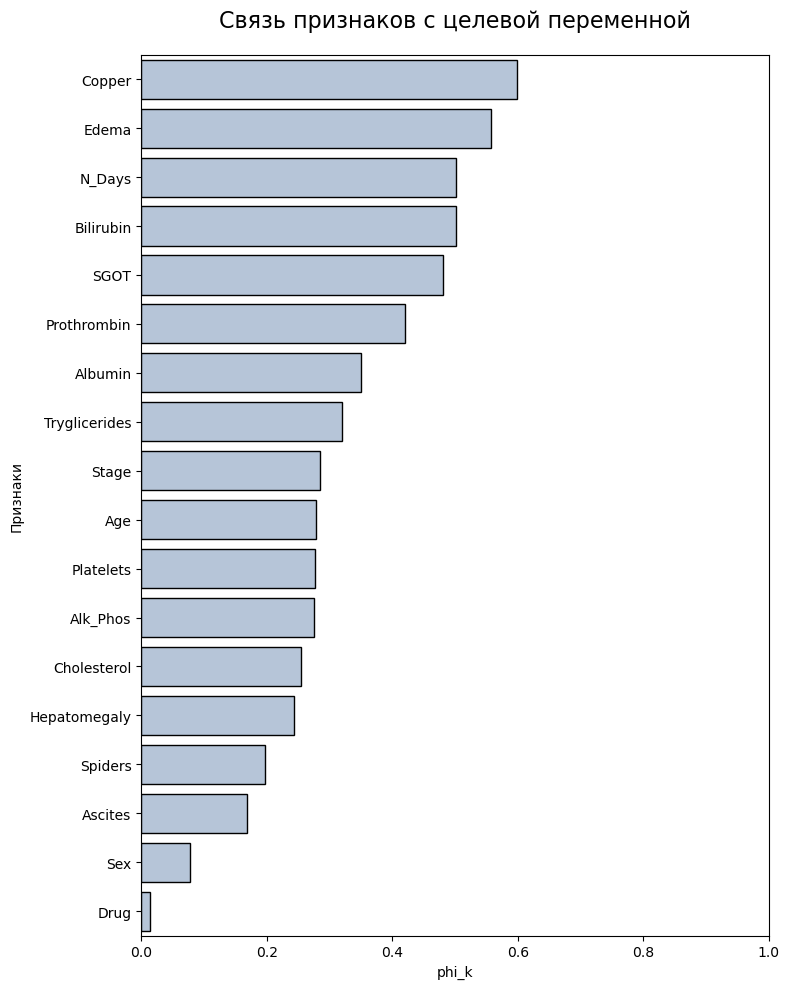

In [20]:
# рассмотрим отдельно связь признаков с целевой переменной
phik_matrix = df.phik_matrix()
target_corr = phik_matrix['Status'].sort_values(ascending=False)

target_corr = target_corr.drop(labels='Status')

plt.figure(figsize=(8, 10))
sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    orient='h',
    color='lightsteelblue', 
    edgecolor='black'
)

plt.title("Связь признаков с целевой переменной", fontsize=16, pad=20)
plt.xlabel("phi_k")
plt.ylabel("Признаки")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

- Наиболее информативные признаки: Copper, Edema, N_Days, Bilirubin, SGOT - они показывают самую высокую связь с целевой переменной.

- Умеренная зависимость: Prothrombin, Albumin, Triglycerides, Stage, Age, Platelets.

- Остальные признаки имеют слабую зависимость, а Drug практически не обнаруживает связи.

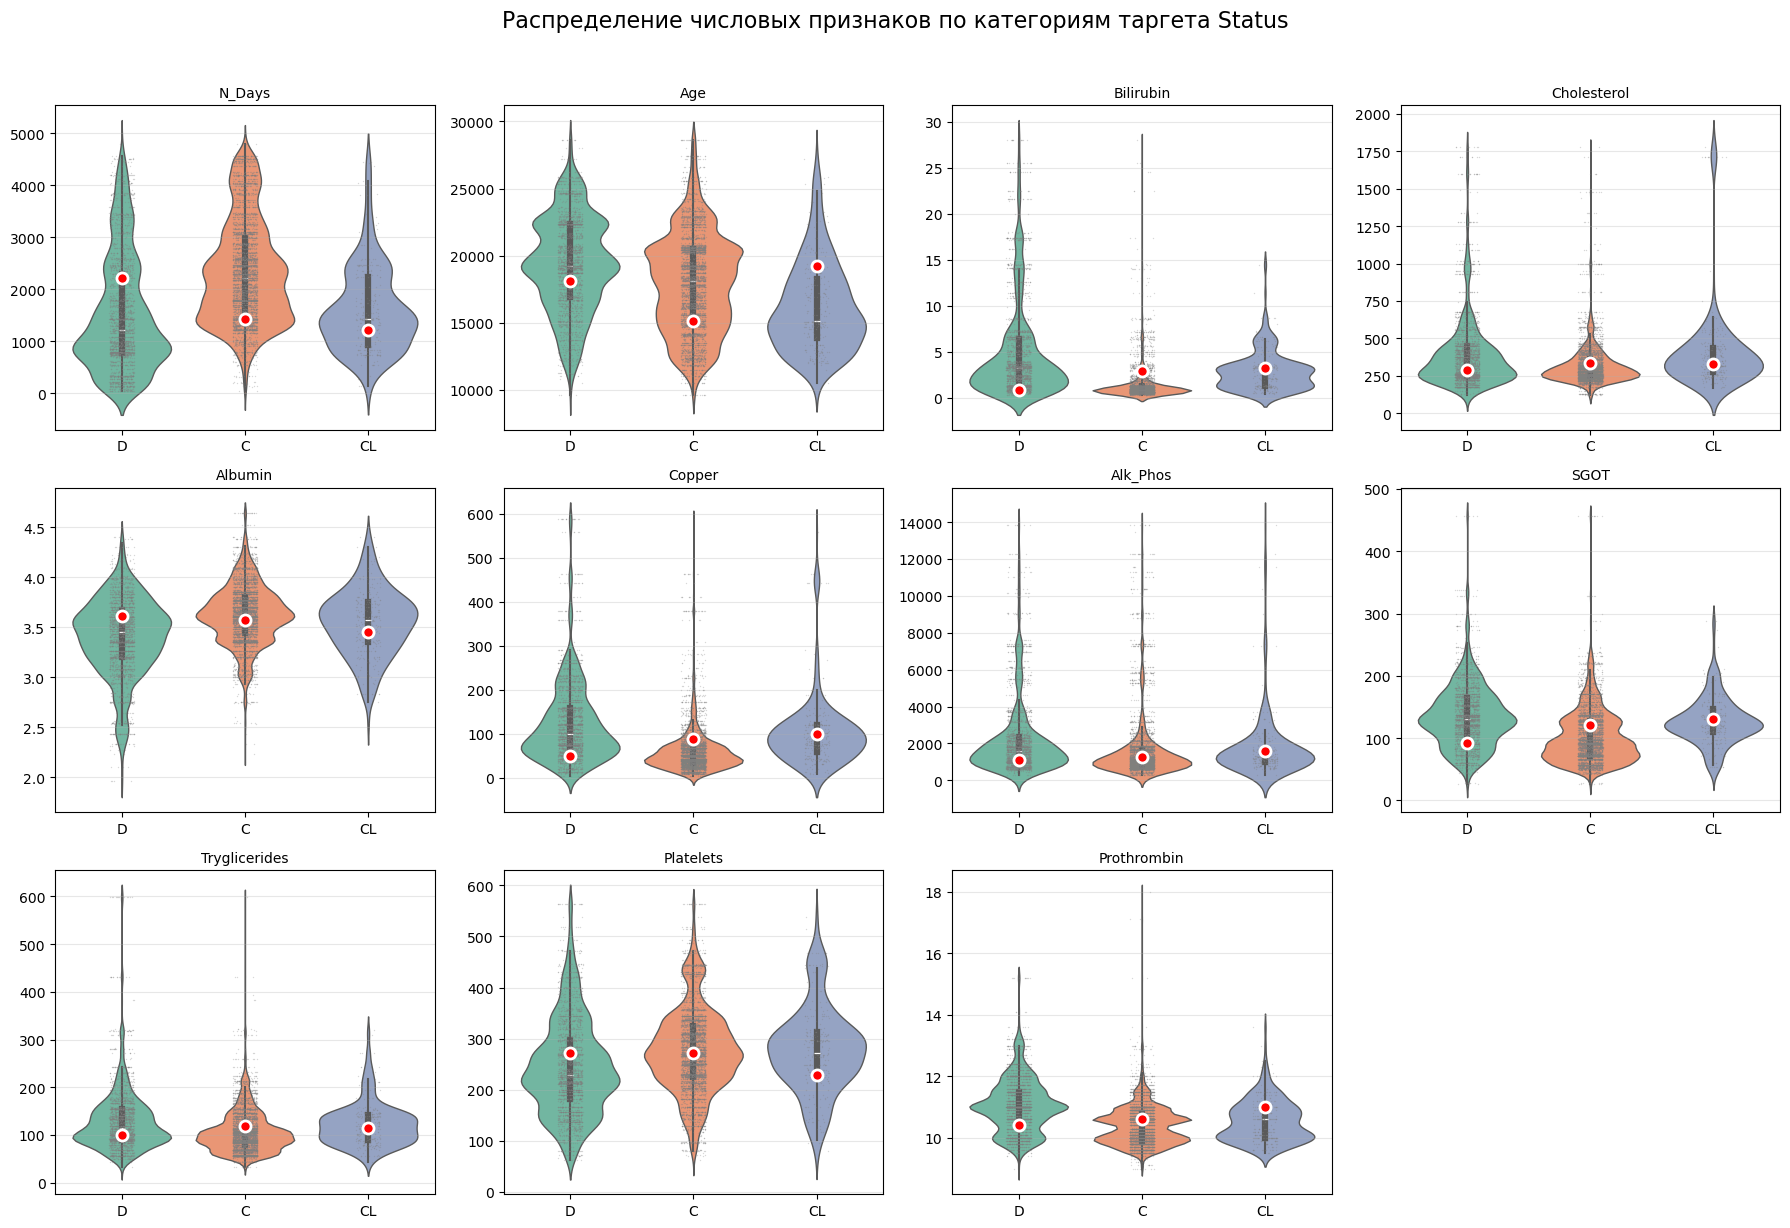

In [21]:
# связь между числовыми признаками и таргетом
cat_col = "Status" 

n_cols = 4
n_rows = -(-len(numeric) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, num_col in enumerate(numeric):

    sns.stripplot(
        data=df,
        x=cat_col,
        y=num_col,
        jitter=True,
        size=1,
        alpha=0.3,
        linewidth=0,
        ax=axes[i],
        color="gray",
    )

    sns.violinplot(
        data=df,
        x=cat_col,
        y=num_col,
        hue=cat_col,
        legend=False,
        linewidth=1,
        ax=axes[i],
        palette="Set2"
    )
    
    medians = df.groupby(cat_col)[num_col].median()
    for j, category in enumerate(medians.index):
        axes[i].plot(
            j,
            medians[category],
            'o',
            color='red',
            markersize=8,
            markeredgecolor='white',
            markeredgewidth=2,
            zorder=10
        )

    axes[i].set_title(num_col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].grid(axis="y", alpha=0.3)

for j in range(len(numeric), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Распределение числовых признаков по категориям таргета Status",
    fontsize=16,
    y=1.02,
)
fig.tight_layout()
plt.show()

- Между группами Status есть заметные различия, особенно по Copper, Bilirubin, SGOT, Albumin, Prothrombin и N_Days: форма распределений и средние значения заметно отличаются.

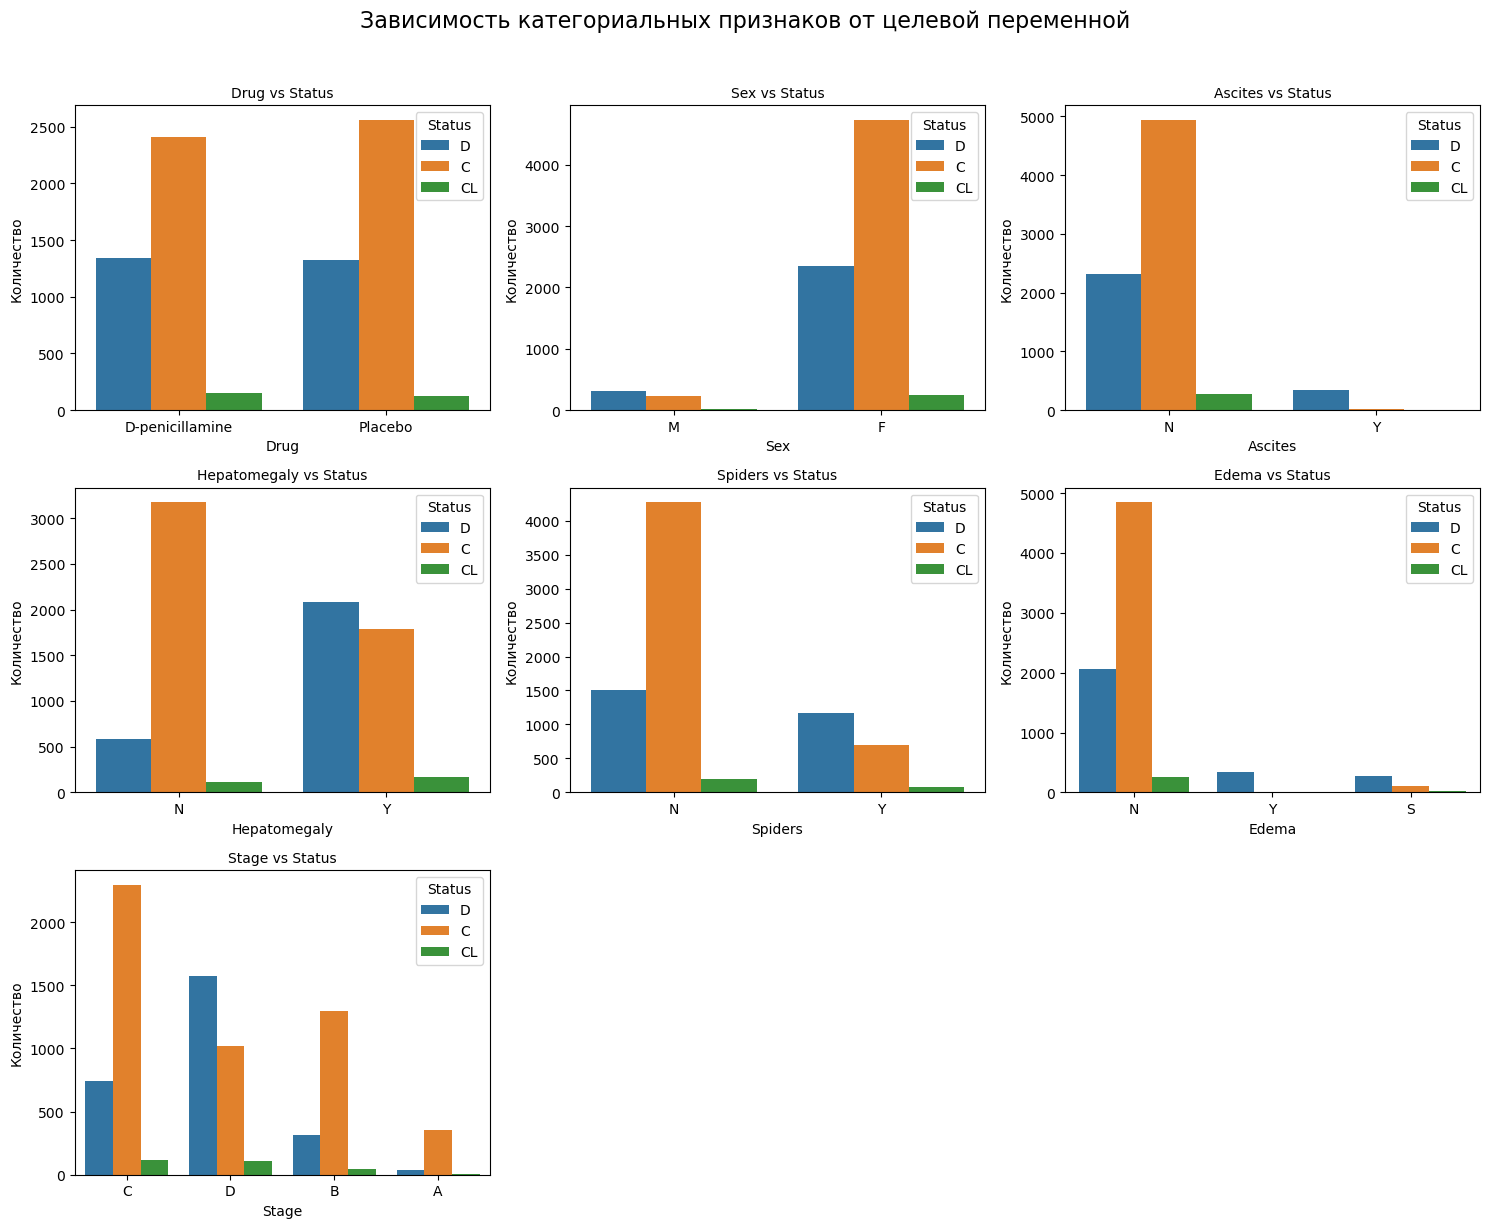

In [22]:
# зависимость категориальных признаков и целевой переменной
n_cols = 3
n_rows = -(-len(categorical) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical):

    if col == 'Status':
        continue
    
    sns.countplot(data=df, x=col, hue=target, ax=axes[i])
    axes[i].set_title(f"{col} vs Status", fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Количество")

for j in range(len(categorical), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Зависимость категориальных признаков от целевой переменной", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

- Между статусами есть различия, но большинство категориальных признаков распределены похоже: почти везде доминирует класс C, затем D, а CL самый малочисленный.

- Сильной зависимости между категориями и таргетом не видно, кроме отдельных случаев (например, Edema и Ascites сильнее выражена в D, чем в C).

Выводы по результатам EDA:

1. Дубли и пропуски отсутствуют.

2. У ряда признаков (Bilirubin, Cholesterol, Copper, Alk_Phos, Triglycerides, SGOT) есть сильная правосторонняя асимметрия и длинные хвосты, т.е. много высоких значений и потенциальных выбросов.

3. Age, N_Days и Alk_Phos имеют очень широкий диапазон значений и высокое стандартное отклонение.

4. Alk_Phos, Cholesterol, SGOT и Copper имеют медианные значения выше диапазона нормы.

5. Категориальные признаки несбалансированы: чаще всего встречается одна доминирующая категория.

6. Целевая переменная Status также несбалансирована: класс C самый большой, класс CL - самый малочисленный, что может сказываться на качестве моделей.

7. Status сильнее всего связан с Copper, Edema, N_Days, Bilirubin, SGOT и Prothrombin. Drug, Sex, Spiders, Ascites, Cholesterol и Alk_Phos связаны слабо.

8. Между признаками нет сильных корреляций, но есть умеренные связи.

9. Для статуса D характерны более высокие значения Bilirubin, Copper, Alk_Phos, SGOT и Triglycerides и более низкие Albumin и Platelets.

10. Пациенты со статусом D чаще имеют осложнения (Ascites, Edema, Spiders, Hepatomegaly).

# ML-моделирование

Напишем функции для обработки данных и применения разных ML-моделей.

Классы-преобразователи для переменных разных типов:

In [23]:
class BinaryMapper(BaseEstimator, TransformerMixin):
    """
    Превращает бинарные категориальные в 0/1 по заданному словарю.
    """
    def __init__(self, mapping: dict):
        self.mapping = mapping
        self.columns_ = list(mapping.keys())

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=self.columns_)
        for col, mapping in self.mapping.items():
            X_df[col] = X_df[col].map(mapping)
        return X_df

    def get_feature_names_out(self, input_features=None):
        return self.columns_


class PercentileClipper(BaseEstimator, TransformerMixin):
    """Обрезает выбросы в указанных колонках по перцентилям, выполняя винзоризацию."""
    def __init__(self, columns, lower=0.0, upper=99.5):
        self.columns = columns
        self.lower = lower
        self.upper = upper
        self.bounds_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=self.columns)
        for col in self.columns:
            low = np.percentile(X[col], self.lower)
            up = np.percentile(X[col], self.upper)
            self.bounds_[col] = (low, up)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.columns)
        for col, (low, up) in self.bounds_.items():
            X_df[col] = X_df[col].clip(low, up)
        return X_df.values
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(self.columns, dtype=object)
        return np.asarray(input_features, dtype=object)

Преобразователь для полиномиальных фичей:

In [24]:
class PolyFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, degree=2, interaction_only=True, include_bias=False):
        self.degree = degree
        self.interaction_only = interaction_only
        self.include_bias = include_bias

    def fit(self, X, y=None):
        self.poly_ = PolynomialFeatures(
            degree=self.degree,
            interaction_only=self.interaction_only,
            include_bias=self.include_bias
        )
        self.poly_.fit(X)
        self.n_in_ = X.shape[1]
        return self

    def transform(self, X):
        Z = self.poly_.transform(X)
        return Z[:, self.n_in_:]

    def get_feature_names_out(self, input_features=None):
        names = self.poly_.get_feature_names_out(input_features)
        return np.asarray(names[self.n_in_:], dtype=object)
    
    
def make_poly_transformer(
    strategy,
    poly_skewed,
    poly_symmetric,
    poly_degree=2,
    interaction_only=True,
    clip_upper=99
):

    log = FunctionTransformer(np.log1p, feature_names_out="one-to-one")

    if strategy == "log_standard":
        skewed_pipe = Pipeline([("log", log)])
        symmetric_pipe = "passthrough"
        scaler = StandardScaler()

    elif strategy == "log_clip_standard":
        skewed_steps = [("log", log)]
        if len(poly_skewed) > 0:
            skewed_steps.append(("clip", PercentileClipper(poly_skewed, upper=clip_upper)))
        skewed_pipe = Pipeline(skewed_steps)
        symmetric_pipe = "passthrough"
        scaler = StandardScaler()

    elif strategy == "log_robust":
        skewed_pipe = Pipeline([("log", log)])
        symmetric_pipe = "passthrough"
        scaler = RobustScaler()

    elif strategy == "log_clip_robust":
        skewed_steps = [("log", log)]
        if len(poly_skewed) > 0:
            skewed_steps.append(("clip", PercentileClipper(poly_skewed, upper=clip_upper)))
        skewed_pipe = Pipeline(skewed_steps)
        symmetric_pipe = "passthrough"
        scaler = RobustScaler()

    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    poly_numeric_prep = ColumnTransformer(
        transformers=[
            ("skewed", skewed_pipe, poly_skewed),
            ("symmetric", symmetric_pipe, poly_symmetric)
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    return Pipeline([
        ("prep", poly_numeric_prep),
        ("poly", PolyFeatures(
            degree=poly_degree,
            include_bias=False,
            interaction_only=interaction_only
        )),
        ("scale", scaler)
    ])

Напишем классы кастомных фичей, которые основаны на медицинской практике и потенциально могут улучшить качество модели:

- **Symptom_Score** — это сумма клинических осложнений (асцит, гепатомегалия, сосудистые "звёздочки", отёки). Чем больше число, тем выраженнее декомпенсация цирроза и выше риск неблагоприятного исхода.

- **Bilirubin_Albumin_Ratio** — это отношение билирубина к альбумину. Билирубин растёт при холестазе и нарушении выведения желчи, а альбумин падает при снижении синтетической функции печени. Поэтому высокий индекс указывает на тяжёлое поражение печени и более высокий риск плохого прогноза.

- **CoagulationIndex** — это отношение протромбина к альбумину. Оно отражает синтетическую функцию печени: при тяжёлом циррозе протромбиновое время растёт, а альбумин падает. Поэтому высокий индекс означает выраженную печёночную недостаточность и высокий риск неблагоприятного исхода. Эти параметры входят в шкалу Child-Pugh.

- **Enzyme_Pattern** — соотношение SGOT и щелочной фосфатазы отражает так называемый ферментный паттерн. Высокое значение указывает на гепатоцеллюлярное повреждение (клеточное воспаление), а низкое — на холестаз. В циррозе преобладание холестаза часто связано с более тяжёлым течением, поэтому этот индекс помогает дереву улавливать тип поражения печени.

In [25]:
class SymptomScoreTransformer(BaseEstimator, TransformerMixin):
    """
    Symptom_Score - суммарное кол-во осложнений (Ascites, Hepatomegaly, Spiders, Edema)
    """
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.to_list()
        return self

    def transform(self, X):
        X = X.copy()
        mapping = {'N': 0, 'Y': 1, 'S': 1}

        ascites = X['Ascites'].map(mapping)
        hepatomegaly = X['Hepatomegaly'].map(mapping)
        spiders = X['Spiders'].map(mapping)
        edema = X['Edema'].map(mapping)

        X['Symptom_Score'] = ascites + hepatomegaly + spiders + edema
        return X
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        input_features = list(input_features)
        return np.array(input_features + ["Symptom_Score"], dtype=object)


class BilirubinAlbuminRatioTransformer(BaseEstimator, TransformerMixin):
    """
    Bilirubin_Albumin_Ratio = Bilirubin / Albumin
    """
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.to_list()
        return self

    def transform(self, X):
        X = X.copy()
        eps = 1e-6
        X['Bilirubin_Albumin_Ratio'] = X['Bilirubin'] / (X['Albumin'] + eps)
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.array(list(input_features) + ["Bilirubin_Albumin_Ratio"], dtype=object)
    

class CoagulationIndexTransformer(BaseEstimator, TransformerMixin):
    """
    Coagulation_Index = Prothrombin / Albumin (показатель синтетической функции печени)*
    """
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.to_list()
        return self

    def transform(self, X):
        X = X.copy()
        eps = 1e-6
        X['Coagulation_Index'] = X['Prothrombin'] / (X['Albumin'] + eps)
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.array(list(input_features) + ["Coagulation_Index"], dtype=object)
    

class EnzymePatternTransformer(BaseEstimator, TransformerMixin):
    """
    Добавляет Enzyme_Pattern = SGOT / Alk_Phos (тип поражения печени)*
    """
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.to_list()
        return self

    def transform(self, X):
        X = X.copy()
        eps = 1e-6
        X['Enzyme_Pattern'] = X['SGOT'] / (X['Alk_Phos'] + eps)
        return X
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.array(list(input_features) + ["Enzyme_Pattern"], dtype=object)

Создадим функцию для обработки признаков с разными видами преобразований для применения линейных моделей, чувствительных к выбросам, асимметрии и масштабу числовых признаков.

Ниже указаны четыре стратегии предобработки числовых признаков, которые имеют скошенное распределение с выбросами:

- Вариант 1: log + standard scaler
- Вариант 2: log + percentile clip + standard scaler
- Вариант 3: log + robust scaler
- Вариант 4: log + percentile clip + robust scaler

**Log-преобразование** стабилизирует дисперсию и уменьшает асимметрию, делает данные более близкими к нормальному распределению.

**Percentile Clipper** заменяет экстремальные выбросы на значения перцентилей (в нашем случае — длинные правые хвосты), защищает от сильного влияния аномалий.

**Standard Scaler** стандартизует данные (среднее=0, дисперсия=1), хорошо подходит для нормально распределённых данных.

**Robust Scaler** масштабирует на основе медианы и межквартильного расстояния, более устойчив к выбросам.

Для симметричных числовых признаков используется только скейлер.

Бинарные признаки кодируются как 0 и 1, мультикатегориальные через one-hot-encoding.

Преобразователь для полиномиальных фичей включается по флагу.

In [26]:
def make_logreg_preprocessor(
    strategy="log_standard",
    skewed_numeric=None,
    symmetric_numeric=None,
    binary_features=None,
    multi_category_features=None,
    use_poly=False,
    poly_skewed=None,
    poly_symmetric=None,
    poly_degree=2,
    interaction_only=True,
    clip_upper=99,
    proc_col_names=True
):
    log = FunctionTransformer(np.log1p, feature_names_out="one-to-one")

    if strategy == "log_standard":
        skewed_pipe = Pipeline([
            ("log", log),
            ("scale", StandardScaler())
        ])
        symmetric_pipe = Pipeline([("scale", StandardScaler())])

    elif strategy == "log_clip_standard":
        skewed_pipe = Pipeline([
            ("log", log),
            ("clip", PercentileClipper(skewed_numeric, upper=clip_upper)),
            ("scale", StandardScaler())
        ])
        symmetric_pipe = Pipeline([("scale", StandardScaler())])

    elif strategy == "log_robust":
        skewed_pipe = Pipeline([
            ("log", log),
            ("scale", RobustScaler())
        ])
        symmetric_pipe = Pipeline([("scale", RobustScaler())])

    elif strategy == "log_clip_robust":
        skewed_pipe = Pipeline([
            ("log", log),
            ("clip", PercentileClipper(skewed_numeric, upper=clip_upper)),
            ("scale", RobustScaler())
        ])
        symmetric_pipe = Pipeline([("scale", RobustScaler())])

    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    transformers = [
        ("num_skewed", skewed_pipe, skewed_numeric),
        ("num_symmetric", symmetric_pipe, symmetric_numeric),
        ("binary", BinaryMapper(binary_maps), binary_features),
        ("category", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), multi_category_features),
    ]

    if use_poly:
        
        poly_pipe = make_poly_transformer(
            strategy=strategy,
            poly_skewed=poly_skewed,
            poly_symmetric=poly_symmetric,
            poly_degree=poly_degree,
            interaction_only=interaction_only,
            clip_upper=clip_upper
        )
        transformers.insert(2, ("poly", poly_pipe, poly_symmetric+poly_skewed))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=proc_col_names
    )

Функция для обработки признаков для дерева решений и случайного леса. Числовые признаки оставим в исходном виде, поскольку ML-модели на основе деревьев не накладывают жёстких требований в виде масштабирования, коррекции асимметрии и борьбы с выбросами. В качестве обработки признаков закодируем только категориальные фичи:

- бинарные как 0 и 1
- Edema и Stage через OrdinalEncoder

In [27]:
def make_tree_processor(binary_maps, binary_features, multi_category_features):
    
    processor = ColumnTransformer(
        transformers=[
            ("binary", BinaryMapper(binary_maps), binary_features),
            ("category", OrdinalEncoder(), multi_category_features)
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )
    
    return processor

Функция пайплайна для логистической регрессии, которая позволяет перебирать не только гиперпараметры модели через GridSearch, но и методы борьбы с дисбалансом классов (RandomUnderSampler, RandomOverSampler, SMOTE) и стратегию предобработки числовых признаков. Функция также принимает на вход список фичей, с которыми будет работать модель, и флаги use_fe и use_poly, отвечающие за использования кастомных и полиномиальных фичей соответственно. 

Также напишем функцию бейслайна логистической регрессии - с простыми преобразованиями признаков и без подбора гиперпараметров.

In [28]:
def make_lr_baseline(
    skewed_numeric=None,
    symmetric_numeric=None,
    binary_features=None,
    multi_category_features=None
):
    
    preproc = make_logreg_preprocessor(
            strategy="log_standard",
            skewed_numeric=skewed_numeric,
            symmetric_numeric=symmetric_numeric,
            binary_features=binary_features,
            multi_category_features=multi_category_features
    )
    
    lr = LogisticRegression(random_state=RANDOM_STATE, n_jobs=-1)
    
    steps = [
        ("preprocess", preproc),
        ("logreg", lr)
    ]
    
    pipe = Pipeline(steps)

    return pipe
    

def make_lr_gridsearch(
    use_fe=False,
    fe_cols=None,
    strategy_list=("log_standard", "log_clip_standard", "log_robust", "log_clip_robust"),
    skewed_numeric=None,
    symmetric_numeric=None,
    binary_features=None,
    multi_category_features=None,
    use_poly=False,
    poly_skewed=None,
    poly_symmetric=None,
    poly_degree=2,
    interaction_only=True,
    clip_upper=99
):

    preprocessors = []
    for strat in strategy_list:
        preproc = make_logreg_preprocessor(
            strategy=strat,
            skewed_numeric=skewed_numeric,
            symmetric_numeric=symmetric_numeric,
            binary_features=binary_features,
            multi_category_features=multi_category_features,
            use_poly=use_poly,
            poly_skewed=poly_skewed,
            poly_symmetric=poly_symmetric,
            poly_degree=poly_degree,
            interaction_only=interaction_only,
            clip_upper=clip_upper,
        )
        preproc._strategy_name = strat
        preprocessors.append(preproc)

    samplers = [
        "passthrough",
        RandomUnderSampler(random_state=RANDOM_STATE),
        RandomOverSampler(random_state=RANDOM_STATE),
        SMOTE(random_state=RANDOM_STATE, k_neighbors=5),
    ]

    lr = LogisticRegression(random_state=RANDOM_STATE, n_jobs=-1, max_iter=300)

    steps = []

    if use_fe:

        if not fe_cols:
            fe_cols = ["Symptom_Score", "Bilirubin_Albumin_Ratio", "Coagulation_Index", "Enzyme_Pattern"]

        if "Symptom_Score" in fe_cols:
            steps.append(("symptom_score", SymptomScoreTransformer()))
        if "Bilirubin_Albumin_Ratio" in fe_cols:
            steps.append(("bilirubin_albumin_ratio", BilirubinAlbuminRatioTransformer()))
        if "Coagulation_Index" in fe_cols:
            steps.append(("coagulation_index", CoagulationIndexTransformer()))
        if "Enzyme_Pattern" in fe_cols:
            steps.append(("enzyme_pattern", EnzymePatternTransformer()))

    steps.extend([
        ("preprocess", preprocessors[0]),
        ("sampler", "passthrough"),
        ("logreg", lr)
    ])

    pipe = ImbPipeline(steps)

    param_grid = {
        "preprocess": preprocessors,
        "sampler": samplers,
        "logreg__C": [0.01, 0.05, 0.1, 0.2, 0.3],
        "logreg__l1_ratio": [0, 0.25, 0.5, 0.625, 0.75, 1],
        "logreg__penalty": ["elasticnet"],
        "logreg__solver": ["saga"],
        "logreg__class_weight": [None, "balanced"],
    }

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=skf,
        scoring="recall",
        n_jobs=-1,
        verbose=1
    )

    return gs


def print_best_lr_params(gs):
    best = gs.best_params_

    preproc = best["preprocess"]
    sampler = best["sampler"]

    strategy = getattr(preproc, "_strategy_name", "unknown")

    if sampler == "passthrough":
        sampler_name = "no sampling"
    elif isinstance(sampler, RandomUnderSampler):
        sampler_name = "RandomUnderSampler"
    elif isinstance(sampler, RandomOverSampler):
        sampler_name = "RandomOverSampler"
    elif isinstance(sampler, SMOTE):
        sampler_name = "SMOTE"
    else:
        sampler_name = str(sampler)

    print("Лучший результат общего пайплайна (LR):")
    print(f"Стратегия препроцессинга: {strategy}")
    print(f"Семплирование: {sampler_name}")
    print(f"C: {best['logreg__C']}")
    print(f"l1_ratio: {best['logreg__l1_ratio']}")
    print(f"penalty: {best['logreg__penalty']}")
    print(f"solver: {best['logreg__solver']}")
    print(f"class_weight: {best['logreg__class_weight']}")

Функция для создания общего пайплайна и подбора гиперпараметров дерева решений (включая методы сэмплирования для борьбы с дисбалансом классов) через GridSearch. В функции с созданием пайплайнов можно передавать базовый preprocessor для категориальных переменных, а также флаг use_fe - значение True позволяет добавить в предобработку дополнительные шаги в случае feature engineering.

In [29]:
def make_tree_gridsearch(
    preprocessor=None,
    use_fe=False,
    fe_cols=None
):
    
    samplers = [
        "passthrough",
        RandomUnderSampler(random_state=RANDOM_STATE),
        RandomOverSampler(random_state=RANDOM_STATE),
        SMOTE(random_state=RANDOM_STATE, k_neighbors=5),
    ]
    
    dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
    
    steps = []
    
    if use_fe:

        if not fe_cols:
            fe_cols = ["Symptom_Score", "Bilirubin_Albumin_Ratio", "Coagulation_Index", "Enzyme_Pattern"]

        if "Symptom_Score" in fe_cols:
            steps.append(("symptom_score", SymptomScoreTransformer()))
        if "Bilirubin_Albumin_Ratio" in fe_cols:
            steps.append(("bilirubin_albumin_ratio", BilirubinAlbuminRatioTransformer()))
        if "Coagulation_Index" in fe_cols:
            steps.append(("coagulation_index", CoagulationIndexTransformer()))
        if "Enzyme_Pattern" in fe_cols:
            steps.append(("enzyme_pattern", EnzymePatternTransformer()))

    steps.extend([
        ("preprocess", preprocessor),
        ("sampler", "passthrough"),
        ("dt", dt)
    ])

    pipe = ImbPipeline(steps)
    
    param_grid = {
        'sampler': samplers,
        'dt__max_depth': [3, 5, 7, 10, None],
        'dt__min_samples_split': [2, 5, 10, 15],
        'dt__min_samples_leaf': [1, 5, 10, 15, 20],
        'dt__max_features': [None, 'sqrt', 'log2'],
        'dt__criterion': ['gini', 'entropy'],
        'dt__class_weight': [None, 'balanced']
    }
    
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=skf,
        scoring="recall",
        n_jobs=-1
    )
    
    return gs

Функции для создания общего пайплайна и подбора гиперпараметров случайного леса (включая методы сэмплирования для борьбы с дисбалансом классов) через optuna. В функции с созданием пайплайнов можно передавать базовый preprocessor для категориальных переменных, а также флаг use_fe - значение True позволяет добавить в предобработку дополнительные шаги в случае feature engineering.

In [30]:
def make_rf_pipeline(trial, preprocessor=None, use_fe=False, fe_cols=None):

    sampler_name = trial.suggest_categorical("sampler", ["passthrough", "under", "over", "smote"])
    if sampler_name == "passthrough":
        sampler = "passthrough"
    elif sampler_name == "under":
        sampler = RandomUnderSampler(random_state=RANDOM_STATE)
    elif sampler_name == "over":
        sampler = RandomOverSampler(random_state=RANDOM_STATE)
    else:
        k_neighbors = trial.suggest_int("smote_k_neighbors", 3, 10)
        sampler = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)

    rf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        n_estimators=trial.suggest_int("rf_n_estimators", 50, 800),
        max_depth=trial.suggest_categorical("rf_max_depth", [3, 5, 7, 10, 15, 20, None]),
        min_samples_split=trial.suggest_int("rf_min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("rf_min_samples_leaf", 1, 20),
        max_features=trial.suggest_categorical("rf_max_features", [None, "sqrt", "log2"]),
        class_weight=trial.suggest_categorical("rf_class_weight", [None, "balanced", "balanced_subsample"]),
        bootstrap=True,
        max_samples=trial.suggest_float("rf_max_samples", 0.5, 1.0),
    )
    
    steps = []
    
    if use_fe:
        
        if not fe_cols:
            fe_cols = ["Symptom_Score", "Bilirubin_Albumin_Ratio", "Coagulation_Index", "Enzyme_Pattern"]
            
        if "Symptom_Score" in fe_cols:
            steps.append(("symptom_score", SymptomScoreTransformer()))
        if "Bilirubin_Albumin_Ratio" in fe_cols:
            steps.append(("bilirubin_albumin_ratio", BilirubinAlbuminRatioTransformer()))
        if "Coagulation_Index" in fe_cols:
            steps.append(("coagulation_index", CoagulationIndexTransformer()))
        if "Enzyme_Pattern" in fe_cols:
            steps.append(("enzyme_pattern", EnzymePatternTransformer()))
    
    steps.extend([
        ("preprocess", preprocessor),
        ("sampler", sampler),
        ("rf", rf)
    ])
    
    pipe = ImbPipeline(steps)
    
    return pipe


def optuna_cv_search(make_pipeline_fn, X, y, cv, n_trials=50, scoring="recall", random_state=RANDOM_STATE):

    def objective(trial):
        pipeline = make_pipeline_fn(trial)
        scores = cross_val_score(pipeline, X, y, scoring=scoring, cv=cv, n_jobs=-1)
        return float(np.mean(scores))

    sampler = optuna.samplers.TPESampler(seed=random_state)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study


def create_best_pipeline(study, processor=None, use_fe=False, fe_cols=None):

    best_params = study.best_trial.params

    if best_params["sampler"] == "passthrough":
        best_sampler = "passthrough"
    elif best_params["sampler"] == "under":
        best_sampler = RandomUnderSampler(random_state=RANDOM_STATE)
    elif best_params["sampler"] == "over":
        best_sampler = RandomOverSampler(random_state=RANDOM_STATE)
    else:
        best_sampler = SMOTE(
            random_state=RANDOM_STATE,
            k_neighbors=best_params.get("smote_k_neighbors", 5)
        )

    rf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        n_estimators=best_params["rf_n_estimators"],
        max_depth=best_params["rf_max_depth"],
        min_samples_split=best_params["rf_min_samples_split"],
        min_samples_leaf=best_params["rf_min_samples_leaf"],
        max_features=best_params["rf_max_features"],
        class_weight=best_params["rf_class_weight"],
        bootstrap=True,
        max_samples=best_params["rf_max_samples"],
    )

    steps = []
    
    if use_fe:
        
        if not fe_cols:
            fe_cols = ["Symptom_Score", "Bilirubin_Albumin_Ratio", "Coagulation_Index", "Enzyme_Pattern"]
            
        if "Symptom_Score" in fe_cols:
            steps.append(("symptom_score", SymptomScoreTransformer()))
        if "Bilirubin_Albumin_Ratio" in fe_cols:
            steps.append(("bilirubin_albumin_ratio", BilirubinAlbuminRatioTransformer()))
        if "Coagulation_Index" in fe_cols:
            steps.append(("coagulation_index", CoagulationIndexTransformer()))
        if "Enzyme_Pattern" in fe_cols:
            steps.append(("enzyme_pattern", EnzymePatternTransformer()))
    
    steps.extend([
        ("preprocess", processor),
        ("sampler", best_sampler),
        ("rf", rf)
    ])
    
    pipe = ImbPipeline(steps)
    
    return pipe

Функции для создания общего пайплайна CatBoost и подбора гиперпараметров (включая методы сэмплирования для борьбы с дисбалансом классов) через optuna, реализуем ручную кросс-валидацию с механизмом early stopping. В функцию с подбором гиперпараметров можно передавать use_fe - значение True позволяет дополнить датасет кастомными признаками.

In [31]:
def add_fe_features(X: pd.DataFrame, fe_cols=None) -> pd.DataFrame:

    X = X.copy()
    if not fe_cols:
        fe_cols = ["Symptom_Score", "Bilirubin_Albumin_Ratio", "Coagulation_Index", "Enzyme_Pattern"]

    eps = 1e-6

    if "Symptom_Score" in fe_cols:
        mapping = {'N': 0, 'Y': 1, 'S': 1}
        X["Symptom_Score"] = (
            X["Ascites"].map(mapping)
            + X["Hepatomegaly"].map(mapping)
            + X["Spiders"].map(mapping)
            + X["Edema"].map(mapping)
        )

    if "Bilirubin_Albumin_Ratio" in fe_cols:
        X["Bilirubin_Albumin_Ratio"] = X["Bilirubin"] / (X["Albumin"] + eps)

    if "Coagulation_Index" in fe_cols:
        X["Coagulation_Index"] = X["Prothrombin"] / (X["Albumin"] + eps)

    if "Enzyme_Pattern" in fe_cols:
        X["Enzyme_Pattern"] = X["SGOT"] / (X["Alk_Phos"] + eps)

    return X


def make_cb_pipeline(trial):

    sampler_name = trial.suggest_categorical("sampler", ["passthrough", "under", "over"])
    if sampler_name == "passthrough":
        sampler = "passthrough"
    elif sampler_name == "under":
        sampler = RandomUnderSampler(random_state=RANDOM_STATE)
    else:
        sampler = RandomOverSampler(random_state=RANDOM_STATE)

    cb_params = {
        "loss_function": "Logloss",
        "eval_metric": "Logloss",
        "random_seed": RANDOM_STATE,
        "thread_count": -1,
        "allow_writing_files": False,
        "iterations": 5000,
        "learning_rate": trial.suggest_float("cb_learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("cb_depth", 3, 10),
        "l2_leaf_reg": trial.suggest_float("cb_l2_leaf_reg", 1e-2, 50.0, log=True),
        "random_strength": trial.suggest_float("cb_random_strength", 1e-2, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("cb_bagging_temperature", 0.0, 1.0),
        "min_data_in_leaf": trial.suggest_int("cb_min_data_in_leaf", 1, 50),
        "subsample": trial.suggest_float("cb_subsample", 0.5, 1.0),
    }

    class_weight_mode = trial.suggest_categorical("cb_class_weights", ["none", "balanced"])
    if class_weight_mode == "balanced":
        cb_params["auto_class_weights"] = "Balanced"

    cb = CatBoostClassifier(**cb_params)

    pipe = Pipeline([("cb", cb)])

    return pipe, sampler_name, sampler


def create_best_pipeline_cb(study):

    best_params = study.best_trial.params

    sampler_name = best_params.get("sampler", "passthrough")
    if sampler_name == "passthrough":
        sampler = "passthrough"
    elif sampler_name == "under":
        sampler = RandomUnderSampler(random_state=RANDOM_STATE)
    else:
        sampler = RandomOverSampler(random_state=RANDOM_STATE)

    cb_params = {
        "loss_function": "Logloss",
        "eval_metric": "Logloss",
        "random_seed": RANDOM_STATE,
        "thread_count": -1,
        "allow_writing_files": False,
        "iterations": 5000,
        "learning_rate": best_params["cb_learning_rate"],
        "depth": best_params["cb_depth"],
        "l2_leaf_reg": best_params["cb_l2_leaf_reg"],
        "random_strength": best_params["cb_random_strength"],
        "bagging_temperature": best_params["cb_bagging_temperature"],
        "min_data_in_leaf": best_params["cb_min_data_in_leaf"],
        "subsample": best_params["cb_subsample"],
    }

    if best_params.get("cb_class_weights") == "balanced":
        cb_params["auto_class_weights"] = "Balanced"

    cb = CatBoostClassifier(**cb_params)

    pipe = Pipeline([("cb", cb)])

    return pipe, sampler_name, sampler


def apply_sampler(sampler, X, y):
    if sampler == "passthrough":
        return X, y
    X_res, y_res = sampler.fit_resample(X, y)
    if not isinstance(X_res, pd.DataFrame):
        X_res = pd.DataFrame(X_res, columns=X.columns)
    return X_res, y_res


def optuna_cv_search_cb(make_pipeline_fn, X, y, cv, n_trials=50, scoring="recall",
                        early_stopping_rounds=10, random_state=RANDOM_STATE,
                        cat_features_list=None, use_fe=False, fe_cols=None):
    
    if use_fe:
        X = add_fe_features(X, fe_cols=fe_cols)

    def score_fold(y_true, y_pred):
        if scoring == "recall":
            return recall_score(y_true, y_pred)
        elif scoring == "precision":
            return precision_score(y_true, y_pred)
        elif scoring == "f1":
            return f1_score(y_true, y_pred)
        else:
            raise ValueError(f"Unsupported scoring: {scoring}")

    def objective(trial):

        pipe, sampler_name, sampler = make_pipeline_fn(trial)
        fold_scores = []

        for train_idx, valid_idx in cv.split(X, y):

            X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

            X_tr_rs, y_tr_rs = apply_sampler(sampler, X_tr, y_tr)

            pipe_fold = Pipeline(pipe.steps)
            pipe_fold.fit(
                X_tr_rs, y_tr_rs,
                cb__cat_features=cat_features_list,
                cb__eval_set=(X_val, y_val),
                cb__early_stopping_rounds=early_stopping_rounds,
                cb__use_best_model=True,
                cb__verbose=False
            )

            y_pred_val = pipe_fold.predict(X_val)
            y_pred_val = np.array(y_pred_val).astype(int).ravel()
            fold_scores.append(score_fold(y_val, y_pred_val))

        return float(np.mean(fold_scores))

    sampler = optuna.samplers.TPESampler(seed=random_state)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study


def cv_predict_proba_cb(pipe, sampler, X, y, cv, early_stopping_rounds=10,
                        cat_features_list=None, use_fe=False, fe_cols=None):

    if use_fe:
        X = add_fe_features(X, fe_cols=fe_cols)    
    
    oof = np.zeros(len(X), dtype=float)

    for train_idx, valid_idx in cv.split(X, y):

        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

        X_tr_rs, y_tr_rs = apply_sampler(sampler, X_tr, y_tr)

        pipe_fold = Pipeline(pipe.steps)
        pipe_fold.fit(
            X_tr_rs, y_tr_rs,
            cb__cat_features=cat_features_list,
            cb__eval_set=(X_val, y_val),
            cb__early_stopping_rounds=early_stopping_rounds,
            cb__use_best_model=True,
            cb__verbose=False
        )

        oof[valid_idx] = pipe_fold.predict_proba(X_val)[:, 1]

    return oof

Напишем вспомогательные функции для визуализаций:

- результаты преобразований асимметричных числовых признаков
- зависимость метрик модели от порога вероятности
- матрица ошибок
- коэффициенты логрега к признакам
- решающие правила дерева
- важность признаков через встроенные методы дерева решений/случайного леса
- важность признаков по версии SHAP
- важность признаков CatBoost

In [32]:
def plot_skewed_changes(X_train, processed, features=None, bins=30):
    """
    Для каждого skewed признака:
    - слева оригинал
    - справа - версии после разных стратегий
    """
    n = len(features)
    fig, axes = plt.subplots(n, 1 + len(processed), figsize=(5*(1+len(processed)), 3*n), squeeze=False)

    for i, col in enumerate(features):
        ax = axes[i, 0]
        sns.histplot(X_train[col], bins=bins, ax=ax)
        ax.set_title(f"{col} (до)")

        for j, s in enumerate(processed.keys(), start=1):
            ax = axes[i, j]
            sns.histplot(processed[s][col], bins=bins, ax=ax)
            ax.set_title(f"{col} — {s}")

    plt.tight_layout()
    plt.show()
     

def plot_boxplots(X_train, processed, features=None):
    n = len(features)
    fig, axes = plt.subplots(n, 1+len(processed), figsize=(5*(1+len(processed)), 2.5*n), squeeze=False)

    for i, col in enumerate(features):
        axes[i, 0].boxplot(X_train[col], vert=True)
        axes[i, 0].set_title(f"{col} (до)")

        for j, s in enumerate(processed.keys(), start=1):
            axes[i, j].boxplot(processed[s][col].dropna(), vert=True)
            axes[i, j].set_title(f"{col} — {s}")

    plt.tight_layout()
    plt.show()
    
    
def summarize_changes(X_train, processed, numeric_features=None):
    print("\n=== СВОДКА ТРАНСФОРМАЦИЙ ЧИСЛОВЫХ ПРИЗНАКОВ ===\n")

    for col in numeric_features:
        print(f"\nПРИЗНАК: {col}")
        print(f"  • исходный skew: {X_train[col].skew():.2f}")

        for strat, df_proc in processed.items():
            s = df_proc[col]
            skew = s.skew()
            z = (s - s.mean()) / (s.std() + 1e-9)
            out = (np.abs(z) > 3).mean()

            print(f"    - {strat}: skew={skew:.2f}, доля выбросов(|z|>3)={out:.3f}")
            

def plot_threshold_curves(estimator, X, y, cv, title="Metrics vs Threshold"):

    if hasattr(estimator, "best_estimator_"):
        model = estimator.best_estimator_
    else:
        model = estimator

    y_proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

    thresholds = np.arange(0.1, 0.91, 0.05)
    recalls, precisions, f1s = [], [], []

    for thr in thresholds:
        y_thr = (y_proba >= thr).astype(int)
        recalls.append(recall_score(y, y_thr))
        precisions.append(precision_score(y, y_thr))
        f1s.append(f1_score(y, y_thr))

    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, recalls, label="Recall")
    plt.plot(thresholds, precisions, label="Precision")
    plt.plot(thresholds, f1s, label="F1")
    plt.xlabel("Probability Threshold")
    plt.ylabel("Metric")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_threshold_curves_cb(
    pipeline,
    sampler,
    X,
    y,
    cv,
    title="Зависимость метрик от порога (CatBoost)",
    cat_features_list=None,
    use_fe=False,
    fe_cols=None,
    early_stopping_rounds=10,
):

    y_proba = cv_predict_proba_cb(
        pipeline,
        sampler,
        X,
        y,
        cv=cv,
        early_stopping_rounds=early_stopping_rounds,
        cat_features_list=cat_features_list,
        use_fe=use_fe,
        fe_cols=fe_cols,
    )

    thresholds = np.arange(0.1, 0.91, 0.05)
    recalls, precisions, f1s = [], [], []

    for thr in thresholds:
        y_thr = (y_proba >= thr).astype(int)
        recalls.append(recall_score(y, y_thr))
        precisions.append(precision_score(y, y_thr))
        f1s.append(f1_score(y, y_thr))

    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, recalls, label="Recall")
    plt.plot(thresholds, precisions, label="Precision")
    plt.plot(thresholds, f1s, label="F1")
    plt.xlabel("Порог вероятности")
    plt.ylabel("Метрика")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    
    
def plot_confusion_matrix_simple(y_true, y_pred, title="Confusion Matrix"):
    
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    
    
def plot_logreg_feature_coef(model, top_n=None, title="Feature Coefs (LR)"):

    if hasattr(model, "best_estimator_"):
        pipe = model.best_estimator_
    else:
        pipe = model

    preprocess = pipe.named_steps["preprocess"]
    feature_names = preprocess.get_feature_names_out()

    logreg = pipe.named_steps["logreg"]
    coefs = logreg.coef_[0]

    fi = pd.DataFrame(
            {"feature": feature_names, "coef": coefs}
        ).assign(abs_coef=lambda d: d["coef"].abs()).sort_values("abs_coef", ascending=False)

    if top_n is not None:
        fi = fi.head(top_n)

    plt.figure(figsize=(10, 16))
    sns.barplot(data=fi, x="coef", y="feature")
    plt.xlabel("Coef")
    plt.ylabel("Feature")
    plt.title(title)
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return fi


def plot_tree_from_estimator(estimator, tree_step_name="dt"):

    if hasattr(estimator, "best_estimator_"):
        pipe = estimator.best_estimator_
    else:
        pipe = estimator

    tree_clf = pipe.named_steps[tree_step_name]
    preprocess = pipe.named_steps["preprocess"]
    feature_names = preprocess.get_feature_names_out()

    plt.figure(figsize=(24, 12), dpi=300)
    plot_tree(
        tree_clf,
        feature_names=feature_names,
        class_names=["0", "1"],
        filled=True,
        rounded=True
    )
    plt.show()


def plot_feature_importances(estimator, model_step_name="dt", top_n=None, title="Важность признаков"):

    if hasattr(estimator, "best_estimator_"):
        pipe = estimator.best_estimator_
    else:
        pipe = estimator

    model = pipe.named_steps[model_step_name]
    preprocess = pipe.named_steps["preprocess"]

    feature_names = preprocess.get_feature_names_out()
    importances = model.feature_importances_

    df_imp = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

    if top_n is not None:
        df_imp = df_imp.head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_imp, y="feature", x="importance")
    plt.xlabel("Важность признака")
    plt.ylabel("Признак")
    plt.title(title)
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_imp


def plot_feature_importances_cb(
    pipeline,
    X,
    title="Важность признаков (CatBoost)",
    top_n=None,
    cat_features_list=None,
    use_fe=False,
    fe_cols=None,
):

    X_tr = add_fe_features(X, fe_cols=fe_cols) if use_fe else X.copy()

    if len(pipeline.steps) > 1:
        fe = pipeline[:-1]
        X_tr = fe.transform(X_tr)

    if not isinstance(X_tr, pd.DataFrame):
        raise ValueError("X_tr is not a pd df so feature names are unknown!")

    model = pipeline.named_steps["cb"]
    importances = model.get_feature_importance(type="FeatureImportance")

    df_imp = (
        pd.DataFrame({"feature": X_tr.columns, "importance": importances})
        .sort_values("importance", ascending=False)
    )

    if top_n is not None:
        df_imp = df_imp.head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_imp, x="importance", y="feature")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_shap(pipeline, X):
    
    preprocessor = pipeline[:-2]
    model = pipeline.named_steps['rf']
    
    X_transformed = preprocessor.transform(X)
    X_transformed = pd.DataFrame(X_transformed, columns=preprocessor.get_feature_names_out())
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_transformed)

    shap_values_positive = shap_values[:, :, 1]
    shap.initjs()
    shap.summary_plot(shap_values_positive, X_transformed)

    plt.tight_layout()
    plt.show()
    

def plot_shap_cb(
    pipeline,
    X,
    cat_features_list=None,
    use_fe=False,
    fe_cols=None,
):

    X_tr = add_fe_features(X, fe_cols=fe_cols) if use_fe else X.copy()

    if len(pipeline.steps) > 1:
        fe = pipeline[:-1]
        X_tr = fe.transform(X_tr)

    if not isinstance(X_tr, pd.DataFrame):
        raise ValueError("X_tr is not a pd df so feature names are unknown!")

    model = pipeline.named_steps["cb"]

    pool = Pool(X_tr, cat_features=cat_features_list)
    shap_vals = model.get_feature_importance(pool, type="ShapValues")

    shap_values = shap_vals[:, :-1] 
    shap.initjs()
    shap.summary_plot(shap_values, X_tr)
    plt.tight_layout()
    plt.show()

## 1. Подготовка данных

Исключим некоторые переменные, установим random state для воспроизводимости, разделим наши признаки на числовые и категориальные, преобразуем таргет в бинарный, разделим на train и test.

In [33]:
pd.set_option('display.max_columns', None)
plt.style.use("default")
sns.set_palette("Set2")

TARGET_COL = "Status"
DROP_COL = ["N_Days"]

RF_TRIALS = 300
N_TRIALS_CB = 50

In [34]:
df = df.drop(columns=DROP_COL)

Признак N_Days исключён, поскольку он приводит к ликам. Это значение всегда указывается постфактум вместе с таргетом. Если наша цель — создание "честной" медицинской ML-модели, то на момент прогнозирования вероятности исхода заболевания мы ничего не знаем о том, сколько дней проживёт пациент.

In [35]:
target_maps = {"C": 0, "D": 1}

binary_maps = {
    "Drug": {"Placebo": 0, "D-penicillamine": 1},
    "Sex": {"F": 0, "M": 1},
    "Ascites": {"N": 0, "Y": 1},
    "Hepatomegaly": {"N": 0, "Y": 1},
    "Spiders": {"N": 0, "Y": 1}
}

binary_features = list(binary_maps.keys())
multi_category_features = ["Edema", "Stage"]
cat_features = binary_features + multi_category_features

numeric_features = ["Age", "Bilirubin", "Cholesterol", "Albumin", "Copper",
                    "Alk_Phos", "SGOT", "Tryglicerides", "Platelets", "Prothrombin"]

skewed_numeric = ["Bilirubin", "Cholesterol", "Copper", "Alk_Phos", "SGOT", "Tryglicerides", "Prothrombin"]

symmetric_numeric = [col for col in numeric_features if col not in skewed_numeric]

Исходный таргет с тремя категориями преобразуем в две и будем решать задачу бинарной классификации.

Класс CL означает, что пациент выжил благодаря трансплантации печени. А информации о том, кому была сделана или назначена трансплантация, в данных нет. Поэтому мы не можем корректно предсказать событие CL по исходным биохимическим показателям - оно зависит не только от тяжести болезни, но и от внешних факторов (решение врача, наличие органа, успешность операции). Среди представителей класса D также могли быть пациенты, которые перенесли трансплантацию печени, равно как и в классе C могут быть пациенты, которым предстоит операция, но мы об этом не знаем. Кроме того, CL очень малочисленный: всего 3.5% против 33.7% и 62.8% классов D и C соответственно. Поэтому его разумно исключить и решать задачу в виде бинарной классификации:

Класс 0, умеренная стадия заболевания — C (пациент жив)
Класс 1, тяжёлая стадия заболевания — D (летальный исход)

In [36]:
df = df[df[TARGET_COL] != 'CL'].reset_index(drop=True)

df[TARGET_COL] = df[TARGET_COL].map(target_maps)

Наблюдаем выраженный дисбаланс классов: только более трети пациентов страдают тяжёлой формой заболевания. Это будет учтено при обучении ML-модели и оценке качества.

In [37]:
df[TARGET_COL].value_counts(normalize=True)

Status
0    0.650721
1    0.349279
Name: proportion, dtype: float64

Разделим все данные на train и test. Подбор методов обработки признаков, настройку гиперпараметров и оценку качества будем проводить только на кросс-валидации на train. Test служит для финальной оценки качества лучшей модели.

In [38]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [39]:
print("Распределение таргета на train:")
print(y_train.value_counts(normalize=True))

print("=="*25)

print("Распределение таргета на test:")
print(y_test.value_counts(normalize=True))

Распределение таргета на train:
Status
0    0.650721
1    0.349279
Name: proportion, dtype: float64
Распределение таргета на test:
Status
0    0.650721
1    0.349279
Name: proportion, dtype: float64


Будем использовать StratifiedKFold, чтобы в каждом фолде была соблюдена пропорция классов. Установим 5 фолдов.

In [40]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Какую метрику будем оптимизировать? Что для нас важнее — FP или FN?

**FN** — это пропуск тяжёлого пациента:

- потенциально пропущенная угроза жизни

- поздняя диагностика

- потеря шанса на трансплантацию

**FP** — это ложная отправка на более глубокое обследование:

- пациент пойдёт повторую диагностику

- это дополнительные затраты

**Вывод**: максимизируем recall, т.е. нужно снижать FN, пусть даже ценой большего количества FP. Иными словами, лучше проверить лишнего пациента, чем пропустить тяжёлого.

## 2. Применение и оценка бейслайна

В качестве бейслайна возьмём логистическую регрессию "из коробки": выполним простые преобразования, не будем подбирать гиперпараметры и бороться с дисбалансом классов. Наша цель - понять, можно ли решить задачу с помощью методов машинного обучения, оценив качество по основным метрикам классификации на кросс-валидации и тестовых данных.

In [41]:
lr_baseline = make_lr_baseline(
    skewed_numeric=skewed_numeric,
    symmetric_numeric=symmetric_numeric,
    binary_features=binary_features,
    multi_category_features=multi_category_features
)

In [42]:
t0 = perf_counter()

y_pred_lr_baseline = cross_val_predict(
    lr_baseline,
    X_train, y_train,
    cv=skf,
    n_jobs=-1
)

t1 = perf_counter()
cross_val_lr_baseline_time = t1 - t0

print("Class report (LR baseline):")
print(classification_report(y_train, y_pred_lr_baseline))
print(f"Execution time: {cross_val_lr_baseline_time:.4f} seconds")

Class report (LR baseline):
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      3972
           1       0.80      0.68      0.74      2132

    accuracy                           0.83      6104
   macro avg       0.82      0.79      0.80      6104
weighted avg       0.83      0.83      0.82      6104

Execution time: 0.3361 seconds


In [43]:
t0 = perf_counter()
lr_baseline.fit(X_train, y_train)
t1 = perf_counter()
full_fit_lr_baseline_time = t1 - t0

print(f"Execution time: {full_fit_lr_baseline_time:.4f} seconds")

Execution time: 0.2243 seconds


In [44]:
t0 = perf_counter()
y_pred_lr_baseline_test = lr_baseline.predict(X_test)
t1 = perf_counter()
test_lr_baseline_time = t1 - t0

print(f"Execution time: {test_lr_baseline_time:.4f} seconds")

Execution time: 0.0100 seconds


In [45]:
print(f"Class report test (LR baseline):")
print(classification_report(y_test, y_pred_lr_baseline_test))

Class report test (LR baseline):
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       993
           1       0.79      0.70      0.74       533

    accuracy                           0.83      1526
   macro avg       0.82      0.80      0.81      1526
weighted avg       0.83      0.83      0.83      1526



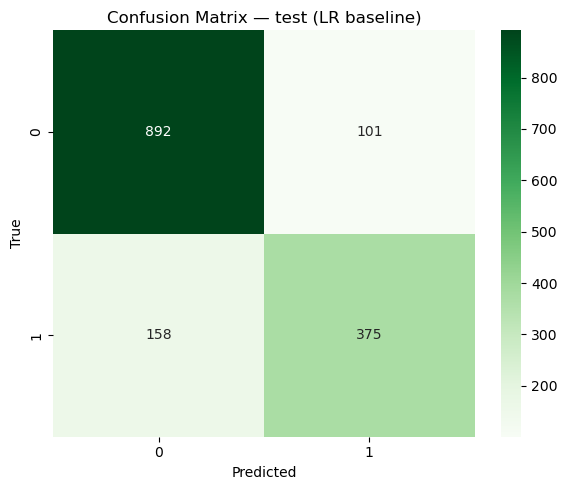

In [46]:
plot_confusion_matrix_simple(y_test, y_pred_lr_baseline_test,
                             title=f"Confusion Matrix — test (LR baseline)")

Модель лучше распознаёт пациентов с обычным течением болезни (класс 0): высокий recall (0.90) указывает на редкие пропуски таких случаев.

Для тяжёлых пациентов (класс 1) качество заметно ниже: полнота 0.70 означает, что около 30% тяжёлых случаев модель не выявляет, что критично с клинической точки зрения.

Взвешенная F1-мера составляет 0.83, что делает модель хорошей отправной точкой, но требующей улучшения чувствительности к классу тяжёлых пациентов (например, за счёт балансировки классов, настройки порога или более сложных моделей).

## 3. Применение и оценка логистической регрессии (LR)

### 1) Демо предобработки

Чтобы убедиться, что преобразователи работают корректно, применим разные стратегии к X_train, выведем графики и статистики.

In [47]:
STRATEGIES = ["log_standard", "log_clip_standard", "log_robust", "log_clip_robust"]

def apply_strategies(X_train, strategies=STRATEGIES):
    outputs = {}
    for s in strategies:
        processor = make_logreg_preprocessor(
            s,
            skewed_numeric=skewed_numeric,
            symmetric_numeric=symmetric_numeric,
            binary_features=binary_features,
            multi_category_features=multi_category_features,
            proc_col_names=False
        )
        X_proc = processor.fit_transform(X_train)
        cols = processor.get_feature_names_out()
        outputs[s] = pd.DataFrame(X_proc, columns=cols, index=X_train.index)
    return outputs

In [48]:
processed = apply_strategies(X_train)

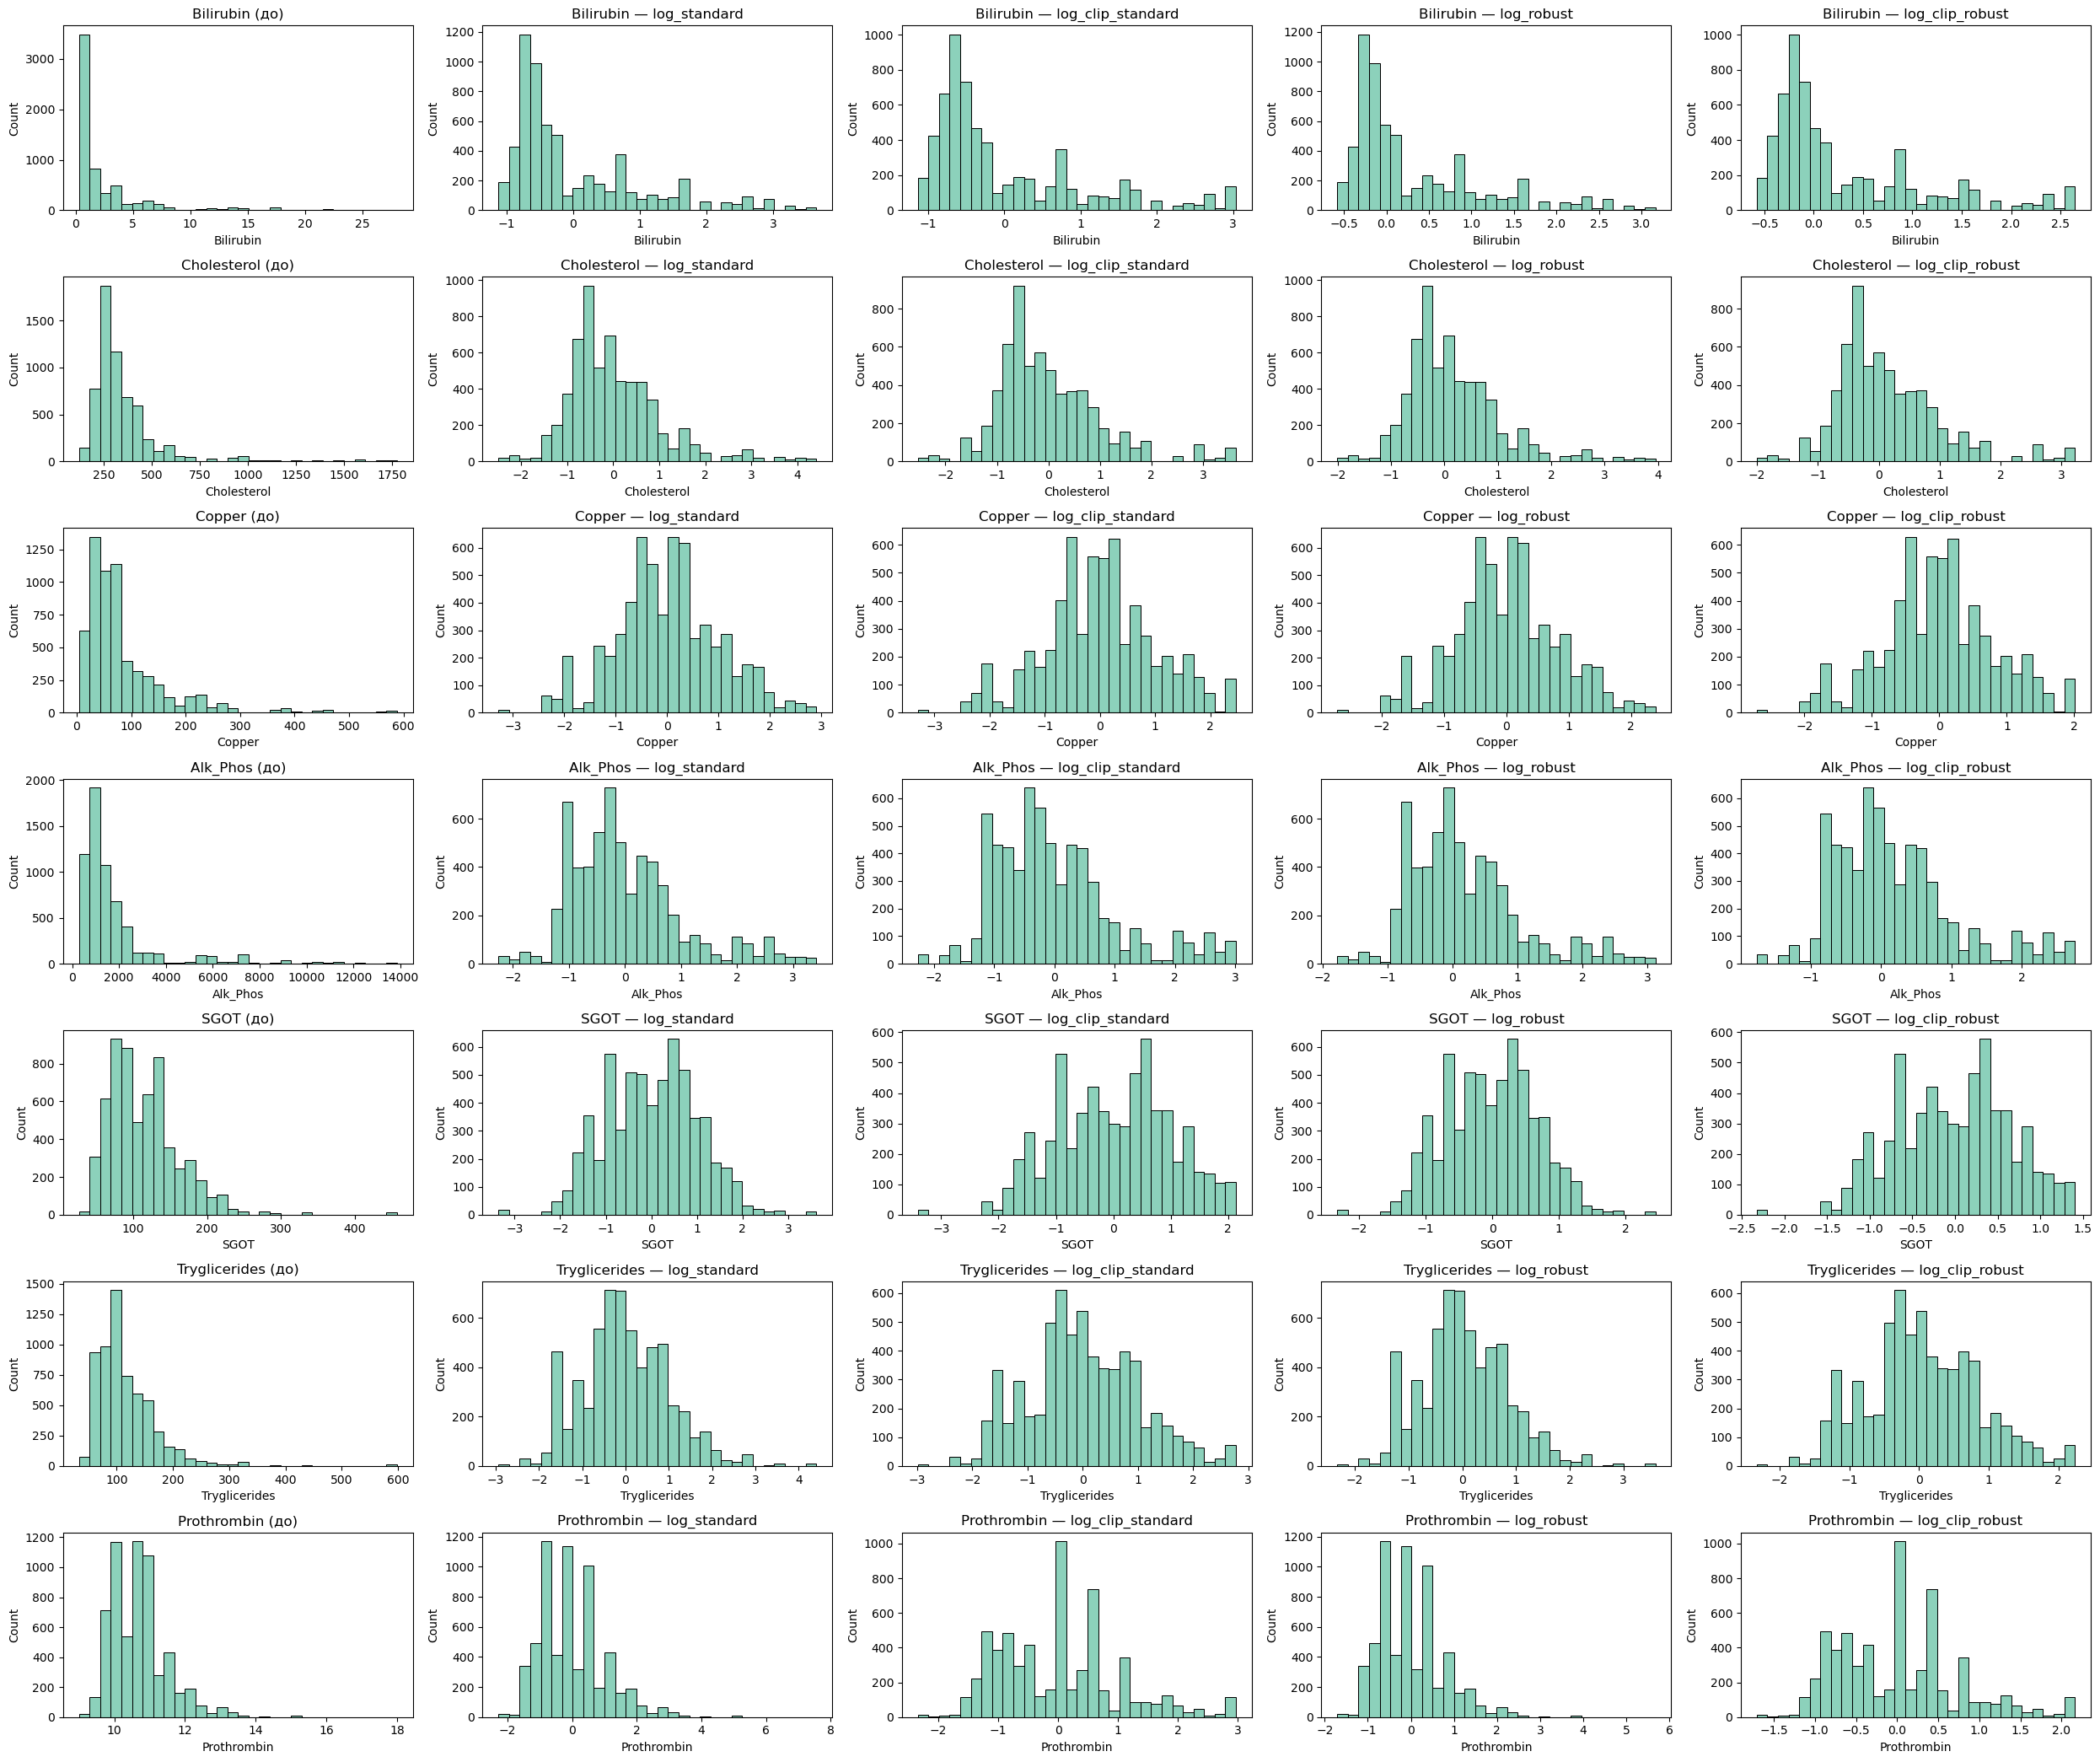

In [49]:
plot_skewed_changes(X_train, processed, skewed_numeric)

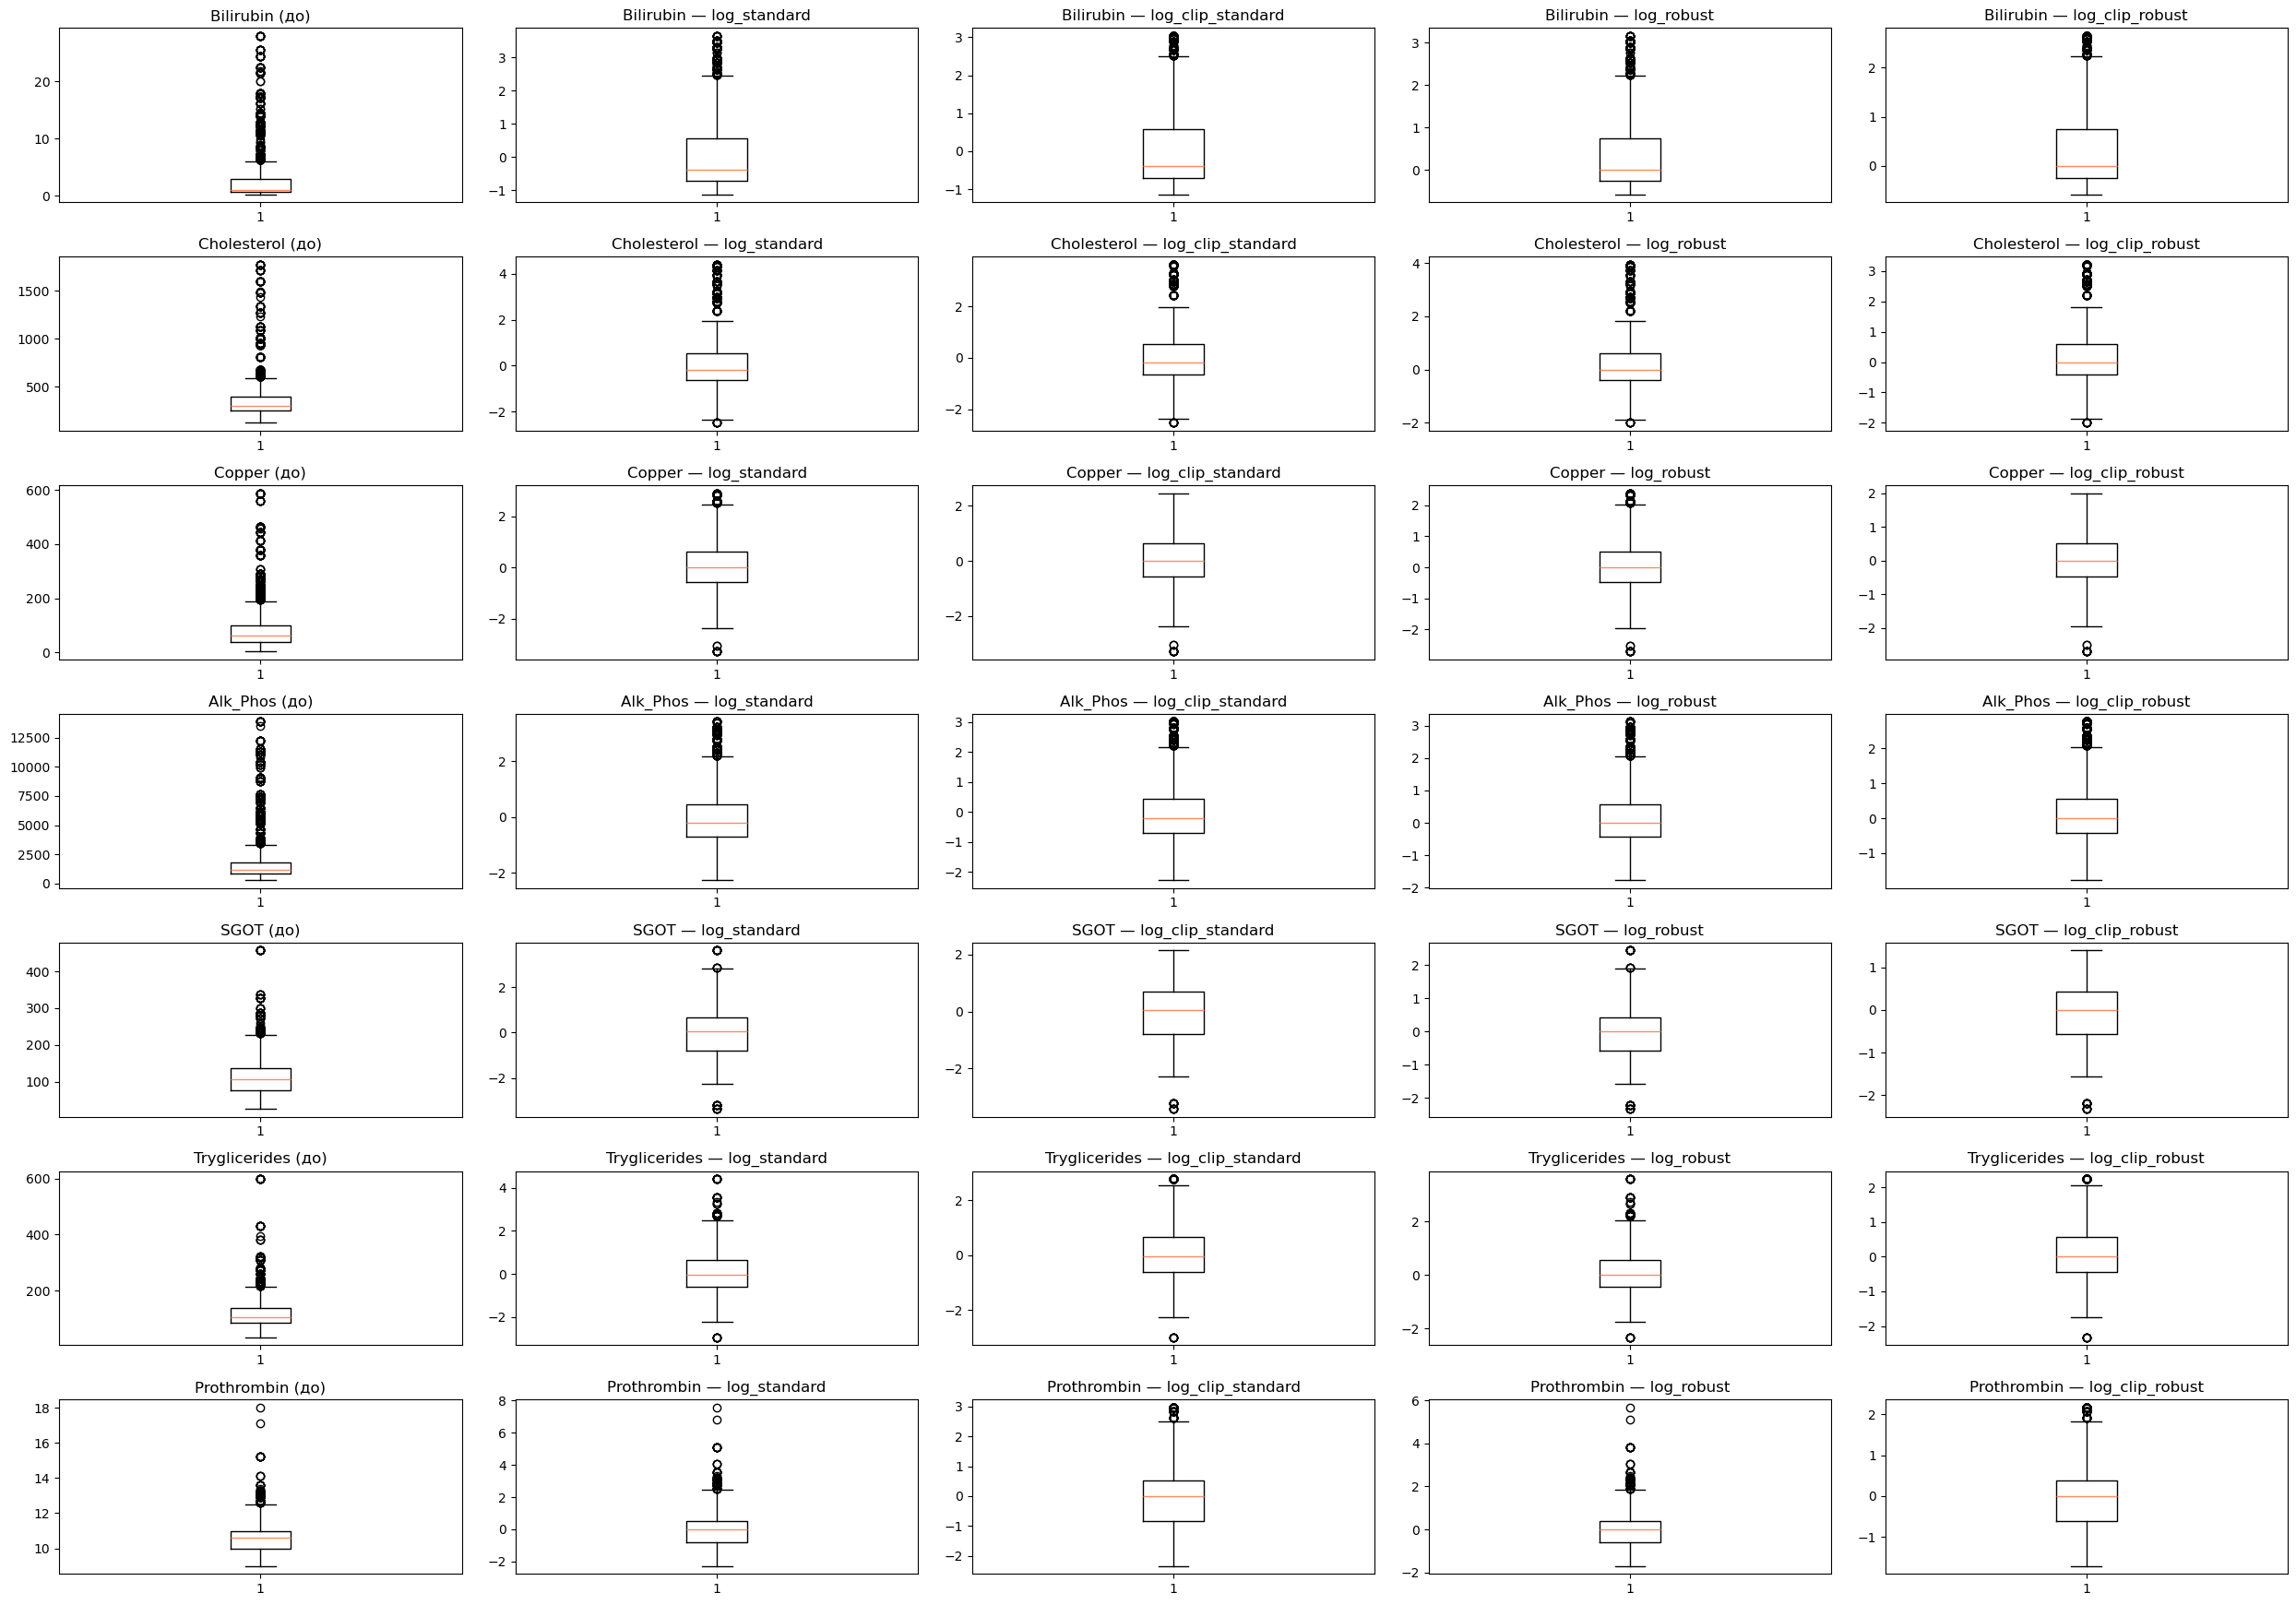

In [50]:
plot_boxplots(X_train, processed, skewed_numeric)

In [51]:
summarize_changes(X_train, processed, numeric_features)


=== СВОДКА ТРАНСФОРМАЦИЙ ЧИСЛОВЫХ ПРИЗНАКОВ ===


ПРИЗНАК: Age
  • исходный skew: 0.07
    - log_standard: skew=0.07, доля выбросов(|z|>3)=0.000
    - log_clip_standard: skew=0.07, доля выбросов(|z|>3)=0.000
    - log_robust: skew=0.07, доля выбросов(|z|>3)=0.000
    - log_clip_robust: skew=0.07, доля выбросов(|z|>3)=0.000

ПРИЗНАК: Bilirubin
  • исходный skew: 3.30
    - log_standard: skew=1.44, доля выбросов(|z|>3)=0.010
    - log_clip_standard: skew=1.38, доля выбросов(|z|>3)=0.012
    - log_robust: skew=1.44, доля выбросов(|z|>3)=0.010
    - log_clip_robust: skew=1.38, доля выбросов(|z|>3)=0.012

ПРИЗНАК: Cholesterol
  • исходный skew: 3.63
    - log_standard: skew=1.26, доля выбросов(|z|>3)=0.015
    - log_clip_standard: skew=1.12, доля выбросов(|z|>3)=0.017
    - log_robust: skew=1.26, доля выбросов(|z|>3)=0.015
    - log_clip_robust: skew=1.12, доля выбросов(|z|>3)=0.017

ПРИЗНАК: Albumin
  • исходный skew: -0.58
    - log_standard: skew=-0.58, доля выбросов(|z|>3)=0.015
    - 

Применённые преобразования позволяют эффективно уменьшить асимметрию распределений, снизить влияние выбросов и приблизить распределения числовых признаков к нормальным. Далее проанализируем работу конкретного преобразователя на основе численных статистических показателей.

In [52]:
preprocessor_lr = make_logreg_preprocessor(
    "log_clip_standard",
    skewed_numeric=skewed_numeric,
    symmetric_numeric=symmetric_numeric,
    binary_features=binary_features,
    multi_category_features=multi_category_features
)

In [53]:
df_proc = pd.DataFrame(preprocessor_lr.fit_transform(X_train), columns=preprocessor_lr.get_feature_names_out())

In [54]:
df_proc.head()

,num_skewed__Bilirubin,num_skewed__Cholesterol,num_skewed__Copper,num_skewed__Alk_Phos,num_skewed__SGOT,num_skewed__Tryglicerides,num_skewed__Prothrombin,num_symmetric__Age,num_symmetric__Albumin,num_symmetric__Platelets,binary__Drug,binary__Sex,binary__Ascites,binary__Hepatomegaly,binary__Spiders,category__Edema_S,category__Edema_Y,category__Stage_B,category__Stage_C,category__Stage_D
0,0.365671,1.416713,0.817915,-0.049729,0.847200,0.831303,0.134652,-1.680801,0.151520,0.296398,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.808440,0.328017,-0.216828,-0.102753,0.899275,1.486451,-0.982436,0.021346,1.017782,-1.006539,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2.995877,-1.554002,2.466007,-0.787794,1.389449,1.527506,2.965277,-0.377052,-2.302889,-0.868174,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
3,2.525029,0.116510,0.430788,0.150109,0.627402,-0.070790,0.533971,-0.429158,0.151520,0.134972,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.638962,0.427694,0.664009,-0.471459,0.509857,-0.147094,0.664862,0.079423,0.555776,0.008138,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [55]:
df_proc.shape

(6104, 20)

In [56]:
df_proc.describe().T

,count,mean,std,min,25%,50%,75%,max
num_skewed__Bilirubin,6104.0,-1.292108e-16,1.000082,-1.131869,-0.714008,-0.384863,0.579382,3.037639
num_skewed__Cholesterol,6104.0,-8.916706e-16,1.000082,-2.535609,-0.645027,-0.165635,0.537152,3.637798
num_skewed__Copper,6104.0,3.026558e-16,1.000082,-3.301729,-0.584547,0.009024,0.638636,2.466007
num_skewed__Alk_Phos,6104.0,-5.948351e-16,1.000082,-2.269281,-0.707868,-0.203528,0.459455,3.015599
num_skewed__SGOT,6104.0,1.070936e-16,1.000082,-3.405858,-0.802868,0.048940,0.684177,2.136337
num_skewed__Tryglicerides,6104.0,4.714446e-16,1.000082,-2.985370,-0.596702,-0.045843,0.666602,2.776406
num_skewed__Prothrombin,6104.0,-1.456240e-15,1.000082,-2.341653,-0.838396,-0.000733,0.533971,2.965277
num_symmetric__Age,6104.0,-1.277557e-16,1.000082,-2.394281,-0.765137,0.081052,0.614330,2.776208
num_symmetric__Albumin,6104.0,-8.291023e-16,1.000082,-4.584045,-0.570365,0.093769,0.642402,3.154562
num_symmetric__Platelets,6104.0,2.165153e-16,1.000082,-2.344068,-0.614505,-0.003393,0.596189,3.432672


Преобразования числовых признаков выполнены корректно и дали ожидаемый эффект. Для всех признаков среднее значение близко к 0, а стандартное отклонение к 1, что подтверждает успешную стандартизацию. Квантили (25%, 50%, 75%) расположены симметрично относительно нуля, что указывает на существенное снижение асимметрии распределений. Экстремальные значения (min/max) остаются, но их влияние заметно уменьшено по сравнению с исходными переменными. В целом распределения как ранее скошенных, так и симметричных признаков стали более сопоставимыми между собой и лучше подходят для последующего моделирования.

Проделаем то же самое для полиномиальных признаков и убедимся, что они также корректно проходят этап трансформаций.

In [57]:
poly_skewed = ["Bilirubin", "Copper"]
poly_symmetric = ["Albumin"]
preprocessor_poly = make_logreg_preprocessor(
    "log_clip_standard",
    skewed_numeric=skewed_numeric,
    symmetric_numeric=symmetric_numeric,
    binary_features=binary_features,
    multi_category_features=multi_category_features,
    use_poly=True,
    poly_skewed=poly_skewed,
    poly_symmetric=poly_symmetric,
    interaction_only=False
)

In [58]:
df_proc_poly = pd.DataFrame(preprocessor_poly.fit_transform(X_train), columns=preprocessor_poly.get_feature_names_out())

In [59]:
df_proc_poly.head()

,num_skewed__Bilirubin,num_skewed__Cholesterol,num_skewed__Copper,num_skewed__Alk_Phos,num_skewed__SGOT,num_skewed__Tryglicerides,num_skewed__Prothrombin,num_symmetric__Age,num_symmetric__Albumin,num_symmetric__Platelets,poly__Bilirubin^2,poly__Bilirubin Copper,poly__Bilirubin Albumin,poly__Copper^2,poly__Copper Albumin,poly__Albumin^2,binary__Drug,binary__Sex,binary__Ascites,binary__Hepatomegaly,binary__Spiders,category__Edema_S,category__Edema_Y,category__Stage_B,category__Stage_C,category__Stage_D
0,0.365671,1.416713,0.817915,-0.049729,0.847200,0.831303,0.134652,-1.680801,0.151520,0.296398,0.056665,0.427360,0.463679,0.779284,0.919543,0.106459,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.808440,0.328017,-0.216828,-0.102753,0.899275,1.486451,-0.982436,0.021346,1.017782,-1.006539,-0.617466,-0.723782,-0.760678,-0.301887,0.317595,1.045346,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2.995877,-1.554002,2.466007,-0.787794,1.389449,1.527506,2.965277,-0.377052,-2.302889,-0.868174,3.744414,3.831164,2.178618,2.906207,0.709421,-2.145827,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
3,2.525029,0.116510,0.430788,0.150109,0.627402,-0.070790,0.533971,-0.429158,0.151520,0.134972,2.862985,2.120900,2.838865,0.351829,0.532716,0.106459,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.638962,0.427694,0.664009,-0.471459,0.509857,-0.147094,0.664862,0.079423,0.555776,0.008138,1.465916,1.488606,2.000241,0.606059,1.001581,0.535259,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [60]:
df_proc_poly.shape

(6104, 26)

In [61]:
df_proc_poly.describe().T

,count,mean,std,min,25%,50%,75%,max
num_skewed__Bilirubin,6104.0,-1.292108e-16,1.000082,-1.131869,-0.714008,-0.384863,0.579382,3.037639
num_skewed__Cholesterol,6104.0,-8.916706e-16,1.000082,-2.535609,-0.645027,-0.165635,0.537152,3.637798
num_skewed__Copper,6104.0,3.026558e-16,1.000082,-3.301729,-0.584547,0.009024,0.638636,2.466007
num_skewed__Alk_Phos,6104.0,-5.948351e-16,1.000082,-2.269281,-0.707868,-0.203528,0.459455,3.015599
num_skewed__SGOT,6104.0,1.070936e-16,1.000082,-3.405858,-0.802868,0.048940,0.684177,2.136337
num_skewed__Tryglicerides,6104.0,4.714446e-16,1.000082,-2.985370,-0.596702,-0.045843,0.666602,2.776406
num_skewed__Prothrombin,6104.0,-1.456240e-15,1.000082,-2.341653,-0.838396,-0.000733,0.533971,2.965277
num_symmetric__Age,6104.0,-1.277557e-16,1.000082,-2.394281,-0.765137,0.081052,0.614330,2.776208
num_symmetric__Albumin,6104.0,-8.291023e-16,1.000082,-4.584045,-0.570365,0.093769,0.642402,3.154562
num_symmetric__Platelets,6104.0,2.165153e-16,1.000082,-2.344068,-0.614505,-0.003393,0.596189,3.432672


### 2) LR на исходном наборе данных

In [62]:
gs_lr = make_lr_gridsearch(
    skewed_numeric=skewed_numeric,
    symmetric_numeric=symmetric_numeric,
    binary_features=binary_features,
    multi_category_features=multi_category_features)

gs_lr.fit(X_train, y_train)

print_best_lr_params(gs_lr)
print(f"Best Recall: {gs_lr.best_score_:.4f}")
print("="*50)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits
Лучший результат общего пайплайна (LR):
Стратегия препроцессинга: log_clip_standard
Семплирование: RandomUnderSampler
C: 0.2
l1_ratio: 0.75
penalty: elasticnet
solver: saga
class_weight: None
Best Recall: 0.7950


In [63]:
y_pred_lr = cross_val_predict(
    gs_lr.best_estimator_,
    X_train, y_train,
    cv=skf,
    n_jobs=-1
)

print("Class report (LR best estimator):")
print(classification_report(y_train, y_pred_lr))

Class report (LR best estimator):
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      3972
           1       0.73      0.80      0.76      2132

    accuracy                           0.82      6104
   macro avg       0.81      0.82      0.81      6104
weighted avg       0.83      0.82      0.83      6104



В контексте задачи лучше всего себя показал пайплайн с RandomUnderSampler, log_clip_standard и регуляризацией. Модель достигает хорошего баланса по precision и recall.

Попробуем настроить порог вероятности, чтобы добиться нужного баланса FP/FN.

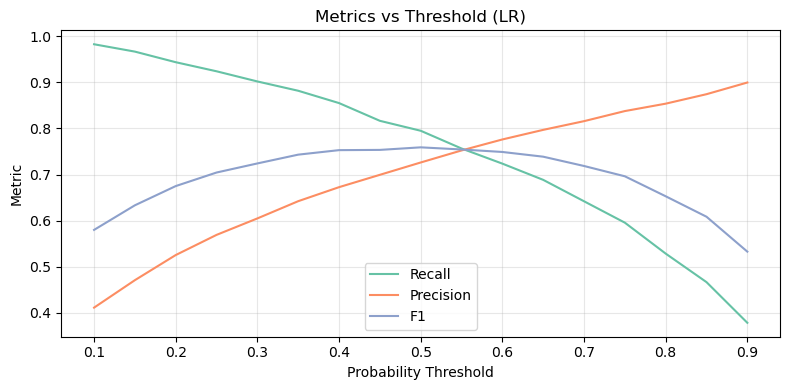

In [64]:
plot_threshold_curves(gs_lr.best_estimator_, X_train, y_train, cv=skf,
                      title="Metrics vs Threshold (LR)")

Выполним новый предикт с выбранным порогом. Хотим найти как можно больше тяжёлых пациентов, но при этом избежать слишком большого кол-ва ложноположительных.

In [65]:
THRESHOLD = 0.3

y_proba_lr = cross_val_predict(gs_lr.best_estimator_, X_train, y_train, method="predict_proba", cv=skf, n_jobs=-1)[:, 1]
y_pred_lr_thr = (y_proba_lr >= THRESHOLD).astype(int)

print(f"Class report (LR best estimator with threshold={THRESHOLD}):")
print(classification_report(y_train, y_pred_lr_thr))

Class report (LR best estimator with threshold=0.3):
              precision    recall  f1-score   support

           0       0.93      0.68      0.79      3972
           1       0.60      0.90      0.72      2132

    accuracy                           0.76      6104
   macro avg       0.77      0.79      0.76      6104
weighted avg       0.82      0.76      0.77      6104



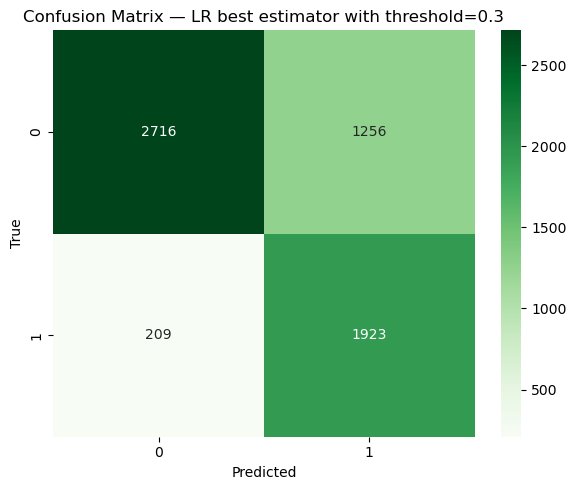

In [66]:
plot_confusion_matrix_simple(y_train, y_pred_lr_thr, title=f"Confusion Matrix — LR best estimator with threshold={THRESHOLD}")

Модель с выбранным порогом достигает значения recall в 0.9, при этом сохраняет precision на приемлемом уровне (~0.6). Далее мы попробуем улучшить метрики, добавив дополнительные признаки в нашу модель.

### 3) LR + Feature Engineering

Попробуем добавить кастомные признаки в наш датасет.

In [67]:
skewed_numeric_extended = skewed_numeric + ["Bilirubin_Albumin_Ratio", "Coagulation_Index", "Enzyme_Pattern"]
multi_category_features_extended = multi_category_features + ["Symptom_Score"]
poly_skewed = ["Bilirubin", "Copper", "Prothrombin"]
poly_symmetric = ["Albumin"]
fe_cols = ["Symptom_Score", "Bilirubin_Albumin_Ratio", "Coagulation_Index", "Enzyme_Pattern"]

gs_lr_fe = make_lr_gridsearch(use_fe=True,
                              fe_cols=fe_cols,
                              skewed_numeric=skewed_numeric_extended,
                              symmetric_numeric=symmetric_numeric,
                              binary_features=binary_features,
                              multi_category_features=multi_category_features_extended,
                              use_poly=True,
                              poly_skewed=poly_skewed,
                              poly_symmetric=poly_symmetric,
                              poly_degree=2,
                              interaction_only=False)

gs_lr_fe.fit(X_train, y_train)

print_best_lr_params(gs_lr_fe)
print(f"Best Recall: {gs_lr_fe.best_score_:.4f}")
print("="*50)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits
Лучший результат общего пайплайна (LR):
Стратегия препроцессинга: log_clip_standard
Семплирование: RandomUnderSampler
C: 0.3
l1_ratio: 0.75
penalty: elasticnet
solver: saga
class_weight: None
Best Recall: 0.7974


In [68]:
y_pred_lr_fe = cross_val_predict(
    gs_lr_fe.best_estimator_,
    X_train, y_train,
    cv=skf,
    n_jobs=-1
)

print("Class report (LR best estimator + FE):")
print(classification_report(y_train, y_pred_lr_fe))

Class report (LR best estimator + FE):
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      3972
           1       0.72      0.80      0.76      2132

    accuracy                           0.82      6104
   macro avg       0.80      0.82      0.81      6104
weighted avg       0.83      0.82      0.83      6104



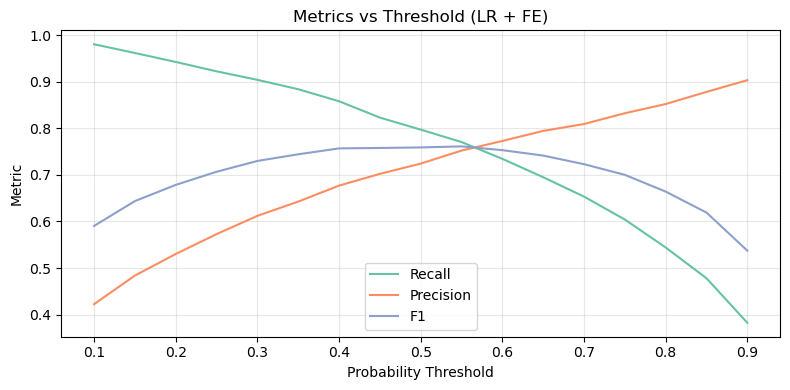

In [69]:
plot_threshold_curves(gs_lr_fe.best_estimator_, X_train, y_train, cv=skf,
                      title="Metrics vs Threshold (LR + FE)")

In [70]:
THRESHOLD = 0.3

y_proba_lr_fe = cross_val_predict(gs_lr_fe.best_estimator_, X_train, y_train, method="predict_proba", cv=skf, n_jobs=-1)[:, 1]
y_pred_lr_fe_thr = (y_proba_lr_fe >= THRESHOLD).astype(int)

print(f"Class report (LR + FE best estimator with threshold = {THRESHOLD}):")
print(classification_report(y_train, y_pred_lr_fe_thr))

Class report (LR + FE best estimator with threshold = 0.3):
              precision    recall  f1-score   support

           0       0.93      0.69      0.79      3972
           1       0.61      0.90      0.73      2132

    accuracy                           0.77      6104
   macro avg       0.77      0.80      0.76      6104
weighted avg       0.82      0.77      0.77      6104



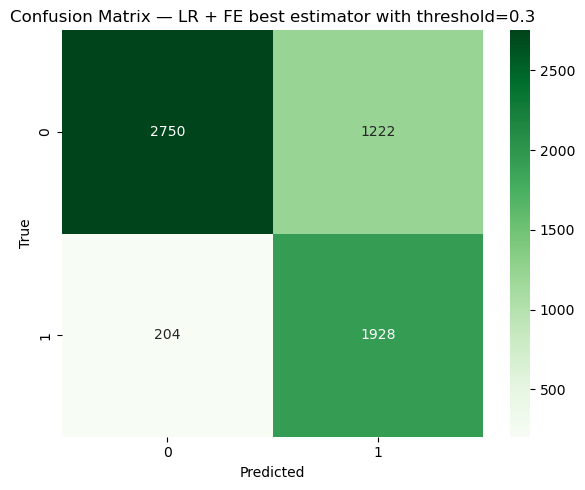

In [71]:
plot_confusion_matrix_simple(y_train, y_pred_lr_fe_thr, title=f"Confusion Matrix — LR + FE best estimator with threshold={THRESHOLD}")

Видим, что feature engineering помог незначительно улучшить качество: recall по-прежнему находится на отметке 0.9, а precision вырос до 0.61.

Теперь построим график коэффициентов логрега к признакам и попробуем исключить такие фичи, которые имеют коэффициенты, близкие к нулю, так как они практически не влияют на предсказание модели и лишь усложняют её без заметного прироста качества.

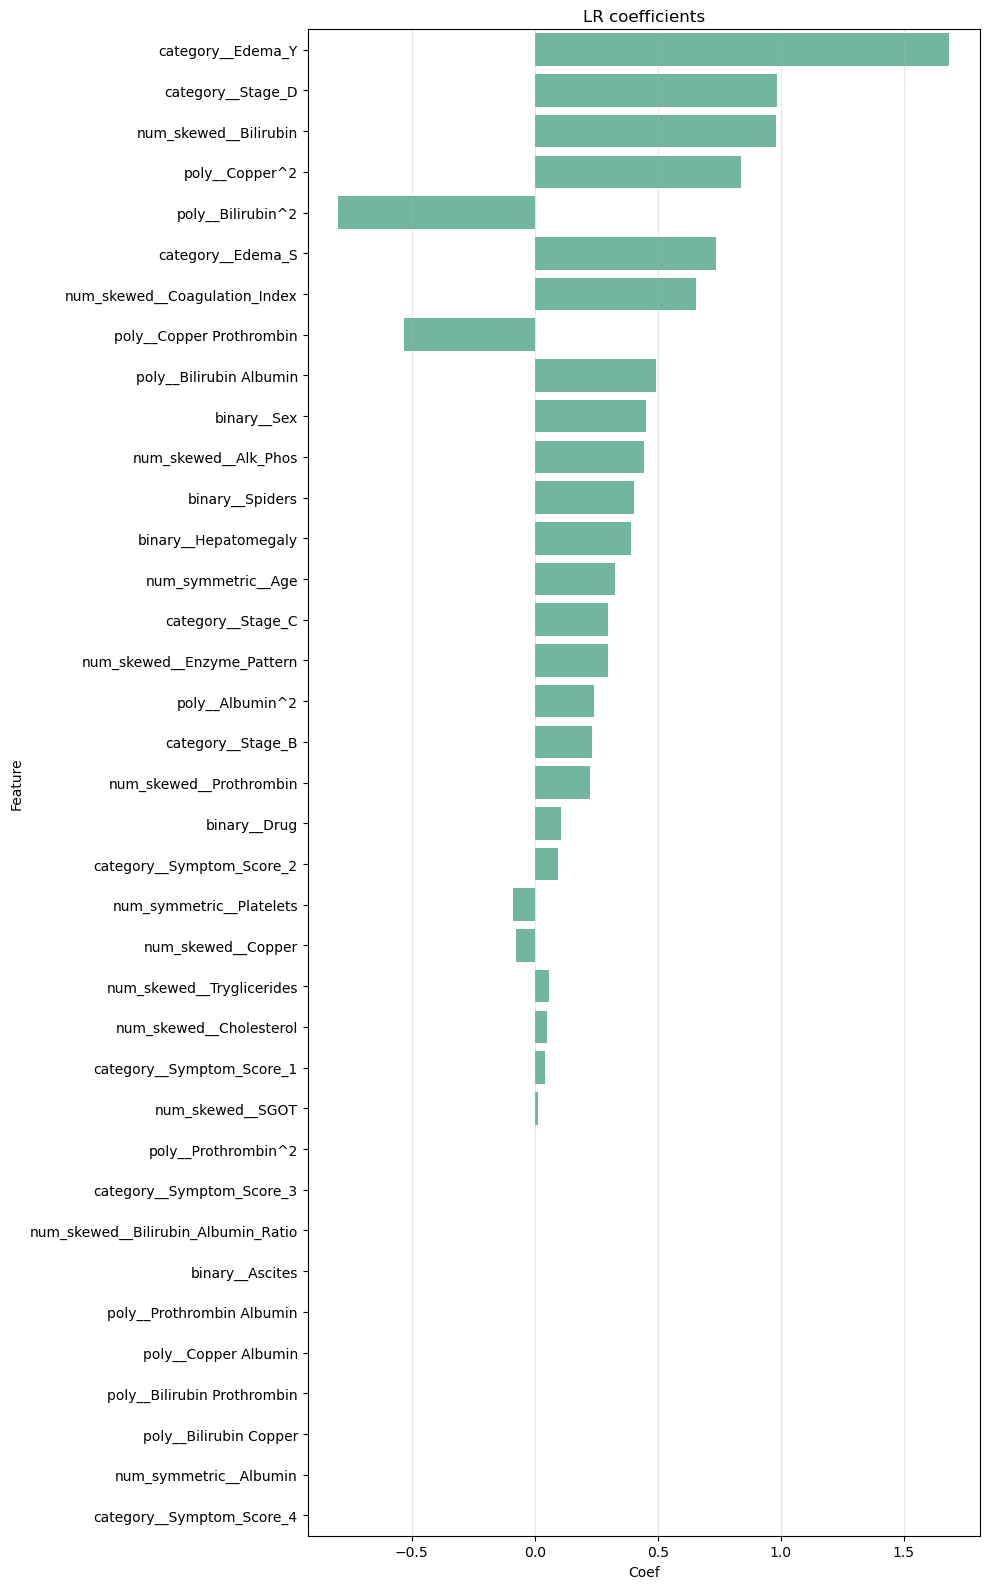

,feature,coef,abs_coef
29,category__Edema_Y,1.686441e+00,1.686441e+00
32,category__Stage_D,9.845479e-01,9.845479e-01
0,num_skewed__Bilirubin,9.794118e-01,9.794118e-01
17,poly__Copper^2,8.373780e-01,8.373780e-01
13,poly__Bilirubin^2,-7.993858e-01,7.993858e-01
28,category__Edema_S,7.370700e-01,7.370700e-01
8,num_skewed__Coagulation_Index,6.546817e-01,6.546817e-01
18,poly__Copper Prothrombin,-5.319761e-01,5.319761e-01
16,poly__Bilirubin Albumin,4.931050e-01,4.931050e-01
24,binary__Sex,4.519962e-01,4.519962e-01


In [72]:
plot_logreg_feature_coef(gs_lr_fe, top_n=None, title="LR coefficients")

- Наибольший вклад в риск тяжёлого течения (класс 1) дают отёки: наличие Edema_Y резко повышает вероятность плохого прогноза.

- Дальше по предиктивной силе идут маркеры стадии и лабораторные показатели: category__Stage_D, а также нелинейные варианты Copper и Bilirubin (poly__Copper^2, poly__Bilirubin^2) и кастомный признак num_skewed__Coagulation_Index.

- Остальные признаки (пол, сосудистые "звёздочки", увеличение печени, возраст, Stage B-C и т.п.) дают умеренный/малый вклад.

- Есть ряд нулевых и почти нулевых признаков - после учёта ключевых факторов они почти не добавляют информации.

Попробуем исключить бинарные признаки и мультикатегориальный Stage (медицинские эвристики), на которые модель слишком сильно полагается. Уберём также часть биохимических показатеолей, оставим два полинома и два кастомных признака.

In [73]:
skewed_numeric_new = ['Bilirubin', 'Copper', 'Alk_Phos', 'SGOT', 'Prothrombin', 'Coagulation_Index', 'Enzyme_Pattern']
symmetric_numeric_new = ["Age"]
multi_category_features_new = ["Edema"]
poly_skewed_new = ["Bilirubin", "Copper"]
fe_cols_new = ["Coagulation_Index", "Enzyme_Pattern"]

gs_lr_fe_new = make_lr_gridsearch(use_fe=True,
                              fe_cols=fe_cols_new,
                              skewed_numeric=skewed_numeric_new,
                              symmetric_numeric=symmetric_numeric_new,
                              binary_features=binary_features,
                              multi_category_features=multi_category_features_new,
                              use_poly=True,
                              poly_skewed=poly_skewed_new,
                              poly_symmetric=[],
                              poly_degree=2,
                              interaction_only=False)

gs_lr_fe_new.fit(X_train, y_train)

print_best_lr_params(gs_lr_fe_new)
print(f"Best Recall: {gs_lr_fe_new.best_score_:.4f}")
print("="*50)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits
Лучший результат общего пайплайна (LR):
Стратегия препроцессинга: log_clip_standard
Семплирование: SMOTE
C: 0.3
l1_ratio: 0.75
penalty: elasticnet
solver: saga
class_weight: None
Best Recall: 0.7969


In [74]:
t0 = perf_counter()

y_pred_lr_fe_new = cross_val_predict(
    gs_lr_fe_new.best_estimator_,
    X_train, y_train,
    cv=skf,
    n_jobs=-1
)

t1 = perf_counter()
cross_val_lr_fe_new_time = t1 - t0

print("Class report (LR best estimator + FE, some features removed):")
print(classification_report(y_train, y_pred_lr_fe_new))
print(f"Execution time: {cross_val_lr_fe_new_time:.4f} seconds")

Class report (LR best estimator + FE, some features removed):
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      3972
           1       0.73      0.80      0.76      2132

    accuracy                           0.82      6104
   macro avg       0.81      0.82      0.81      6104
weighted avg       0.83      0.82      0.83      6104

Execution time: 0.2812 seconds


Модель едва заметно потеряла в recall по сравнению с расширенным набором признаков, однако демонстрирует чуть более высокий precision и превосходит по recall версию с исходным набором признаков.

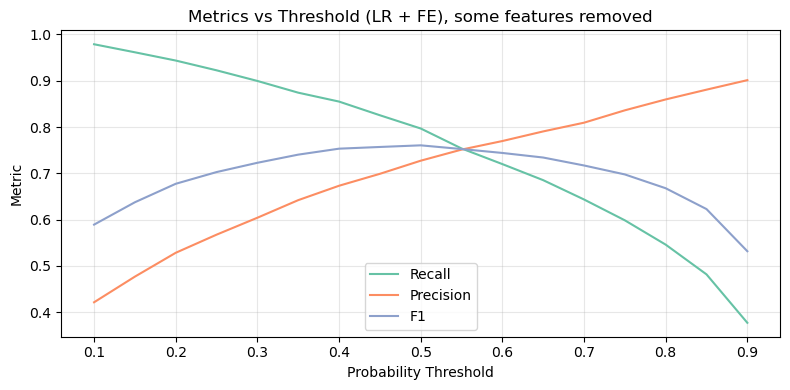

In [75]:
plot_threshold_curves(gs_lr_fe_new.best_estimator_, X_train, y_train, cv=skf,
                      title="Metrics vs Threshold (LR + FE), some features removed")

In [76]:
THRESHOLD = 0.3

y_proba_lr_fe_new = cross_val_predict(gs_lr_fe_new.best_estimator_, X_train, y_train, method="predict_proba", cv=skf, n_jobs=-1)[:, 1]
y_pred_lr_fe_new_thr = (y_proba_lr_fe_new >= THRESHOLD).astype(int)

print(f"Class report (LR best estimator + FE, some features removed, threshold = {THRESHOLD})")
print(classification_report(y_train, y_pred_lr_fe_new_thr))

Class report (LR best estimator + FE, some features removed, threshold = 0.3)
              precision    recall  f1-score   support

           0       0.93      0.68      0.79      3972
           1       0.60      0.90      0.72      2132

    accuracy                           0.76      6104
   macro avg       0.77      0.79      0.75      6104
weighted avg       0.81      0.76      0.76      6104



При изменении порога модель показывает такое же качество, как модель с исходным набором признаков, лишь незначительно уступая по precision модели с расширенным набором признаков.

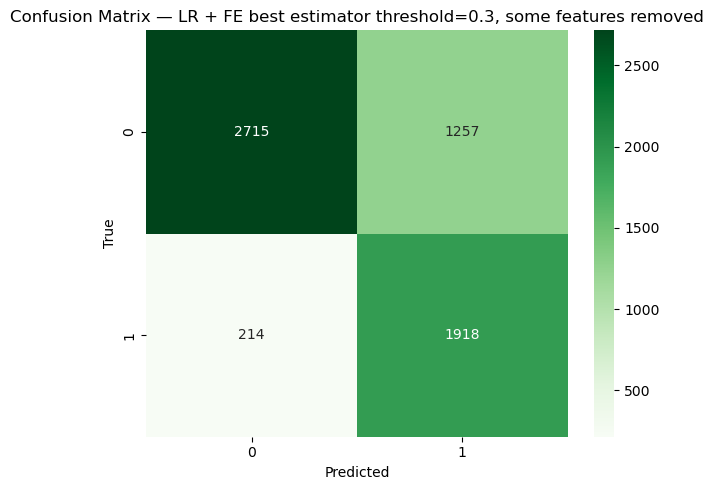

In [77]:
plot_confusion_matrix_simple(y_train, y_pred_lr_fe_new_thr,
                             title=f"Confusion Matrix — LR + FE best estimator threshold={THRESHOLD}, some features removed")

### 4) Лучшая LR модель на тесте

В качестве лучшей модели выберем версию с сокращённым набором признаков, поскольку она демострирует практически такое же качество, как и остальные, однако обладает лучшей интерпретируемостью и позволяет эффективно сделать вывод о состоянии пациента по меньшему кол-ву данных.

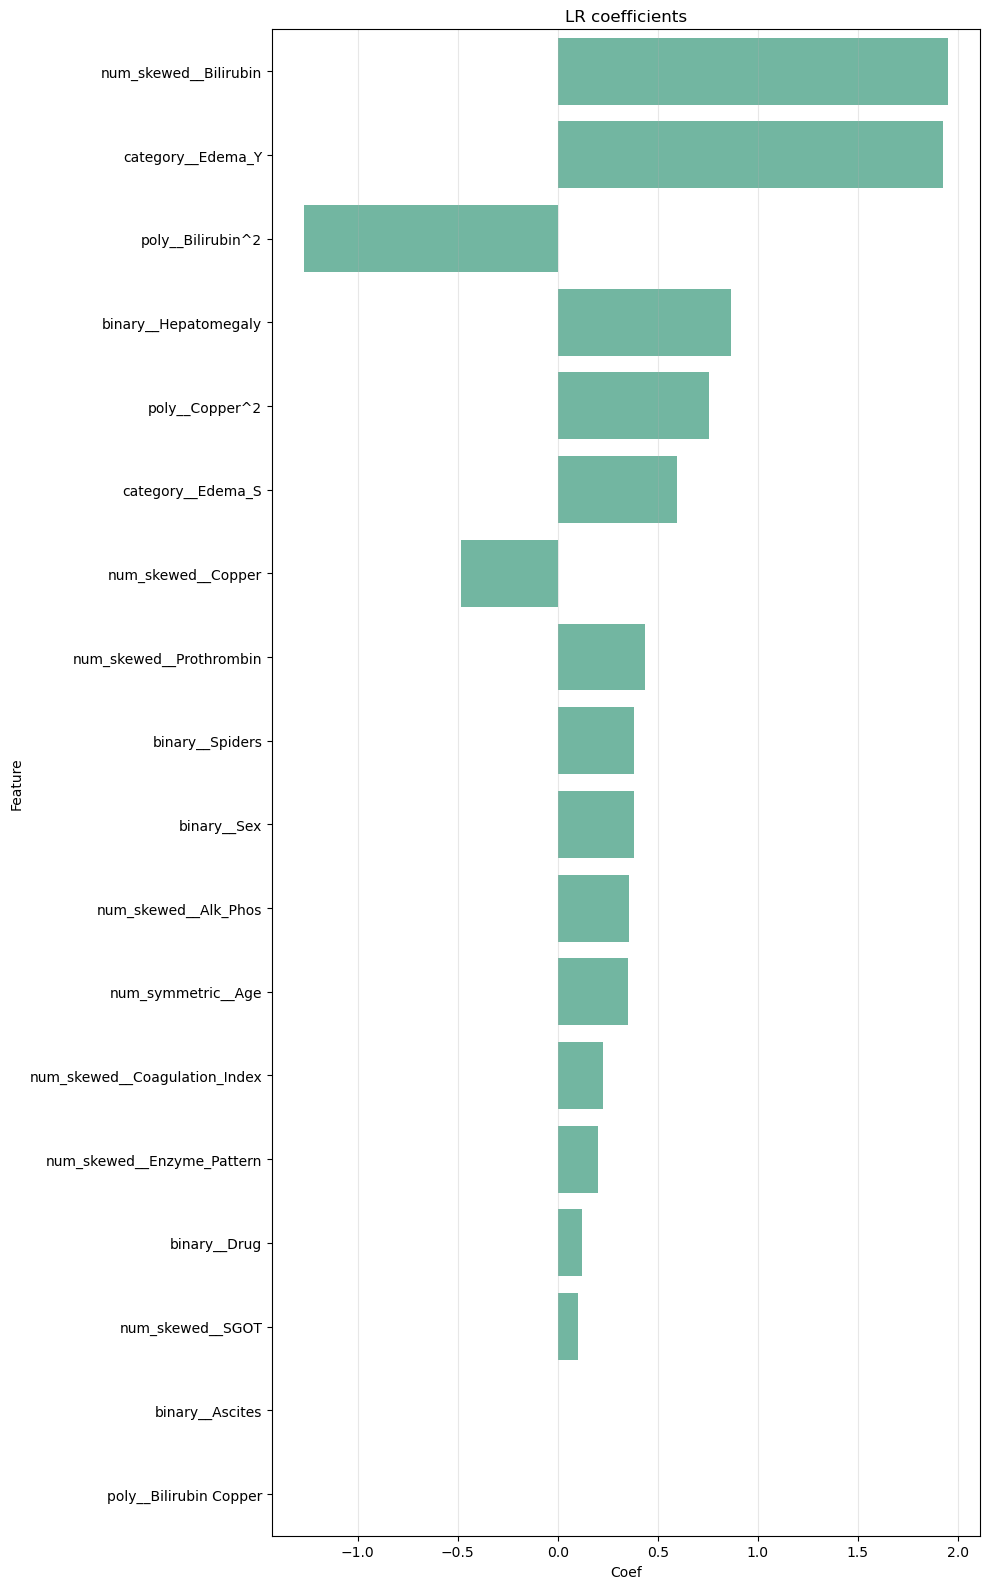

,feature,coef,abs_coef
0,num_skewed__Bilirubin,1.949618,1.949618
17,category__Edema_Y,1.925584,1.925584
8,poly__Bilirubin^2,-1.267693,1.267693
14,binary__Hepatomegaly,0.863714,0.863714
10,poly__Copper^2,0.756376,0.756376
16,category__Edema_S,0.594886,0.594886
1,num_skewed__Copper,-0.486291,0.486291
4,num_skewed__Prothrombin,0.436072,0.436072
15,binary__Spiders,0.382555,0.382555
12,binary__Sex,0.379838,0.379838


In [78]:
plot_logreg_feature_coef(gs_lr_fe_new, top_n=None, title="LR coefficients")

In [79]:
t0 = perf_counter()
gs_lr_fe_new.best_estimator_.fit(X_train, y_train)
t1 = perf_counter()
full_fit_lr_fe_new_time = t1 - t0

print(f"Execution time: {full_fit_lr_fe_new_time:.4f} seconds")

Execution time: 0.1397 seconds


In [80]:
THRESHOLD_LR = 0.3

t0 = perf_counter()
y_proba_lr_test = gs_lr_fe_new.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_lr_test = (y_proba_lr_test >= THRESHOLD_LR).astype(int)
t1 = perf_counter()
test_lr_fe_new_time = t1 - t0

print(f"Execution time: {test_lr_fe_new_time:.4f} seconds")

Execution time: 0.0229 seconds


In [81]:
print(f"Class report test (threshold={THRESHOLD_LR}):")
print(classification_report(y_test, y_pred_lr_test))

Class report test (threshold=0.3):
              precision    recall  f1-score   support

           0       0.91      0.66      0.76       993
           1       0.58      0.89      0.70       533

    accuracy                           0.74      1526
   macro avg       0.75      0.77      0.73      1526
weighted avg       0.80      0.74      0.74      1526



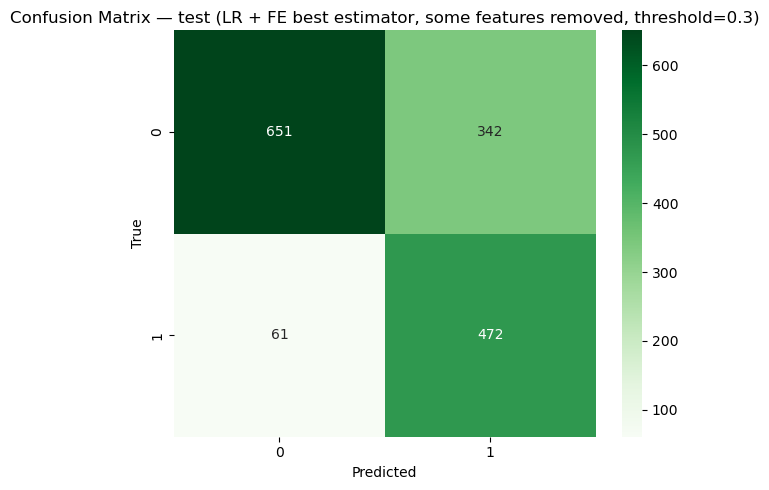

In [82]:
plot_confusion_matrix_simple(y_test, y_pred_lr_test,
                             title=f"Confusion Matrix — test (LR + FE best estimator, some features removed, threshold={THRESHOLD_LR})")

recall = 0.89 — модель находит подавляющее большинтво всех тяжёлых пациентов. precision = 0.58 — чуть более 40% помеченных как тяжёлые окажутся не тяжёлыми => их можно отправлять на дообследование.

Для класса 0 (нет тяжёлого течения): precision = 0.91 — если модель говорит, что тяжёлого течения нет, ей почти всегда можно доверять.

Вывод: при пороге 0.3 модель настроена как "скрининговая": она делает упор на минимизацию пропусков тяжёлых случаев, сознательно допуская больше ложноположительных, которых можно отфильтровать на этапе углублённой диагностики.

## 4. Применение и оценка дерева решений (DT)

### 1) DT на исходном наборе данных

In [83]:
processor_dt = make_tree_processor(binary_maps, binary_features, multi_category_features)
gs_dt = make_tree_gridsearch(preprocessor=processor_dt, use_fe=False)

gs_dt.fit(X_train, y_train)
print("Decision Tree:")
print("Best params:", gs_dt.best_params_)
print("Best recall:", gs_dt.best_score_)

Decision Tree:
Best params: {'dt__class_weight': 'balanced', 'dt__criterion': 'entropy', 'dt__max_depth': 3, 'dt__max_features': 'sqrt', 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2, 'sampler': 'passthrough'}
Best recall: 0.8461512242856044


In [84]:
t0 = perf_counter()

y_pred_dt = cross_val_predict(
    gs_dt.best_estimator_,
    X_train, y_train,
    cv=skf,
    n_jobs=-1
)

t1 = perf_counter()
cross_val_dt_time = t1 - t0

print("Class report (decision tree):")
print(classification_report(y_train, y_pred_dt))
print(f"Execution time: {cross_val_dt_time:.4f} seconds")

Class report (decision tree):
              precision    recall  f1-score   support

           0       0.89      0.67      0.76      3972
           1       0.58      0.85      0.69      2132

    accuracy                           0.73      6104
   macro avg       0.73      0.76      0.73      6104
weighted avg       0.78      0.73      0.74      6104

Execution time: 0.0643 seconds


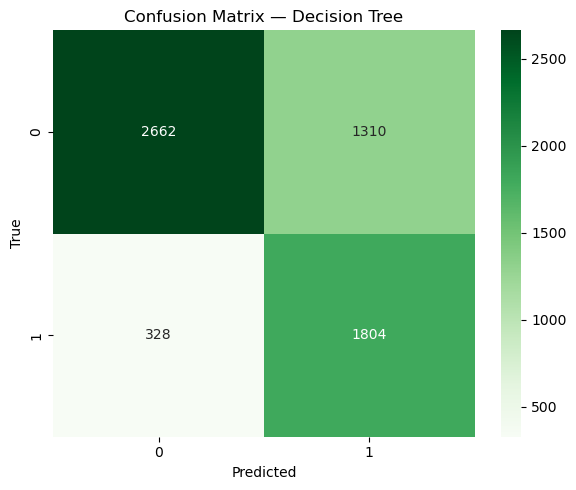

In [85]:
plot_confusion_matrix_simple(y_train, y_pred_dt, title="Confusion Matrix — Decision Tree")

На данный момент оптимальной по балансу метрик recall и precision является модель Decision Tree с весами классов:

- recall - 0.85
- precision - 0.58

Можем получить информацию о логике работы решающего дерева в графическом виде. На практике данный подход позволил бы легко и точно интерпретировать решения модели.

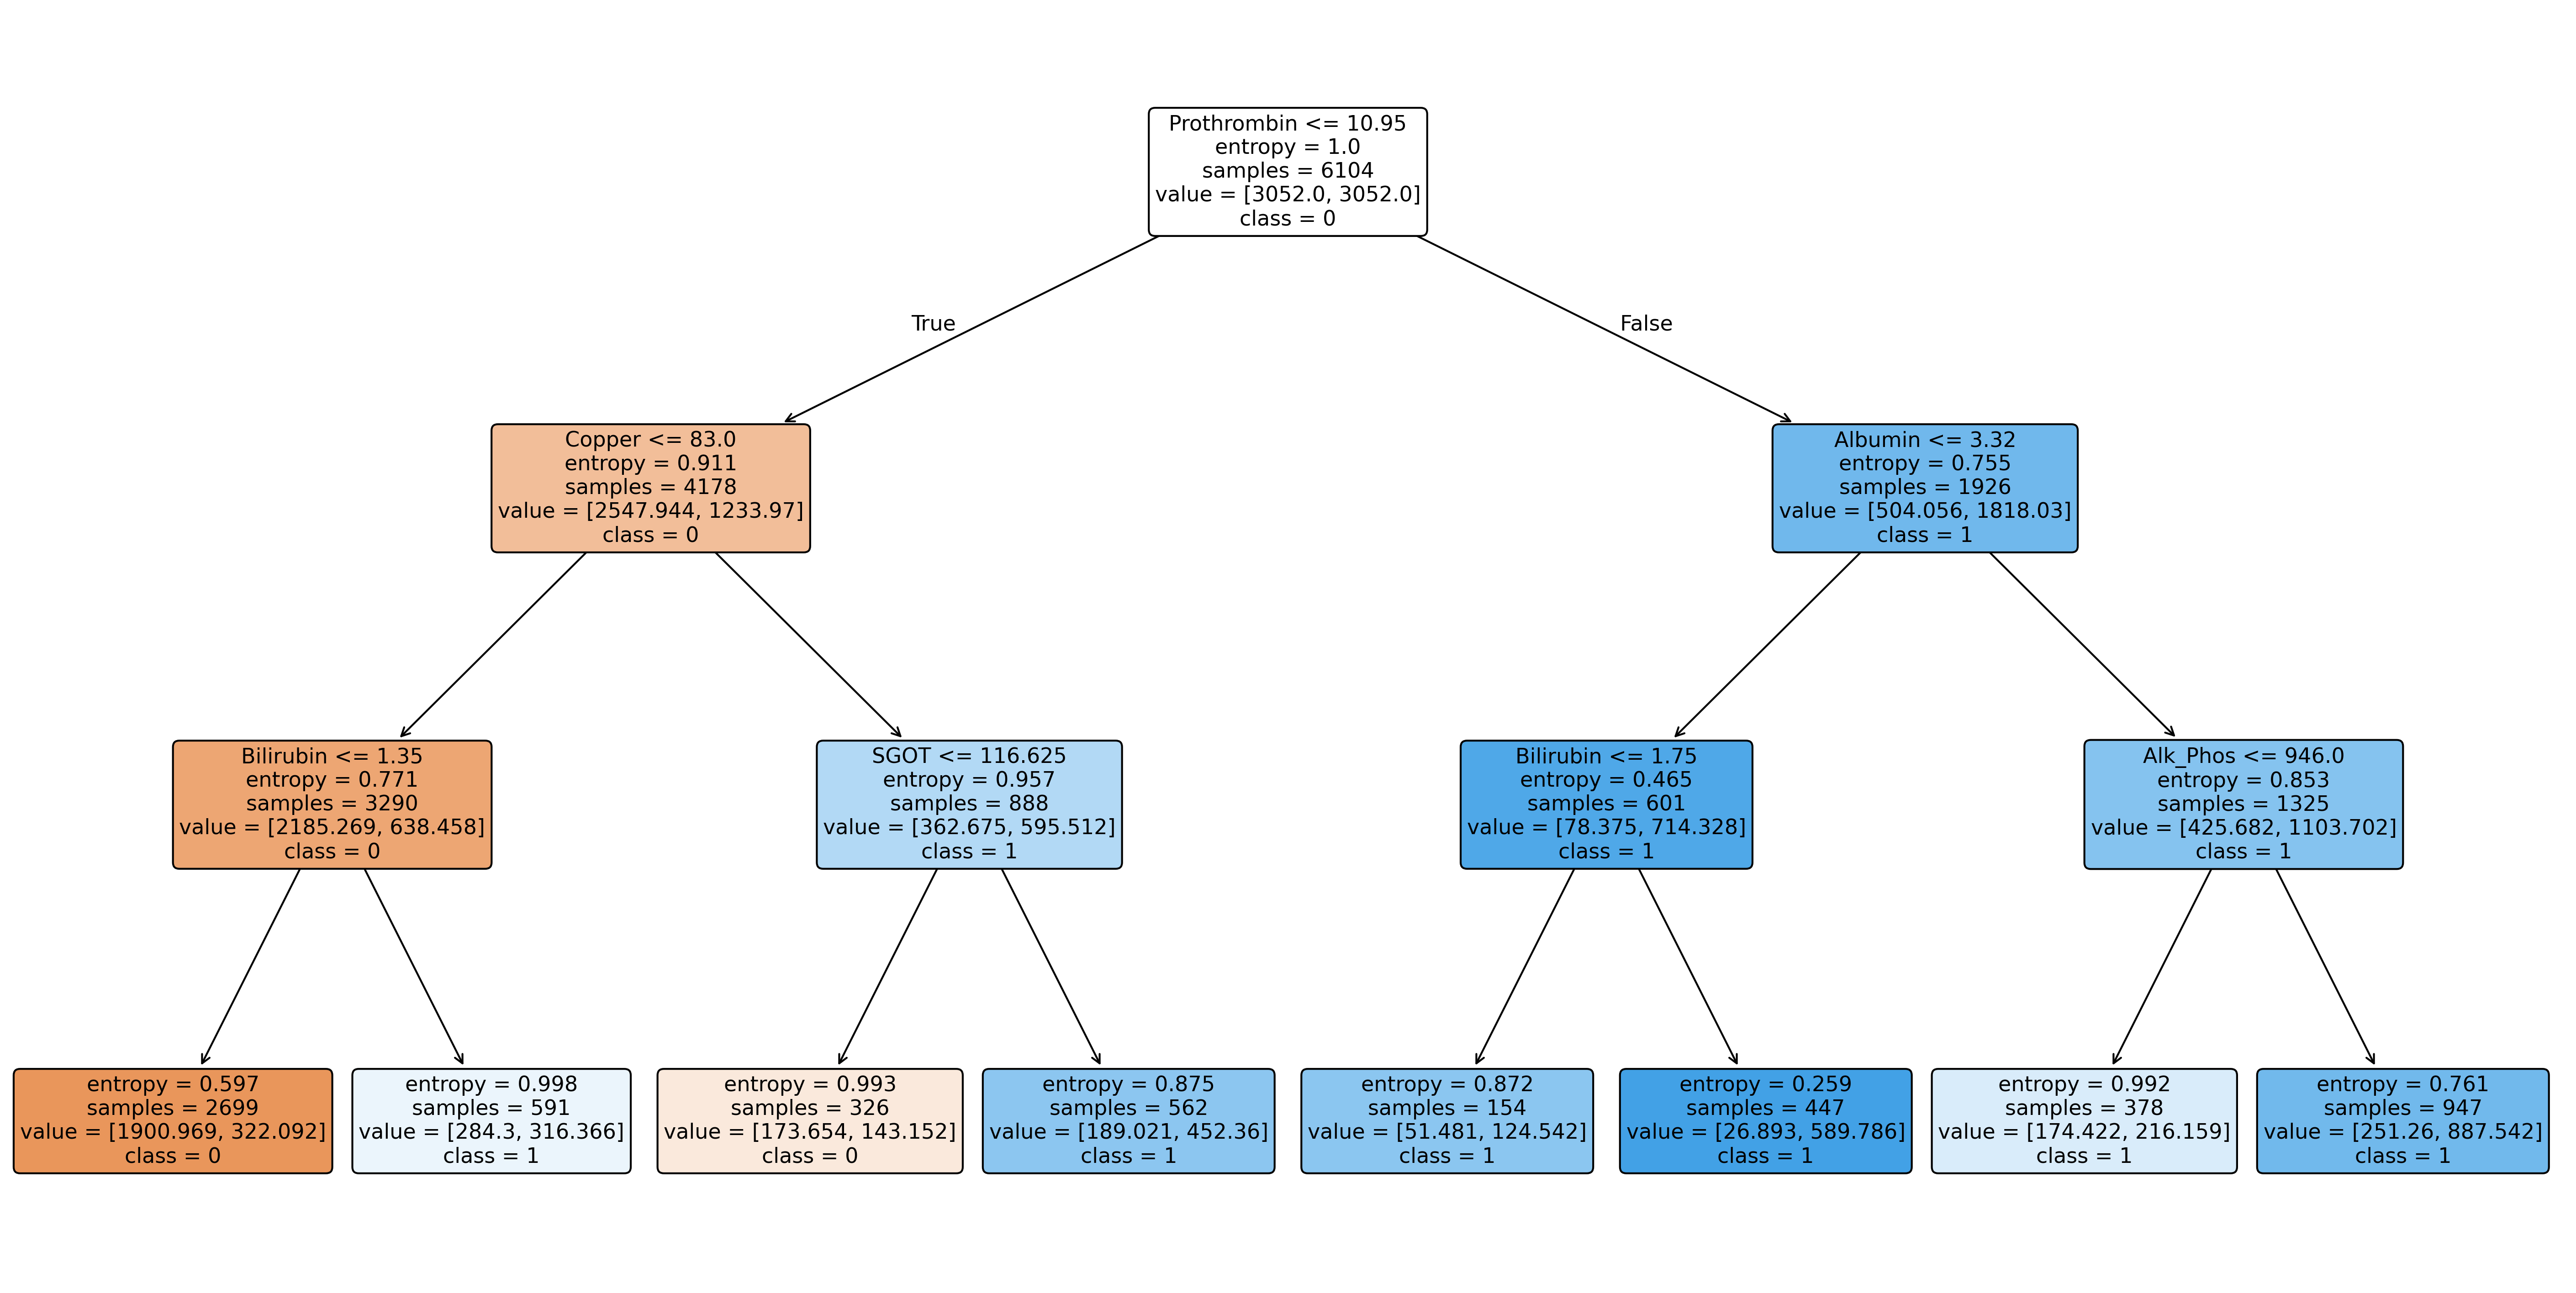

In [86]:
plot_tree_from_estimator(gs_dt)

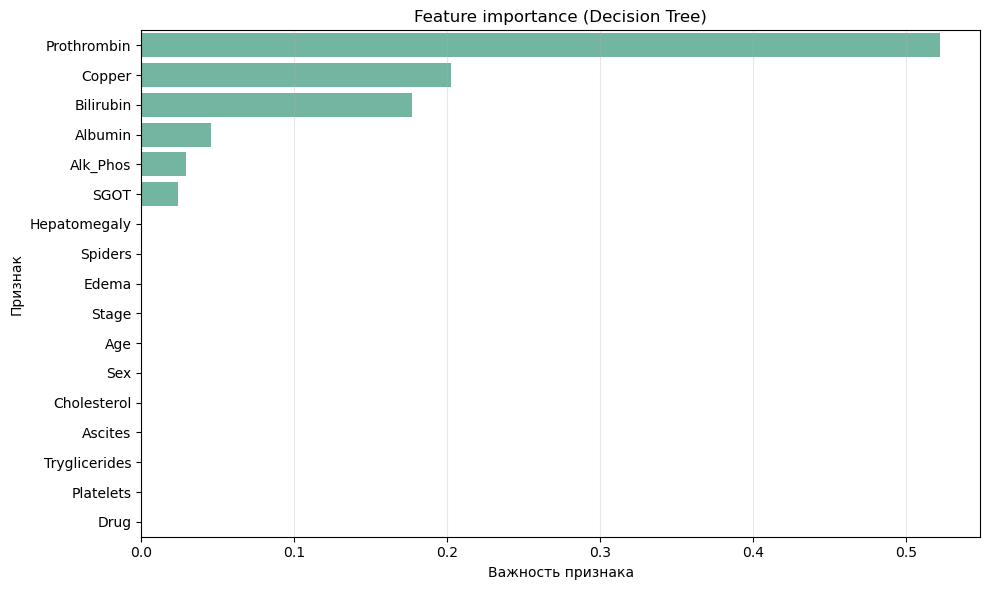

,feature,importance
16,Prothrombin,0.522132
11,Copper,0.202426
8,Bilirubin,0.177074
10,Albumin,0.045494
12,Alk_Phos,0.029097
13,SGOT,0.023777
3,Hepatomegaly,0.000000
4,Spiders,0.000000
5,Edema,0.000000
6,Stage,0.000000


In [87]:
plot_feature_importances(gs_dt,
                         title="Feature importance (Decision Tree)"
                        )

Попробуем исключить признаки с нулевой значимостью и проверим качество на кросс-валидации.

In [88]:
cols_to_drop = ['Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders',
                'Edema', 'Cholesterol', 'Tryglicerides', 'Platelets', 'Stage']

X_train_new = X_train.drop(cols_to_drop, axis=1).copy()

processor_short = make_tree_processor(binary_maps={}, binary_features=[], multi_category_features=[])

gs_dt_short = make_tree_gridsearch(preprocessor=processor_short, use_fe=False)

gs_dt_short.fit(X_train_new, y_train)
print("DT (some features removed):")
print("Best params:", gs_dt_short.best_params_)
print("Best recall:", gs_dt_short.best_score_)

DT (some features removed):
Best params: {'dt__class_weight': 'balanced', 'dt__criterion': 'gini', 'dt__max_depth': 5, 'dt__max_features': 'sqrt', 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2, 'sampler': 'passthrough'}
Best recall: 0.8020714450638255


In [89]:
y_pred_dt_short = cross_val_predict(
    gs_dt_short.best_estimator_,
    X_train_new, y_train,
    cv=skf,
    n_jobs=-1
)

print("Class report (decision tree, some features removed):")
print(classification_report(y_train, y_pred_dt_short))

Class report (decision tree, some features removed):
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      3972
           1       0.65      0.80      0.72      2132

    accuracy                           0.78      6104
   macro avg       0.76      0.78      0.77      6104
weighted avg       0.80      0.78      0.78      6104



Видим, что удаление части признаков привело к значительному улучшению precision, однако ключевая метрика recall снизилась на 5 единиц. Вернёмся к исходному набору признаков и попробуем подобрать порог, чтобы максимизировать recall, но не сильно потерять в precision.

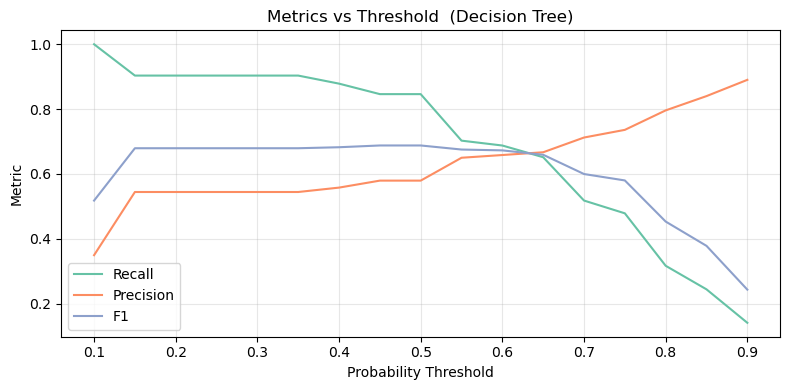

In [90]:
plot_threshold_curves(gs_dt, X_train, y_train, cv=skf,
                      title="Metrics vs Threshold  (Decision Tree)")

In [91]:
THRESHOLD = 0.35

y_proba_dt = cross_val_predict(
    gs_dt.best_estimator_,
    X_train, y_train,
    method="predict_proba",
    cv=skf,
    n_jobs=-1
)[:, 1]

y_pred_dt_thr = (y_proba_dt >= THRESHOLD).astype(int)

print(f"Class report (DT with threshold = {THRESHOLD}):")
print(classification_report(y_train, y_pred_dt_thr))

Class report (DT with threshold = 0.35):
              precision    recall  f1-score   support

           0       0.92      0.59      0.72      3972
           1       0.54      0.90      0.68      2132

    accuracy                           0.70      6104
   macro avg       0.73      0.75      0.70      6104
weighted avg       0.79      0.70      0.71      6104



### 2) DT + Feature Engineering

Попробуем добавить кастомные признаки, которые потенциально могут улучшить качество модели

In [92]:
processor_dt_fe = make_tree_processor(binary_maps, binary_features, multi_category_features)
gs_dt_fe = make_tree_gridsearch(preprocessor=processor_dt_fe, use_fe=True)

gs_dt_fe.fit(X_train, y_train)
print("DT + FE:")
print("Best params:", gs_dt_fe.best_params_)
print("Best recall:", gs_dt_fe.best_score_)

DT + FE:
Best params: {'dt__class_weight': 'balanced', 'dt__criterion': 'entropy', 'dt__max_depth': 3, 'dt__max_features': None, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2, 'sampler': 'passthrough'}
Best recall: 0.7987762641422305


In [93]:
y_pred_dt_fe = cross_val_predict(
    gs_dt_fe.best_estimator_,
    X_train, y_train,
    cv=skf,
    n_jobs=-1
)

print("Class report(DT + FE):")
print(classification_report(y_train, y_pred_dt_fe))

Class report(DT + FE):
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      3972
           1       0.65      0.80      0.72      2132

    accuracy                           0.78      6104
   macro avg       0.77      0.79      0.77      6104
weighted avg       0.80      0.78      0.79      6104



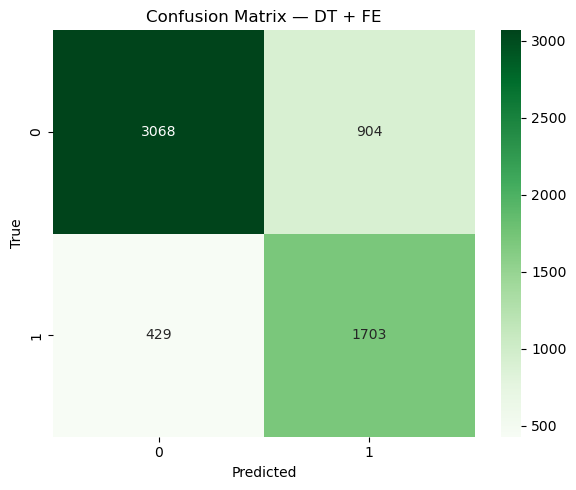

In [94]:
plot_confusion_matrix_simple(y_train, y_pred_dt_fe,
                             title="Confusion Matrix — DT + FE")

Видим, что использование полного набора признаков позволило получить примерно такое же качество, как при удалении некоторых фичей из исходного датасета: вырос precision, но есть снижение на 5 единиц по ключевой метрике recall.

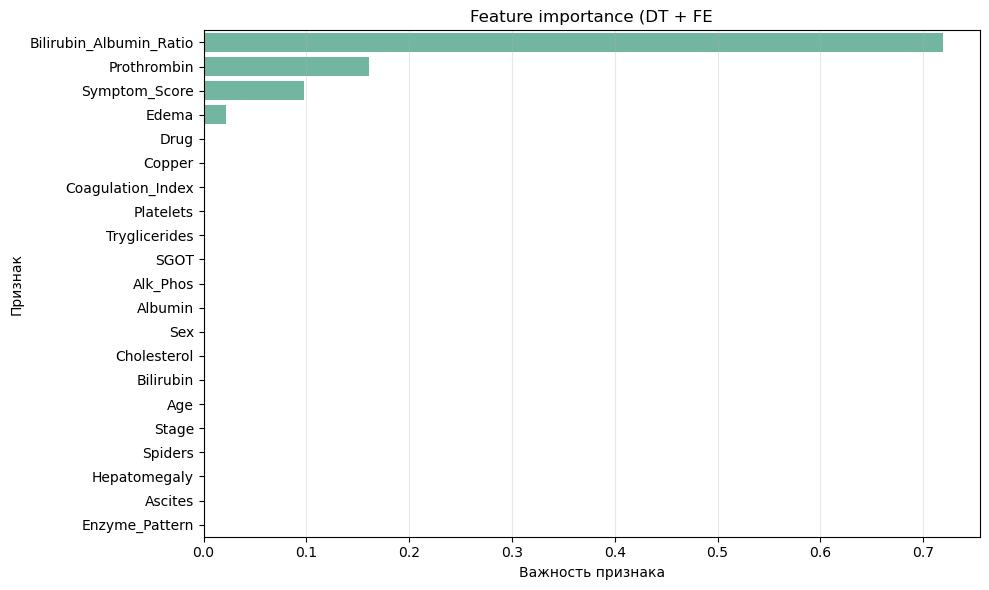

,feature,importance
18,Bilirubin_Albumin_Ratio,0.719451
16,Prothrombin,0.161063
17,Symptom_Score,0.097992
5,Edema,0.021495
0,Drug,0.000000
11,Copper,0.000000
19,Coagulation_Index,0.000000
15,Platelets,0.000000
14,Tryglicerides,0.000000
13,SGOT,0.000000


In [95]:
plot_feature_importances(gs_dt_fe,
                         title="Feature importance (DT + FE")

Попробуем провести эксперимент и удалить часть незначимых признаков. Исключение из датасета избыточных признаков может потенциально улучшить качество модели.

In [96]:
cols_to_drop = ['Drug', 'Age', 'Sex', 'Cholesterol', 'Copper',
                'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Stage']

X_train_new = X_train.drop(cols_to_drop, axis=1).copy()

binary_maps_new = {
    "Ascites": {"N": 0, "Y": 1},
    "Hepatomegaly": {"N": 0, "Y": 1},
    "Spiders": {"N": 0, "Y": 1}
}


processor_dt_fe_new = make_tree_processor(binary_maps=binary_maps_new,
                                       binary_features=list(binary_maps_new.keys()),
                                       multi_category_features=['Edema'])

gs_dt_fe_new = make_tree_gridsearch(preprocessor=processor_dt_fe_new,
                                    use_fe=True,
                                    fe_cols=['Bilirubin_Albumin_Ratio', 'Symptom_Score'])

gs_dt_fe_new.fit(X_train_new, y_train)
print("DT + FE (some features removed):")
print("Best params:", gs_dt_fe_new.best_params_)
print("Best recall:", gs_dt_fe_new.best_score_)

DT + FE (some features removed):
Best params: {'dt__class_weight': None, 'dt__criterion': 'entropy', 'dt__max_depth': 3, 'dt__max_features': 'sqrt', 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2, 'sampler': RandomUnderSampler(random_state=42)}
Best recall: 0.7978592868687535


Дополнительный feature engineering не помог улучшить качество, поэтому в качестве лучшей модели будем использовать версию с исходным набором признаков.

### 3) Лучшая DT модель на тесте

Отрисуем дерево для интерпретируемости, затем обучим лучшую модель на всём train и сделаем прогнозы для теста.

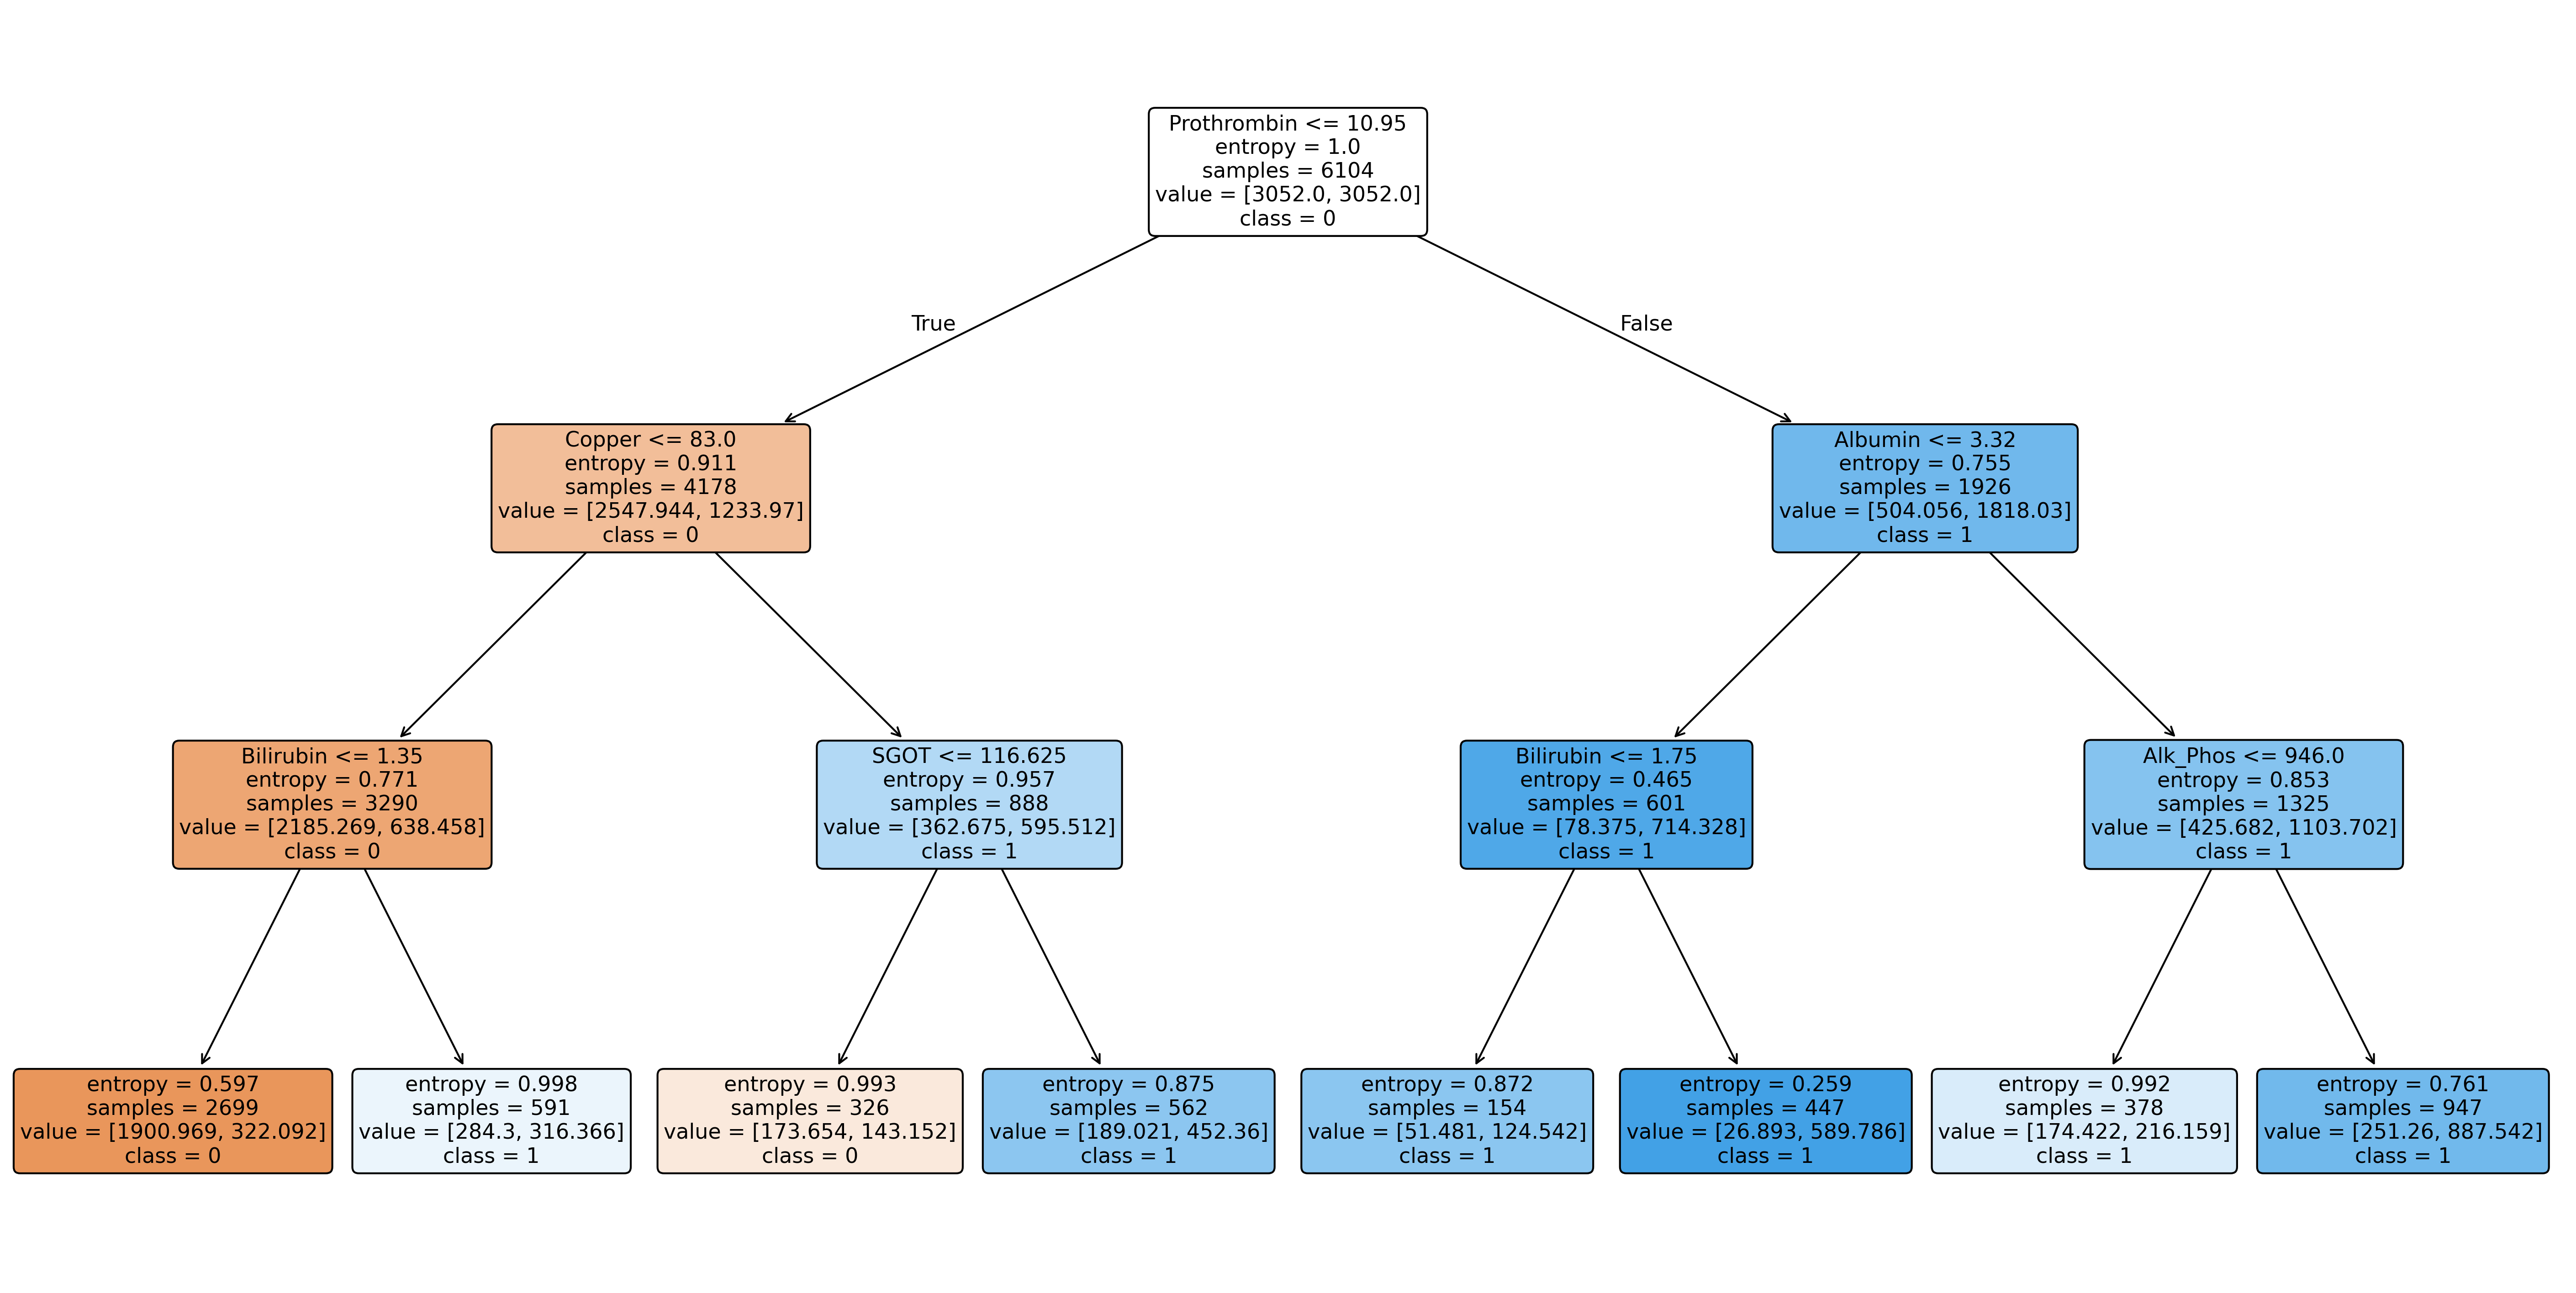

In [97]:
plot_tree_from_estimator(gs_dt)

In [98]:
t0 = perf_counter()
gs_dt.best_estimator_.fit(X_train, y_train)
t1 = perf_counter()
full_fit_dt_time = t1 - t0

print(f"Execution time: {full_fit_dt_time:.4f} seconds")

Execution time: 0.0205 seconds


In [99]:
THRESHOLD_DT = 0.35

t0 = perf_counter()
y_proba_dt_test = gs_dt.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_dt_test = (y_proba_dt_test >= THRESHOLD_DT).astype(int)
t1 = perf_counter()
test_dt_time = t1 - t0

print(f"Execution time: {test_dt_time:.4f} seconds")

Execution time: 0.0070 seconds


In [100]:
print(f"Class report test (DT with threshold = {THRESHOLD_DT}):")
print(classification_report(y_test, y_pred_dt_test))

Class report test (DT with threshold = 0.35):
              precision    recall  f1-score   support

           0       0.91      0.60      0.72       993
           1       0.54      0.88      0.67       533

    accuracy                           0.70      1526
   macro avg       0.72      0.74      0.69      1526
weighted avg       0.78      0.70      0.70      1526



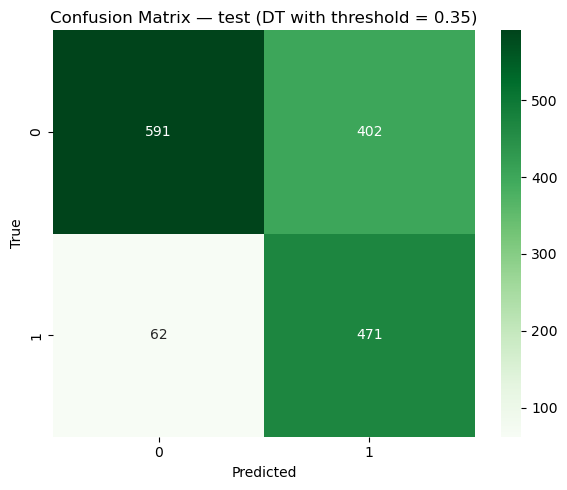

In [101]:
plot_confusion_matrix_simple(y_test, y_pred_dt_test,
                             title=f"Confusion Matrix — test (DT with threshold = {THRESHOLD_DT})")

На тесте выбранная модель (с весами классов, порогом в 0.35 и без доп. признаков) показывает recall класса 1 = 0.88 и precision класса 1 = 0.54, что уступает логистической регрессии (0.89 и 0.58 соответственно), однако при этом дерево решений обладает большей интерпретируемостью. Важнейшие признаки по версии дерева решений: Prothrombin, Copper, Bilirubin, Albumin.

## 5. Применение и оценка случайного леса (RF)

### 1) RF на исходном наборе данных

In [ ]:
processor_rf = make_tree_processor(binary_maps, binary_features, multi_category_features)

study_rf = optuna_cv_search(lambda t: make_rf_pipeline(t, processor_rf, use_fe=False),
                            X_train,
                            y_train,
                            cv=skf,
                            n_trials=RF_TRIALS,
                            scoring="recall"
                           )

In [103]:
print("RF best pipeline:")
print(f"Best params: {study_rf.best_trial.params}")
print(f"Best recall: {study_rf.best_value:.4f}")

RF best pipeline:
Best params: {'sampler': 'under', 'rf_n_estimators': 473, 'rf_max_depth': 20, 'rf_min_samples_split': 7, 'rf_min_samples_leaf': 1, 'rf_max_features': 'sqrt', 'rf_class_weight': 'balanced_subsample', 'rf_max_samples': 0.6095011330566877}
Best recall: 0.8279


In [104]:
rf_pipeline = create_best_pipeline(study_rf, processor_rf, use_fe=False)

t0 = perf_counter()

y_pred_rf = cross_val_predict(rf_pipeline, X_train, y_train, cv=skf, n_jobs=-1) 

t1 = perf_counter()
cross_val_rf_time = t1 - t0

print("RF best estimator:")
print(classification_report(y_train, y_pred_rf))
print(f"Execution time: {cross_val_rf_time:.4f} seconds")

RF best estimator:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      3972
           1       0.73      0.83      0.78      2132

    accuracy                           0.83      6104
   macro avg       0.82      0.83      0.82      6104
weighted avg       0.84      0.83      0.84      6104

Execution time: 3.0194 seconds


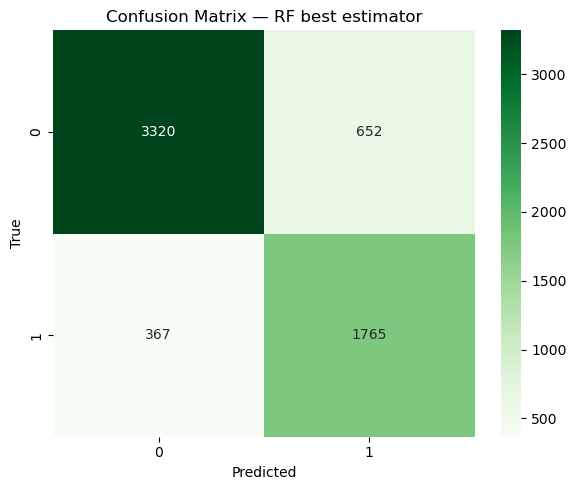

In [105]:
plot_confusion_matrix_simple(y_train, y_pred_rf, title="Confusion Matrix — RF best estimator")

Наилучшее качество по ключевой метрике (recall) демонстрирует модель Random Forest, использующая RandomUnderSampler как метод борьбы с дисбалансом классов:

- recall - 0.83
- precision - 0.73

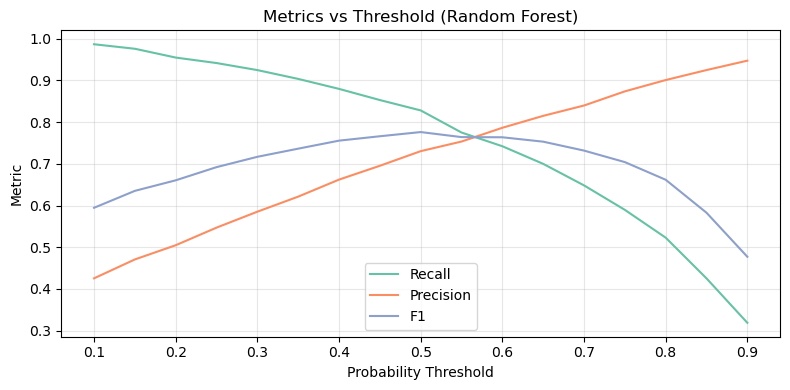

In [106]:
plot_threshold_curves(rf_pipeline, X_train, y_train, cv=skf,
                      title="Metrics vs Threshold (Random Forest)")

При этом видим, что с помощью изменения порога можно поднять recall, пропорционально потеряв в precision

In [107]:
THRESHOLD = 0.35

y_proba_rf = cross_val_predict(rf_pipeline, X_train, y_train, method="predict_proba", cv=skf, n_jobs=-1)[:, 1]
y_pred_rf_thr = (y_proba_rf >= THRESHOLD).astype(int)

print(f"Class report (RF with threshold = {THRESHOLD}):")
print(classification_report(y_train, y_pred_rf_thr))

Class report (RF with threshold = 0.35):
              precision    recall  f1-score   support

           0       0.93      0.70      0.80      3972
           1       0.62      0.90      0.74      2132

    accuracy                           0.77      6104
   macro avg       0.78      0.80      0.77      6104
weighted avg       0.82      0.77      0.78      6104



### 2) RF + Feature Engineering

Попробуем добавить кастомные фичи в признаковое пространство и заново подобрать гиперпараметры

In [ ]:
study_rf_fe = optuna_cv_search(lambda t: make_rf_pipeline(t, processor_rf, use_fe=True),
                               X_train,
                               y_train,
                               cv=skf,
                               n_trials=RF_TRIALS,
                               scoring="recall"
                              )

In [109]:
print("Best pipeline (RF + FE):")
print(f"Best params: {study_rf_fe.best_trial.params}")
print(f"Best recall: {study_rf_fe.best_value:.4f}")

Best pipeline (RF + FE):
Best params: {'sampler': 'under', 'rf_n_estimators': 245, 'rf_max_depth': 20, 'rf_min_samples_split': 4, 'rf_min_samples_leaf': 1, 'rf_max_features': 'log2', 'rf_class_weight': 'balanced', 'rf_max_samples': 0.7722227026480597}
Best recall: 0.8227


In [110]:
rf_pipeline_fe = create_best_pipeline(study_rf_fe, processor_rf, use_fe=True)

y_pred_rf_fe = cross_val_predict(rf_pipeline_fe, X_train, y_train, cv=skf, n_jobs=-1) 

print("RF + FE best estimator:")
print(classification_report(y_train, y_pred_rf_fe))

RF + FE best estimator:
              precision    recall  f1-score   support

           0       0.90      0.83      0.86      3972
           1       0.73      0.82      0.77      2132

    accuracy                           0.83      6104
   macro avg       0.81      0.83      0.82      6104
weighted avg       0.84      0.83      0.83      6104



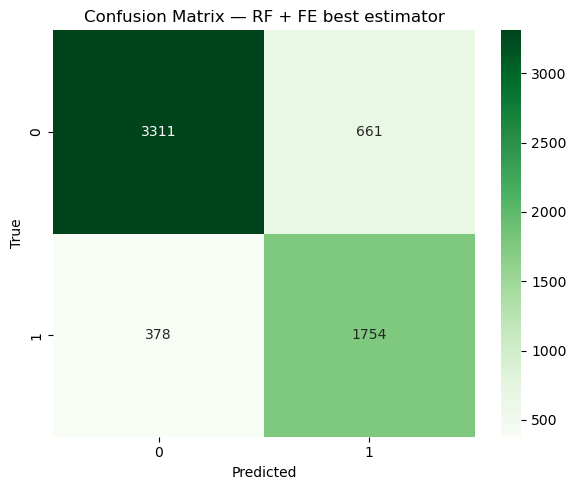

In [111]:
plot_confusion_matrix_simple(y_train, y_pred_rf_fe,
                             title="Confusion Matrix — RF + FE best estimator")

Модель с дополнительными признаками показала качество ниже: по матрице ошибок видно, что мы незначительно потеряли и в precision, и в recall.

Оценим важность признаков по версиям RF и SHAP. Исключение из датасета избыточных признаков может потенциально улучшить качество модели.

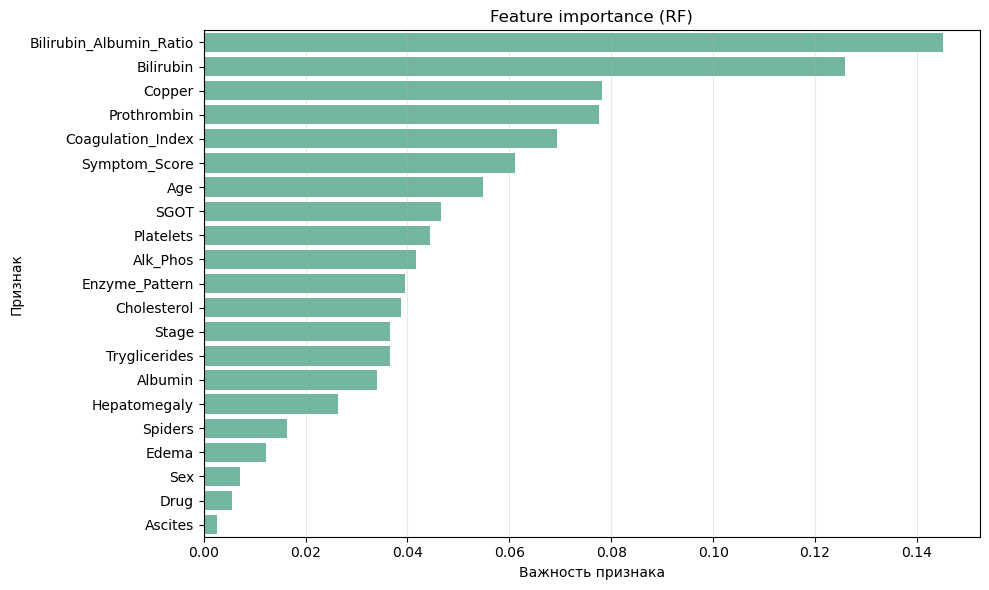

,feature,importance
18,Bilirubin_Albumin_Ratio,0.145103
8,Bilirubin,0.125885
11,Copper,0.078249
16,Prothrombin,0.077541
19,Coagulation_Index,0.069317
17,Symptom_Score,0.061037
7,Age,0.054783
13,SGOT,0.046542
15,Platelets,0.044473
12,Alk_Phos,0.041604


In [112]:
rf_pipeline_fe.fit(X_train, y_train)

plot_feature_importances(rf_pipeline_fe, model_step_name="rf", title="Feature importance (RF)")

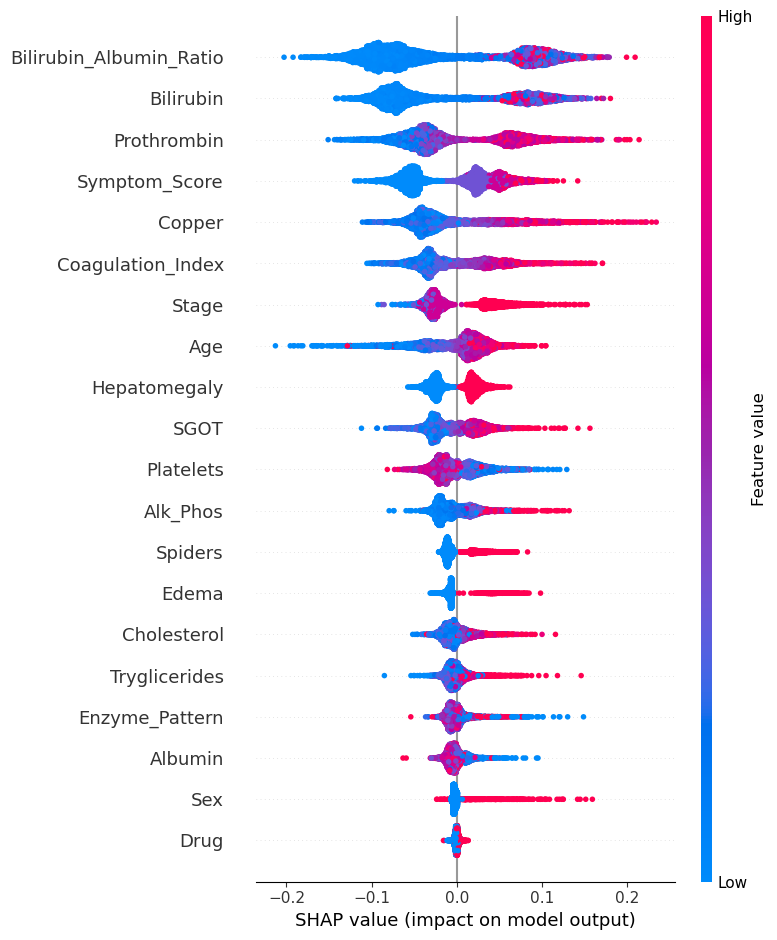

<Figure size 640x480 with 0 Axes>

In [113]:
plot_shap(rf_pipeline_fe, X_train)

Согласно встроенной в Random Forest оценке важности признаков, большинство категориальных признаков вносят низкий вклад в предсказания модели. Такие признаки, как Sex, Drug и Ascites, демонстрируют практически нулевую важность и могут рассматриваться как кандидаты на исключение из признакового пространства. Данный вывод также подтверждается анализом SHAP.

Признаки Edema и Stage также имеют относительно низкую важность согласно встроенной оценке Random Forest, однако в анализе SHAP занимают более высокие позиции.

Три из четырёх кастомных признаков демонстрируют высокий вклад в качество модели. При этом признак Enzyme_Pattern оказывает сравнительно меньшее влияние: в анализе SHAP его значимость ниже, чем в нативной оценке важности признаков Random Forest.

Следует также учитывать, что при исключении категориальных признаков становится невозможным формирование признака Symptom_Score, который, согласно обеим метрикам, обладает существенной предсказательной значимостью.

In [ ]:
binary_maps_new = {'Hepatomegaly': {'N': 0, 'Y': 1}}
binary_features_new = list(binary_maps_new.keys())
multi_category_features_new = []
processor_rf_new = make_tree_processor(binary_maps_new, binary_features_new, multi_category_features_new) 

fe_cols = ['Bilirubin_Albumin_Ratio', 'Coagulation_Index', 'Enzyme_Pattern']

X_train_new = X_train.drop(['Ascites', 'Drug', 'Sex', 'Edema', 'Spiders', 'Stage'], axis=1).copy()

study_rf_fe_new = optuna_cv_search(lambda t: make_rf_pipeline(t, processor_rf_new, use_fe=True, fe_cols=fe_cols),
                               X_train_new,
                               y_train,
                               cv=skf,
                               n_trials=RF_TRIALS,
                               scoring="recall"
                              )

In [115]:
print("Best pipeline (RF + FE, some features removed):")
print(f"Best params: {study_rf_fe_new.best_trial.params}")
print(f"Best recall: {study_rf_fe_new.best_value:.4f}")

Best pipeline (RF + FE, some features removed):
Best params: {'sampler': 'under', 'rf_n_estimators': 478, 'rf_max_depth': 15, 'rf_min_samples_split': 14, 'rf_min_samples_leaf': 1, 'rf_max_features': None, 'rf_class_weight': None, 'rf_max_samples': 0.7494870753332075}
Best recall: 0.8105


In [116]:
rf_pipeline_fe_new = create_best_pipeline(study_rf_fe_new, processor_rf_new, use_fe=True, fe_cols=fe_cols)

y_pred_rf_fe_new = cross_val_predict(rf_pipeline_fe_new, X_train_new, y_train, cv=skf, n_jobs=-1) 

print("RF + FE best estimator (some features removed):")
print(classification_report(y_train, y_pred_rf_fe_new))

RF + FE best estimator (some features removed):
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      3972
           1       0.72      0.81      0.76      2132

    accuracy                           0.82      6104
   macro avg       0.81      0.82      0.81      6104
weighted avg       0.83      0.82      0.83      6104



Видим, что удаление части признаков не привело к улучшению метрик: мы потеряли и в recall, и в precision. В качестве лучшей модели будем использовать модель с исходным набором признаков и выбранным порогом.

### 3) Лучшая RF модель на тесте

Обучим лучший пайплайн на полном train и оценим важность признаков по версиям RF и SHAP, чтобы сделать модель интерпретируемой.

In [117]:
best_rf_pipeline = create_best_pipeline(study_rf, processor_rf, use_fe=False)

In [118]:
t0 = perf_counter()
best_rf_pipeline.fit(X_train, y_train)
t1 = perf_counter()
full_fit_rf_time = t1 - t0

print(f"Execution time: {full_fit_rf_time:.4f} seconds")

Execution time: 1.5311 seconds


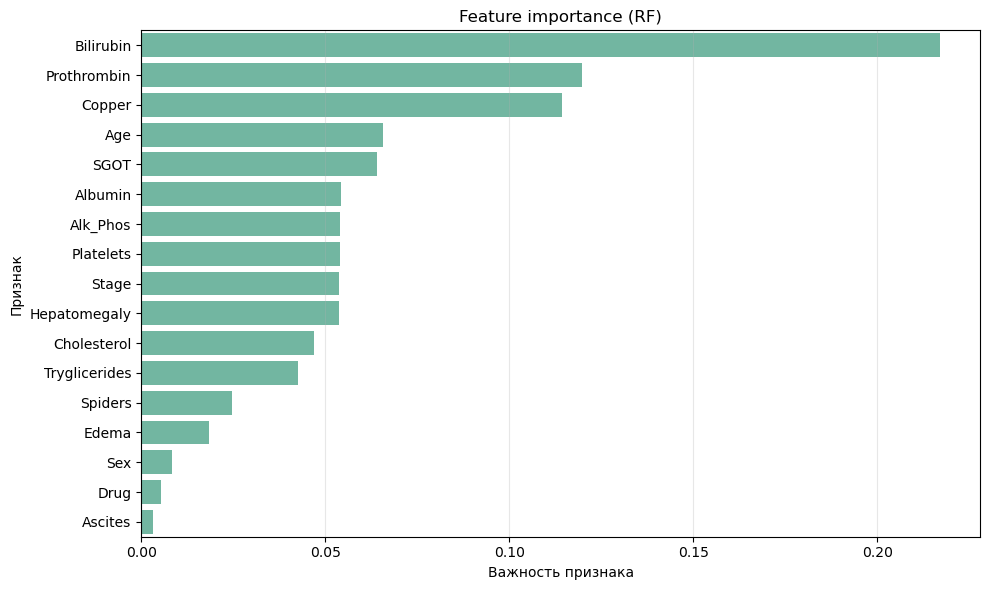

,feature,importance
8,Bilirubin,0.217042
16,Prothrombin,0.119734
11,Copper,0.114322
7,Age,0.065778
13,SGOT,0.064076
10,Albumin,0.054245
12,Alk_Phos,0.053955
15,Platelets,0.053910
6,Stage,0.053782
3,Hepatomegaly,0.053589


In [119]:
plot_feature_importances(best_rf_pipeline, model_step_name="rf", title="Feature importance (RF)")

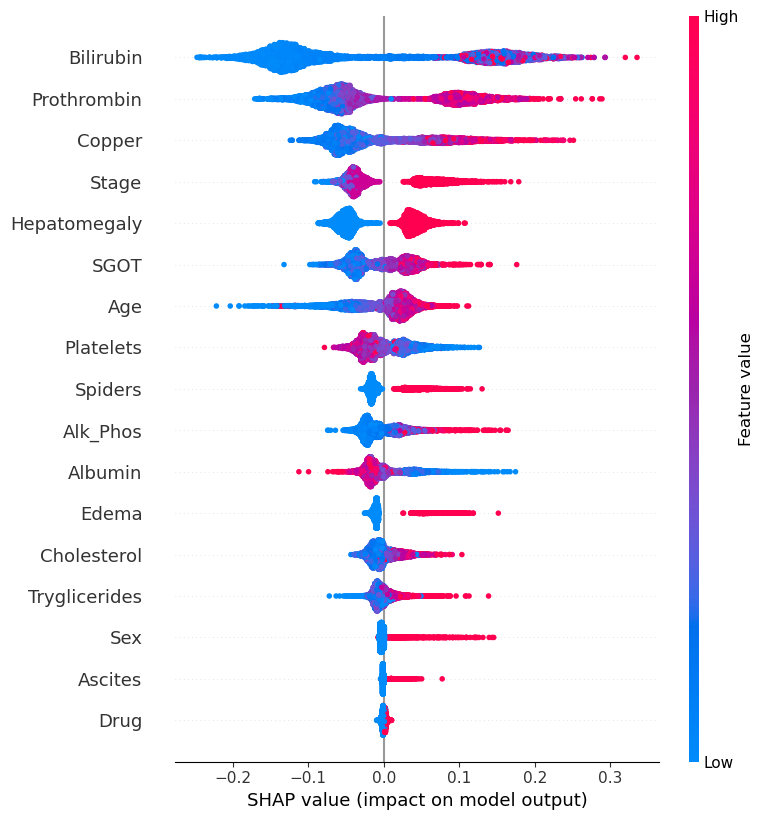

<Figure size 640x480 with 0 Axes>

In [120]:
plot_shap(best_rf_pipeline, X_train)

По SHAP-графику видно, что наиболее важными признаками для модели являются биохимические показатели: Bilirubin, Prothrombin и Copper. Точки красного цвета (высокие значения признака) у Bilirubin, Prothrombin и Copper в основном находятся справа, то есть большие значения этих показателей обычно увеличивают вероятность неблагоприятного исхода (класс 1). Для Platelets и Albumin картина обратная: низкие значения чаще связаны с неблагоприятным течением болезни. Среди категориальных признаков наибольший вклад вносят Stage и Hepatomegaly. Остальные признаки (например, Cholesterol, Tryglicerides, Sex, Ascites, Drug) влияют заметно слабее - их точки в основном сгруппированы ближе к нулю.

In [121]:
THRESHOLD_RF = 0.35

t0 = perf_counter()
y_proba_rf_test = best_rf_pipeline.predict_proba(X_test)[:, 1]
y_pred_rf_test = (y_proba_rf_test >= THRESHOLD_RF).astype(int)
t1 = perf_counter()
test_rf_time = t1 - t0

print(f"Execution time: {test_rf_time:.4f} seconds")

Execution time: 0.1004 seconds


In [122]:
print(f"Test RF best estimator (threshold={THRESHOLD_RF}):")
print(classification_report(y_test, y_pred_rf_test))

Test RF best estimator (threshold=0.35):
              precision    recall  f1-score   support

           0       0.93      0.68      0.78       993
           1       0.60      0.91      0.72       533

    accuracy                           0.76      1526
   macro avg       0.77      0.79      0.75      1526
weighted avg       0.82      0.76      0.76      1526



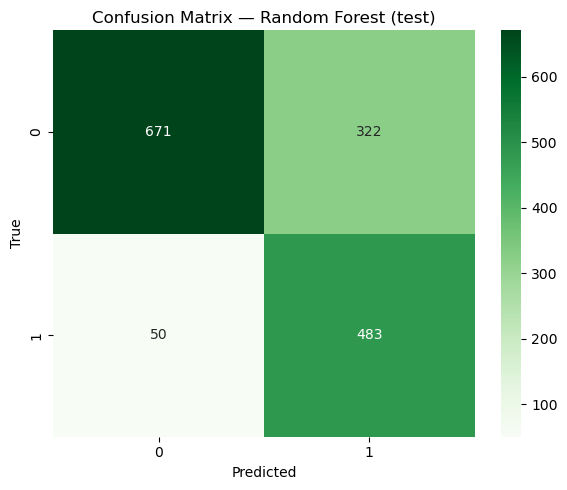

In [123]:
plot_confusion_matrix_simple(y_test, y_pred_rf_test,
                             title="Confusion Matrix — Random Forest (test)")

На тесте выбранная модель демонстрирует recall класса 1 = 0.91 и precision класса 1 = 0.6. На данный момент это лучший результат в сравнении с логистической регрессией (0.89 и 0.58 соответственно) и деревом решений (0.88 и 0.54 соответственно).

## 6. Применение и оценка CatBoost (CB)

### 1) CB на исходном наборе данных

In [ ]:
study_cb = optuna_cv_search_cb(lambda t: make_cb_pipeline(t),
                               X_train,
                               y_train,
                               cv=skf,
                               n_trials=N_TRIALS_CB,
                               cat_features_list=cat_features,
                               use_fe=False
                              )

In [125]:
print("CatBoost best pipeline:")
print(f"Best params: {study_cb.best_trial.params}")
print(f"Best recall: {study_cb.best_value:.4f}")

CatBoost best pipeline:
Best params: {'sampler': 'under', 'cb_learning_rate': 0.13123395014050226, 'cb_depth': 6, 'cb_l2_leaf_reg': 46.375677778122295, 'cb_random_strength': 0.024303242348848293, 'cb_bagging_temperature': 0.224796707431773, 'cb_min_data_in_leaf': 3, 'cb_subsample': 0.8277274325652207, 'cb_class_weights': 'none'}
Best recall: 0.8213


In [126]:
cb_pipeline, cb_sampler_name, cb_sampler = create_best_pipeline_cb(study_cb)


t0 = perf_counter()

y_proba_cb_oof = cv_predict_proba_cb(cb_pipeline,
                                  cb_sampler,
                                  X_train,
                                  y_train,
                                  cv=skf,
                                  cat_features_list=cat_features,
                                  use_fe=False)

t1 = perf_counter()
cross_val_cb_time = t1 - t0

y_pred_cb = (y_proba_cb_oof >= 0.5).astype(int)

print("CatBoost best estimator:")
print(classification_report(y_train, y_pred_cb))
print(f"Execution time: {cross_val_cb_time:.4f} seconds")

CatBoost best estimator:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      3972
           1       0.74      0.82      0.78      2132

    accuracy                           0.83      6104
   macro avg       0.82      0.83      0.82      6104
weighted avg       0.84      0.83      0.84      6104

Execution time: 33.1248 seconds


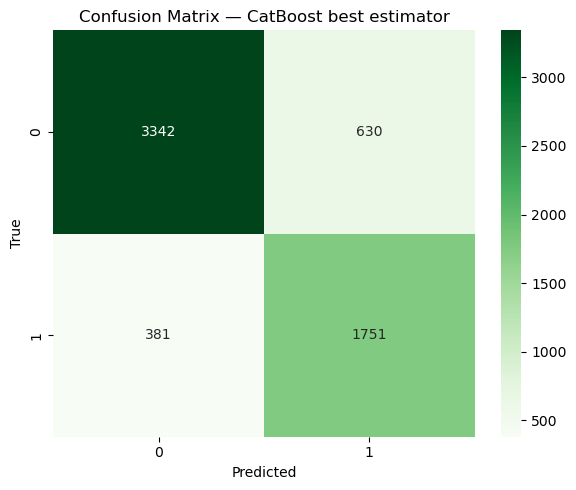

In [127]:
plot_confusion_matrix_simple(y_train, y_pred_cb, title="Confusion Matrix — CatBoost best estimator")

Наилучшее качество по ключевой метрике (recall) демонстрирует модель CatBoost, использующая RandomUnderSampler как метод борьбы с дисбалансом классов, с умеренной глубиной деревьев и сильной регуляризацией:

- recall - 0.82
- precision - 0.74

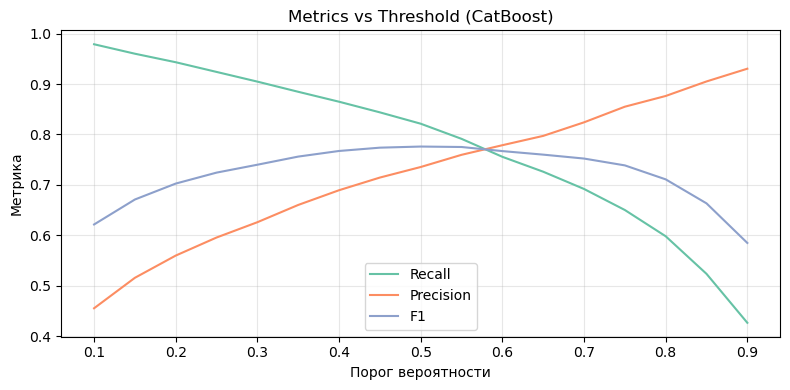

In [128]:
plot_threshold_curves_cb(cb_pipeline,
                         cb_sampler,
                         X_train,
                         y_train,
                         cv=skf,
                         title="Metrics vs Threshold (CatBoost)",
                         cat_features_list=cat_features,
                         use_fe=False)

In [129]:
THRESHOLD = 0.3

y_proba_cb = cv_predict_proba_cb(cb_pipeline,
                              cb_sampler,
                              X_train,
                              y_train,
                              cv=skf,
                              cat_features_list=cat_features,
                              use_fe=False)

y_pred_cb_thr = (y_proba_cb >= THRESHOLD).astype(int)

print(f"Class report (CB with threshold = {THRESHOLD}):")
print(classification_report(y_train, y_pred_cb_thr))

Class report (CB with threshold = 0.3):
              precision    recall  f1-score   support

           0       0.93      0.71      0.81      3972
           1       0.63      0.90      0.74      2132

    accuracy                           0.78      6104
   macro avg       0.78      0.81      0.77      6104
weighted avg       0.83      0.78      0.78      6104



### 2) CB + Feature Engineering

Попробуем добавить кастомные фичи в признаковое пространство и заново подобрать гиперпараметры. Активируем флаг use_fe, параметр fe_cols можно не передавать - по умолчанию будут сгенерированы все 4 новых признака.

In [ ]:
study_cb_fe = optuna_cv_search_cb(lambda t: make_cb_pipeline(t),
                                  X_train,
                                  y_train,
                                  cv=skf,
                                  n_trials=N_TRIALS_CB,
                                  cat_features_list=cat_features,
                                  use_fe=True
                                 )

In [131]:
print("Best pipeline (CatBoost + FE):")
print(f"Best params: {study_cb_fe.best_trial.params}")
print(f"Best recall: {study_cb_fe.best_value:.4f}")

Best pipeline (CatBoost + FE):
Best params: {'sampler': 'under', 'cb_learning_rate': 0.1907232272999395, 'cb_depth': 8, 'cb_l2_leaf_reg': 45.85500709482166, 'cb_random_strength': 8.323144279644582, 'cb_bagging_temperature': 0.6721975950733878, 'cb_min_data_in_leaf': 20, 'cb_subsample': 0.5074900241609404, 'cb_class_weights': 'balanced'}
Best recall: 0.8194


In [132]:
cb_pipeline_fe, cb_sampler_fe_name, cb_sampler_fe = create_best_pipeline_cb(study_cb_fe)

y_proba_cb_fe_oof = cv_predict_proba_cb(cb_pipeline_fe,
                                     cb_sampler_fe,
                                     X_train,
                                     y_train,
                                     cv=skf,
                                     cat_features_list=cat_features,
                                     use_fe=True)

y_pred_cb_fe = (y_proba_cb_fe_oof >= 0.5).astype(int)

print("CatBoost + FE best estimator:")
print(classification_report(y_train, y_pred_cb_fe))

CatBoost + FE best estimator:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      3972
           1       0.73      0.82      0.77      2132

    accuracy                           0.83      6104
   macro avg       0.81      0.83      0.82      6104
weighted avg       0.84      0.83      0.83      6104



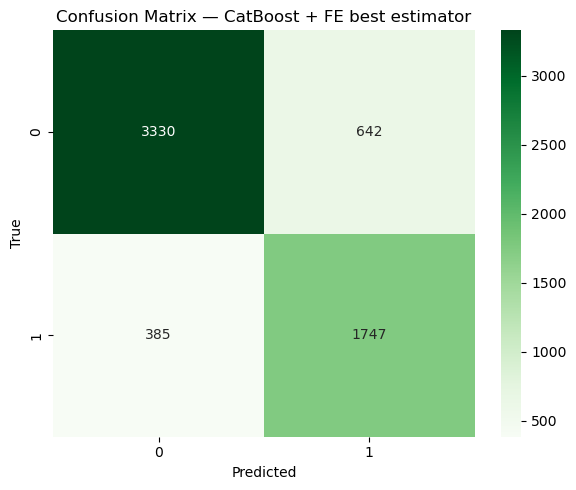

In [133]:
plot_confusion_matrix_simple(y_train, y_pred_cb_fe,
                             title="Confusion Matrix — CatBoost + FE best estimator")

Видим незначительную потерю в качестве по сравнению с исходным набором признаков: precision снизился на единицу, отмечаются малые потери в recall.

Оценим важность признаков по версиям CatBoost и SHAP. Исключение из датасета избыточных признаков может потенциально улучшить качество модели.

Обучим модель на полном train (с early stopping на небольшом holdout) и посмотрим важность признаков.

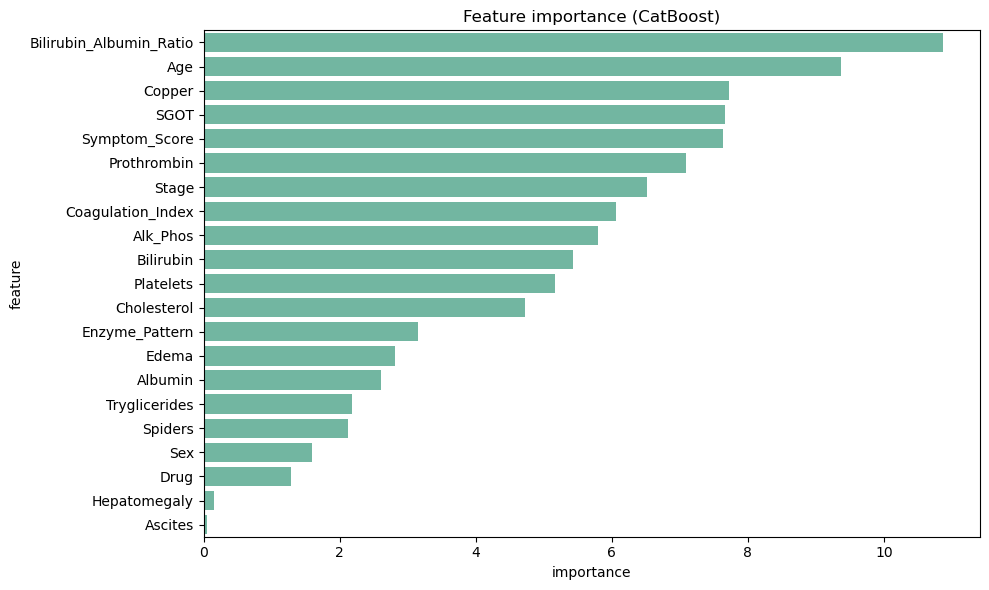

In [134]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

X_tr_fe = add_fe_features(X_tr)
X_val_fe = add_fe_features(X_val)

cb_pipeline_fe.fit(
    X_tr_fe, y_tr,
    cb__cat_features=cat_features,
    cb__eval_set=(X_val_fe, y_val),
    cb__early_stopping_rounds=10,
    cb__use_best_model=True,
    cb__verbose=False
)

plot_feature_importances_cb(cb_pipeline_fe,
                            X_train,
                            title="Feature importance (CatBoost)",
                            cat_features_list=cat_features,
                            use_fe=True)

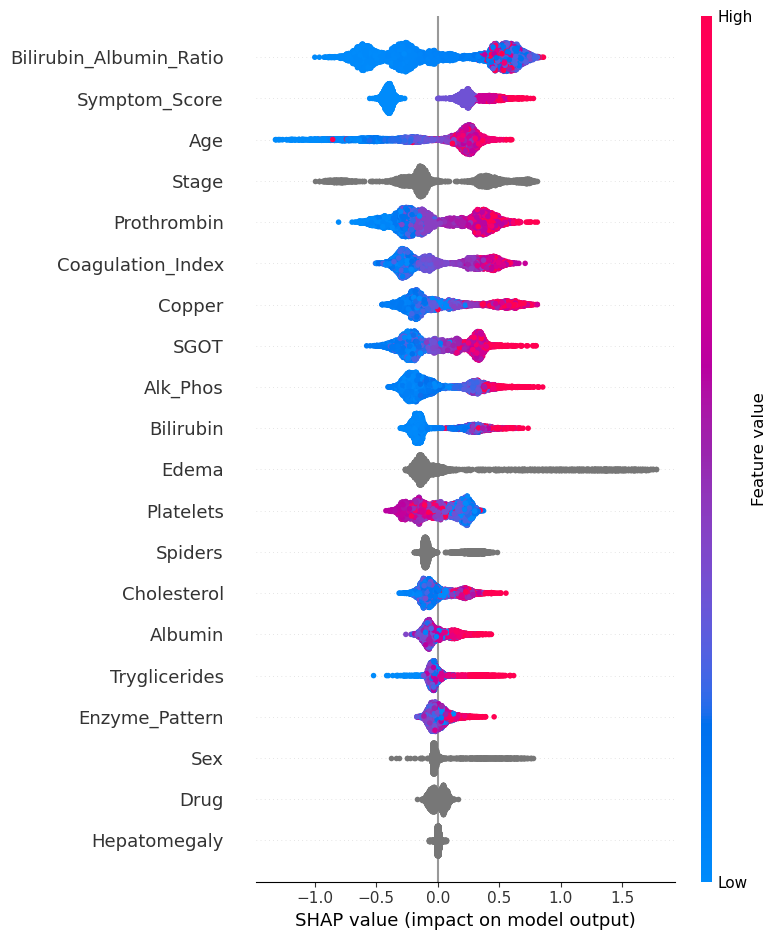

<Figure size 640x480 with 0 Axes>

In [135]:
plot_shap_cb(cb_pipeline_fe,
             X_train,
             use_fe=True,
             cat_features_list=cat_features)

Согласно встроенной в CatBoost оценке важности признаков, большинство бинарных категориальных признаков вносят низкий вклад в предсказания модели. Такие признаки, как Ascites и Hepatomegaly, демонстрируют практически нулевую важность и могут рассматриваться как кандидаты на исключение из признакового пространства. Данный вывод также подтверждается анализом SHAP, согласно которого в список низкозначимых фичей можно также добавить Sex и Drug.

Признак Stage также имеет высокую важность согласно обеим оценкам, поэтому его рекомендуется оставить.

Три из четырёх кастомных признаков демонстрируют высокий вклад в качество модели. При этом признак Enzyme_Pattern оказывает сравнительно меньшее влияние: в анализе SHAP его значимость ниже, чем в нативной оценке важности признаков CatBoost.

Следует также учитывать, что при исключении бинарных категориальных признаков становится невозможным формирование признака Symptom_Score, который, согласно обеим метрикам, обладает существенной предсказательной значимостью.

Попробуем исключить из признакового пространства следующие фичи: 'Ascites', 'Drug', 'Sex', 'Spiders', 'Hepatomegaly'.

In [ ]:
fe_cols_new = ['Bilirubin_Albumin_Ratio', 'Coagulation_Index', 'Enzyme_Pattern']

X_train_new = X_train.drop(['Ascites', 'Drug', 'Sex', 'Spiders', 'Hepatomegaly'], axis=1).copy()

cat_features_new = [c for c in cat_features if c in X_train_new.columns]

study_cb_fe_new = optuna_cv_search_cb(lambda t: make_cb_pipeline(t),
                                      X_train_new,
                                      y_train,
                                      cv=skf,
                                      n_trials=N_TRIALS_CB,
                                      cat_features_list=cat_features_new,
                                      use_fe=True,
                                      fe_cols=fe_cols_new
                                     )

In [137]:
print("Best pipeline (CatBoost + FE, some features removed):")
print(f"Best params: {study_cb_fe_new.best_trial.params}")
print(f"Best recall: {study_cb_fe_new.best_value:.4f}")

Best pipeline (CatBoost + FE, some features removed):
Best params: {'sampler': 'under', 'cb_learning_rate': 0.04043542923059311, 'cb_depth': 5, 'cb_l2_leaf_reg': 0.08406502411628909, 'cb_random_strength': 0.4788620221684964, 'cb_bagging_temperature': 0.1528255073895809, 'cb_min_data_in_leaf': 26, 'cb_subsample': 0.9110726133763113, 'cb_class_weights': 'balanced'}
Best recall: 0.8114


In [138]:
cb_pipeline_fe_new, cb_sampler_fe_new_name, cb_sampler_fe_new = create_best_pipeline_cb(study_cb_fe_new)

y_proba_cb_fe_new_oof = cv_predict_proba_cb(cb_pipeline_fe_new,
                                         cb_sampler_fe_new,
                                         X_train_new,
                                         y_train,
                                         cv=skf,
                                         cat_features_list=cat_features_new,
                                         use_fe=True,
                                         fe_cols=fe_cols_new)

y_pred_cb_fe_new = (y_proba_cb_fe_new_oof >= 0.5).astype(int)

print("CatBoost + FE best estimator (some features removed):")
print(classification_report(y_train, y_pred_cb_fe_new))

CatBoost + FE best estimator (some features removed):
              precision    recall  f1-score   support

           0       0.89      0.84      0.87      3972
           1       0.73      0.81      0.77      2132

    accuracy                           0.83      6104
   macro avg       0.81      0.83      0.82      6104
weighted avg       0.84      0.83      0.83      6104



Видим, что удаление части признаков не привело к улучшению метрик: мы потеряли и в recall, и в precision. В качестве лучшей модели будем использовать модель с исходным набором признаков и выбранным порогом.

### 3) Лучшая CB модель на тесте

Обучим лучший пайплайн на полном train и оценим важность признаков по версиям CatBoost и SHAP, чтобы сделать модель интерпретируемой.

In [139]:
best_cb_pipeline, best_cb_sampler_name, best_cb_sampler = create_best_pipeline_cb(study_cb)

Для финального обучения используем early stopping на внутреннем holdout (всего 10% данных, чтобы оставить как можно больше объектов для обучения)

In [140]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=RANDOM_STATE
)

if best_cb_sampler != "passthrough":
    X_tr_rs, y_tr_rs = apply_sampler(best_cb_sampler, X_tr, y_tr)
else:
    X_tr_rs, y_tr_rs = X_tr, y_tr

t0 = perf_counter()
    
best_cb_pipeline.fit(
    X_tr_rs, y_tr_rs,
    cb__cat_features=cat_features,
    cb__eval_set=(X_val, y_val),
    cb__early_stopping_rounds=10,
    cb__use_best_model=True,
    cb__verbose=False
)

t1 = perf_counter()
full_fit_cb_time = t1 - t0

print(f"Execution time: {full_fit_cb_time:.4f} seconds")

Execution time: 3.3245 seconds


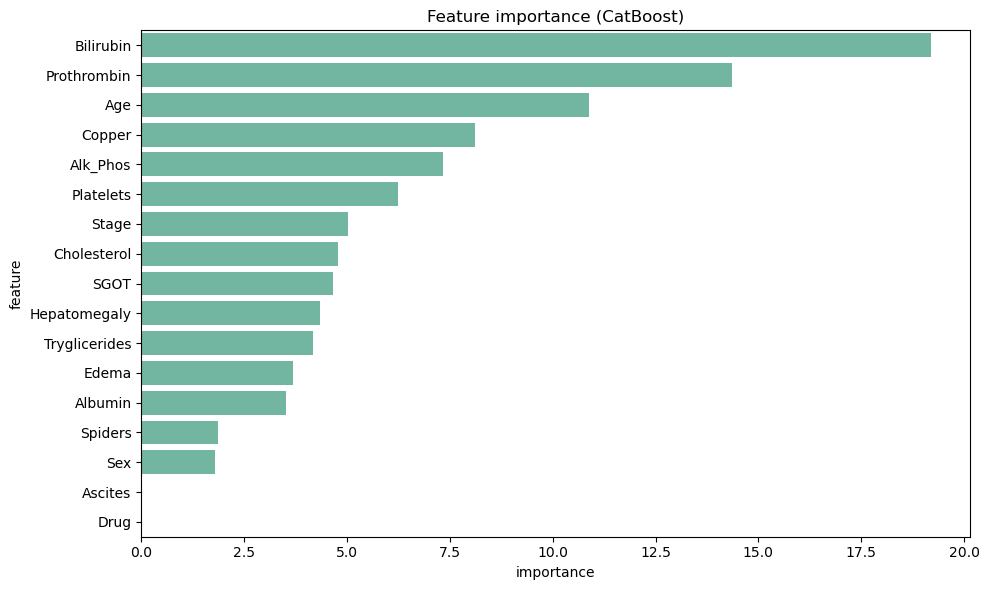

In [141]:
plot_feature_importances_cb(best_cb_pipeline, X_train, title="Feature importance (CatBoost)",
                            use_fe=False, cat_features_list=cat_features)

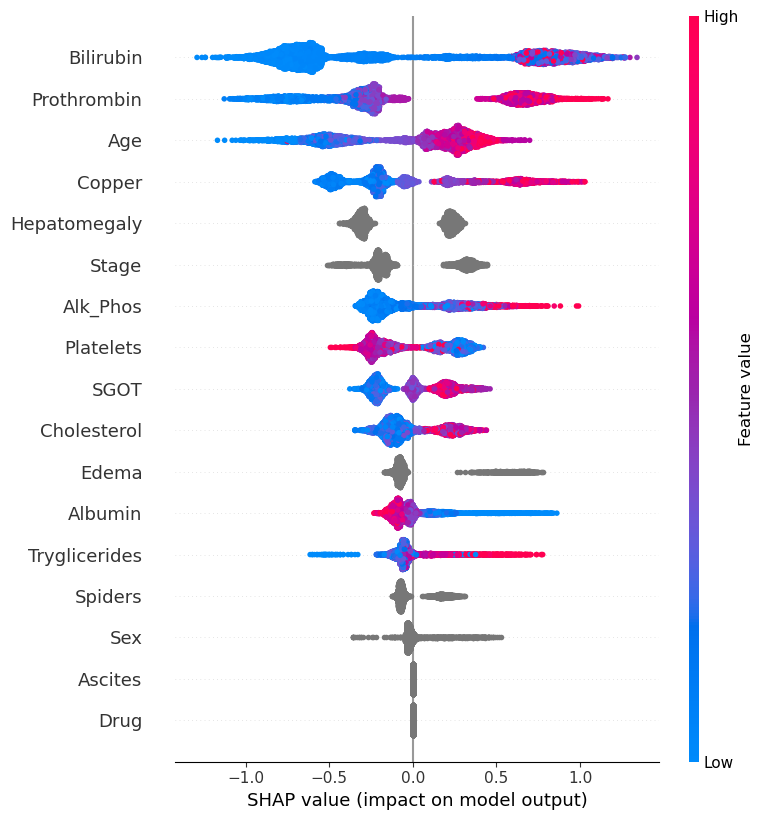

<Figure size 640x480 with 0 Axes>

In [142]:
plot_shap_cb(best_cb_pipeline, X_train, use_fe=False, cat_features_list=cat_features)

По SHAP-графику видно, что наиболее важными признаками для модели являются биохимические показатели: Bilirubin, Prothrombin и Copper. Точки красного цвета (высокие значения признака) у Bilirubin, Prothrombin и Copper в основном находятся справа, то есть большие значения этих показателей обычно увеличивают вероятность неблагоприятного исхода (класс 1). Для Platelets и Albumin картина обратная: низкие значения чаще связаны с неблагоприятным течением болезни. Среди категориальных признаков наибольший вклад вносят Stage и Hepatomegaly. Остальные признаки (например, Ascites и Drug) влияют заметно слабее - их точки в основном сгруппированы ближе к нулю.

In [143]:
THRESHOLD_CB = 0.3

t0 = perf_counter()
y_proba_cb_test = best_cb_pipeline.predict_proba(X_test)[:, 1]
y_pred_cb_test = (y_proba_cb_test >= THRESHOLD_CB).astype(int)
t1 = perf_counter()
test_cb_time = t1 - t0

print(f"Execution time: {test_cb_time:.4f} seconds")

Execution time: 0.0074 seconds


In [144]:
print(f"Test CatBoost best estimator (threshold={THRESHOLD_CB}):")
print(classification_report(y_test, y_pred_cb_test))

Test CatBoost best estimator (threshold=0.3):
              precision    recall  f1-score   support

           0       0.94      0.69      0.79       993
           1       0.61      0.91      0.73       533

    accuracy                           0.77      1526
   macro avg       0.77      0.80      0.76      1526
weighted avg       0.82      0.77      0.77      1526



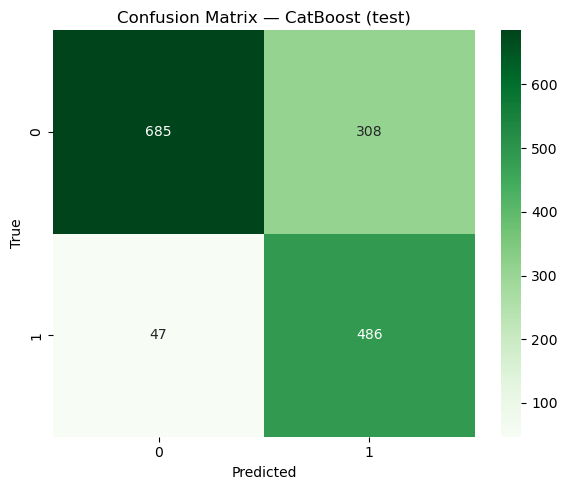

In [145]:
plot_confusion_matrix_simple(y_test, y_pred_cb_test,
                             title="Confusion Matrix — CatBoost (test)")

На тесте выбранная модель демонстрирует recall класса 1 = 0.91 и precision класса 1 = 0.61. На данный момент это лучший результат в сравнении со случайным лесом (0.91 и 0.6 соответственно), логистической регрессией (0.89 и 0.58 соответственно) и деревом решений (0.88 и 0.54 соответственно).

Объединим метрики всех моделей на тесте в одну таблицу для удобного вывода результатов:

In [146]:
def metrics_row(y_true, y_pred, pos_label=1):
    row = {
        "precision_pos": precision_score(y_true, y_pred, pos_label=pos_label),
        "recall_pos": recall_score(y_true, y_pred, pos_label=pos_label),
        "f1_pos": f1_score(y_true, y_pred, pos_label=pos_label),
    }

    return row

preds = {
    "LR baseline": {"y_pred": y_pred_lr_baseline_test},
    "Logistic Regression": {"y_pred": y_pred_lr_test},
    "Decision Tree": {"y_pred": y_pred_dt_test},
    "Random Forest": {"y_pred": y_pred_rf_test},
    "CatBoost": {"y_pred": y_pred_cb_test}
}

rows = []
for model_name, out in preds.items():
    r = metrics_row(y_test, out["y_pred"])
    r["model"] = model_name
    rows.append(r)

df_metrics = pd.DataFrame(rows).set_index("model").sort_values("recall_pos", ascending=False)
df_metrics_display = df_metrics.round(3)

Сделаем то же самое для времени выполнения:

In [147]:
df_times = pd.DataFrame({
    "model": ["LR baseline", "Logistic Regression", "Decision Tree", "Random Forest", "Catboost"],
    "cross_val": [cross_val_lr_baseline_time, cross_val_lr_fe_new_time, cross_val_dt_time, cross_val_rf_time, cross_val_cb_time],
    "full_fit": [full_fit_lr_baseline_time, full_fit_lr_fe_new_time, full_fit_dt_time, full_fit_rf_time, full_fit_cb_time],
    "test": [test_lr_baseline_time, test_lr_fe_new_time, test_dt_time, test_rf_time, test_cb_time]
})

df_times["total"] = df_times[["cross_val", "full_fit", "test"]].sum(axis=1)

df_times.sort_values("total", ascending=True, inplace=True)

## 7. Результаты ML-моделирования

В рамках ML-моделирования была проведена сравнительная оценка качества **пяти различных моделей**:

1. Бейслайн  
2. Логистическая регрессия (LR)  
3. Дерево решений (DT)  
4. Случайный лес (RF)  
5. CatBoost (CB)

В качестве **бейслайна** была выбрана логистическая регрессия с параметрами по умолчанию и предобработкой в виде логарифмирования и стандартизации числовых признаков, а также one-hot-энкодинга мультикатегориальных признаков.

Для всех остальных моделей проводилась **оптимизация**, включающая:

- поиск оптимальных гиперпараметров;
- выбор метода коррекции дисбаланса классов;
- подбор порога для принятия решения об отнесении объекта к классу 1;
- оценку важности признаков для предсказательной способности модели;
- feature engineering;
- feature selection.

Для всех моделей оптимизация выполнялась по ключевой метрике **recall** с целью минимизации числа ложноотрицательных ошибок (пропуска тяжёлых пациентов) с использованием 5-фолдовой стратифицированной кросс-валидации.

Качество моделей оценивалось с использованием метрик **recall** и **precision**, получаемых с помощью `classification_report`, а также матрицы ошибок. Финальная оценка качества проводилась на отложенной тестовой выборке.

---

### Логистическая регрессия (LR)

Для логистической регрессии поиск гиперпараметров осуществлялся с помощью метода *grid search*. В качестве гиперпараметров также подбирались стратегия обработки числовых признаков и метод коррекции дисбаланса классов.

Наилучшие результаты показала логистическая регрессия с **elasticnet-регуляризацией**, обученная со следующими настройками:

- стратегия препроцессинга: `log_clip_standard`
- балансировка классов: SMOTE
- `solver = saga`
- `C = 0.3`
- `l1_ratio = 0.75`
- порог классификации = 0.3

Оценка важности признаков проводилась на основе величины коэффициентов модели. Оптимальное качество было достигнуто на сокращённом наборе признаков с использованием полиномиальных признаков **Bilirubin** и **Copper**, а также кастомных фичей **Coagulation_Index** и **Enzyme_Pattern**.

---

### Дерево решений (DT)

Для дерева решений поиск гиперпараметров выполнялся с помощью метода *grid search*. Для обработки категориальных признаков использовалась бинарная кодировка (0/1) для бинарных признаков и `OrdinalEncoder` для мультикатегориальных признаков. Также подбирался метод коррекции дисбаланса классов.

Наилучшие результаты показало дерево решений со следующими параметрами:

- балансировка классов: веса классов
- `criterion = entropy`
- `max_depth = 3`
- `max_features = sqrt`
- `min_samples_leaf = 1`
- `min_samples_split = 2`
- порог классификации = 0.35

Оценка важности признаков проводилась с использованием встроенного механизма дерева решений. Были протестированы модели с исходным, расширенным и сокращённым наборами признаков. Оптимальное качество было достигнуто на полном наборе признаков.

---

### Случайный лес (RF)

Для случайного леса подбор гиперпараметров осуществлялся с помощью библиотеки *Optuna*. Для обработки категориальных признаков использовалась бинарная кодировка (0/1) для бинарных признаков и `OrdinalEncoder` для мультикатегориальных признаков. Также подбирался метод коррекции дисбаланса классов.

Наилучшие результаты показал случайный лес со следующими параметрами:

- балансировка классов: даунсэмплинг с помощью `RandomUnderSampler`
- `n_estimators = 473`
- `max_depth = 20`
- `min_samples_split = 7`
- `min_samples_leaf = 1`
- `max_features = sqrt`
- `max_samples = 0.6095`
- порог классификации = 0.35

Оценка важности признаков проводилась с использованием встроенного механизма случайного леса и SHAP. Были протестированы модели с исходным, расширенным и сокращённым наборами признаков. Оптимальное качество было получено на полном наборе признаков.

---

### CatBoost (CB)

Для CatBoost подбор гиперпараметров также осуществлялся с помощью *Optuna*. Использовалась встроенная обработка категориальных признаков. Дополнительно подбирался метод коррекции дисбаланса классов.

Наилучшие результаты показал CatBoost со следующими настройками:

- балансировка классов: даунсэмплинг с помощью `RandomUnderSampler`
- `learning_rate = 0.1312`
- `depth = 6`
- `l2_leaf_reg = 46.38`
- `random_strength = 0.0243`
- `bagging_temperature = 0.2248`
- `min_data_in_leaf = 3`
- `subsample = 0.8277`
- порог классификации = 0.3

Оценка важности признаков проводилась с использованием встроенного механизма CatBoost и SHAP. Были протестированы модели с исходным, расширенным и сокращённым наборами признаков. Оптимальное качество было достигнуто на полном наборе признаков.

---

### Интерпретация моделей

Для каждой модели была выполнена интерпретация её предсказаний:

- **Логистическая регрессия** — интерпретация на основе значений коэффициентов. Наиболее значимыми признаками оказались *Bilirubin*, наличие отёков (*Edema_Y*), увеличение печени (*Hepatomegaly*) и *Copper*.

- **Дерево решений** — интерпретация через визуализацию решающих правил. Основные признаки: *Prothrombin*, *Copper*, *Albumin*, *Bilirubin*, *SGOT*, *Alk_Phos*.

- **Случайный лес** — интерпретация с использованием встроенного механизма и SHAP. Наиболее важными признаками являются *Bilirubin*, *Prothrombin* и *Copper*.

- **CatBoost** — интерпретация с использованием встроенного механизма и SHAP. Наиболее важными признаками также являются *Bilirubin*, *Prothrombin* и *Copper*.

Полученные результаты интерпретации моделей хорошо согласуются с известными клиническими представлениями о течении цирроза печени. В частности, увеличение уровня Bilirubin и Prothrombin, а также повышение концентрации Copper вносят положительный вклад в вероятность отнесения пациента к классу тяжёлых, что соответствует клиническим данным о связи холестаза, коагулопатий и нарушения метаболизма меди с неблагоприятным прогнозом. В то же время низкие значения Albumin ассоциированы с увеличением риска неблагоприятного исхода, что отражает снижение синтетической функции печени и является хорошо известным прогностическим фактором при циррозе. Дополнительно влияние таких признаков, как наличие отёков (Edema), увеличение печени (Hepatomegaly) и стадия заболевания (Stage), подчёркивает клиническую состоятельность моделей, поскольку они отражают процессы декомпенсации и прогрессирования заболевания. В совокупности это свидетельствует о том, что модели опираются на клинически интерпретируемые и патофизиологически обоснованные закономерности, а не на случайные корреляции.

В заключение, ниже представлены таблицы с метриками классификации, рассчитанными на тестовой выборке, а также временем выполнения кросс-валидации, обучения на полном обучающем наборе и инференса на тестовых данных для всех моделей.

In [148]:
df_metrics_display

,precision_pos,recall_pos,f1_pos
model,,,
CatBoost,0.612,0.912,0.732
Random Forest,0.600,0.906,0.722
Logistic Regression,0.580,0.886,0.701
Decision Tree,0.540,0.884,0.670
LR baseline,0.788,0.704,0.743


In [149]:
df_times

,model,cross_val,full_fit,test,total
2,Decision Tree,0.064290,0.020489,0.007045,0.091824
1,Logistic Regression,0.281220,0.139689,0.022898,0.443808
0,LR baseline,0.336145,0.224281,0.010016,0.570441
3,Random Forest,3.019434,1.531083,0.100364,4.650882
4,Catboost,33.124840,3.324547,0.007433,36.456820


### Итоговая рекомендация

В медицинском контексте ключевой задачей является минимизация ложноотрицательных ошибок (пропуска тяжёлых пациентов). Однако наряду с этим существенную роль играют требования к интерпретируемости и регуляторные ограничения.

**CatBoost** продемонстрировал наилучшие результаты по метрике recall для класса тяжёлых пациентов, а также высокую скорость инференса и минимальные требования к предобработке данных. Наличие развитых инструментов интерпретации на основе SHAP позволяет анализировать вклад признаков как на уровне всей выборки, так и для отдельных пациентов, что делает модель практически применимой в качестве системы поддержки принятия решений. Основным ограничением CatBoost является высокая вычислительная стоимость обучения, однако в условиях оффлайн-обучения и редкого дообучения это ограничение может не иметь критического значения.

В то же время **Decision Tree**, уступая ансамблевым моделям по качеству выявления тяжёлых случаев, обладает важным преимуществом в виде полной интерпретируемости. Логика принятия решений в дереве может быть представлена в виде набора правил и подвергнута экспертной валидации. Это делает данную модель применимой в сценариях с жёсткими регуляторными требованиями, где приоритет отдаётся прозрачности алгоритма даже ценой некоторого снижения качества классификации.

**Random Forest** показал качество, сопоставимое с CatBoost, однако при этом не обладает принципиальными преимуществами перед CatBoost ни по интерпретируемости, ни по времени инференса, ни по удобству работы с категориальными признаками. В результате Random Forest может рассматриваться как надёжная резервная модель, но не как оптимальный финальный выбор. **Логистическая регрессия** продемонстрировала более низкую чувствительность к тяжёлым пациентам и ограниченную интерпретируемость коэффициентов из-за многочисленных преобразований, которые совершаются с числовыми признаками, что делает её подходящей скорее для базового сравнения и контроля, чем для финального применения.

Таким образом, **итоговая рекомендация** зависит от требований конкретного заказчика и правоприменительной практики в сфере медицины конкретной страны. В условиях, допускающих использование сложных ансамблевых моделей при наличии процедур интерпретации и мониторинга, наиболее рациональным выбором является CatBoost. В более консервативных регуляторных сценариях, ориентированных на формальную прозрачность алгоритма, допустимым и обоснованным решением может быть Decision Tree.

В рамках дальнейшей работы возможна внешняя валидация модели на данных других клиник, однако в текущем исследовании основное внимание было уделено интерпретируемости и практической применимости модели.